In [1]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Importing Libraries and the Dataset**

In [2]:
# Used to ignore the warning given as output of the code
import warnings
warnings.filterwarnings('ignore')

# Basic libraries of python for numeric and dataframe computations
import numpy as np
import pandas as pd

# Basic library for data visualization
import matplotlib.pyplot as plt

# Slightly advanced library for data visualization
import seaborn as sns

# To compute the cosine similarity between two vectors
from sklearn.metrics.pairwise import cosine_similarity

# A dictionary output that does not raise a key error
from collections import defaultdict

# A performance metrics in sklearn
from sklearn.metrics import mean_squared_error


# To compute the cosine similarity between two vectors
from sklearn.metrics.pairwise import cosine_similarity

# Simple Linear Regression

#Load function from sklearn
from sklearn import linear_model

# A dictionary output that does not raise a key error
from collections import defaultdict

# A performance metrics in sklearn
from sklearn.metrics import mean_squared_error

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

### **Loading the dataset**

In [3]:
# Importing the datasets

df = pd.read_csv('/content/drive/MyDrive/Lending Club Data - DR_Demo_Lending_Club.csv')

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
# Set float format to display full numbers
pd.options.display.float_format = '{:.0f}'.format

In [6]:
pd.set_option('display.float_format', '{:.0f}'.format)
# or
pd.set_option('display.precision', 0)
# or in NumPy:
np.set_printoptions(precision=0, suppress=True)

In [7]:
df.head()

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code
0,1,0,Time Warner Cable,10,MORTGAGE,50000,not verified,n,NaN,medical,Medical,766xx,TX,11,0,12/1/92,0,NaN,NaN,15,0,12087,12,44,f,0,1,PC4
1,2,0,Ottawa University,1,RENT,39216,not verified,n,Borrower added on 04/14/11 > I will be using...,debt consolidation,My Debt Consolidation Loan,660xx,KS,9,0,11/1/05,2,NaN,NaN,4,0,10114,64,5,f,0,2,PC1
2,3,0,Kennedy Wilson,4,RENT,65000,not verified,n,NaN,credit card,AP Personal Loan,916xx,CA,11,0,6/1/70,0,NaN,NaN,4,0,81,1,8,f,0,3,PC4
3,4,0,TOWN OF PLATTEKILL,10,MORTGAGE,57500,not verified,n,NaN,debt consolidation,Debt Consolidation Loan,124xx,NY,6,1,9/1/82,0,16,NaN,6,0,10030,37,23,f,0,2,PC2
4,5,0,Belmont Correctional,10,MORTGAGE,50004,VERIFIED - income,n,"I want to consolidate my debt, pay for a vacat...",debt consolidation,consolidate,439xx,OH,19,0,10/1/99,4,NaN,NaN,8,0,10740,40,21,f,0,3,PC3


Let's take a closer look at the data!

In [8]:
df.shape

(10000, 28)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           10000 non-null  int64  
 1   is_bad                       10000 non-null  int64  
 2   emp_title                    9408 non-null   object 
 3   emp_length                   10000 non-null  object 
 4   home_ownership               10000 non-null  object 
 5   annual_inc                   9999 non-null   float64
 6   verification_status          10000 non-null  object 
 7   pymnt_plan                   10000 non-null  object 
 8   Notes                        6769 non-null   object 
 9   purpose_cat                  10000 non-null  object 
 10  purpose                      9996 non-null   object 
 11  zip_code                     10000 non-null  object 
 12  addr_state                   10000 non-null  object 
 13  debt_to_income   

In [10]:
# making a copy of the data to keep the original one in case we need it later
ndf = df.copy()

In [11]:
df.describe(include="all")

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code
count,10000,10000,9408,10000,10000,9999,10000,10000,6769,10000,9996,10000,10000,10000,9995,9995,9995,3684,840,9995,9995,10000,9974,9995,10000,9968,10000,10000
unique,NaN,NaN,8183,14,5,NaN,3,2,6760,27,5677,720,50,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,5
top,NaN,NaN,US Army,10,RENT,NaN,not verified,n,Debt Consolidation,debt consolidation,Debt Consolidation,100xx,CA,NaN,NaN,11/1/00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,PC3
freq,NaN,NaN,37,2160,4745,NaN,4367,9998,3,4454,548,158,1748,NaN,NaN,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9983,NaN,NaN,2098
mean,5000,0,NaN,NaN,NaN,68203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,0,NaN,1,36,62,9,0,14271,48,22,NaN,0,2,NaN
std,2887,0,NaN,NaN,NaN,48590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,1,NaN,1,22,46,5,0,25438,28,12,NaN,0,1,NaN
min,1,0,NaN,NaN,NaN,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,1,0,0,0,1,NaN,0,1,NaN
25%,2501,0,NaN,NaN,NaN,40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,0,NaN,0,18,0,6,0,3524,25,13,NaN,0,1,NaN
50%,5000,0,NaN,NaN,NaN,58000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,0,NaN,1,34,86,9,0,8646,49,20,NaN,0,2,NaN
75%,7500,0,NaN,NaN,NaN,82000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,0,NaN,2,53,101,12,0,16952,72,29,NaN,0,3,NaN


In [12]:
# Checking the descriptive statistics of the columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,10000,5000,2887,1,2501,5000,7500,10000
is_bad,10000,0,0,0,0,0,0,1
annual_inc,9999,68203,48590,2000,40000,58000,82000,900000
debt_to_income,10000,13,7,0,8,13,19,30
delinq_2yrs,9995,0,1,0,0,0,0,11
inq_last_6mths,9995,1,1,0,0,1,2,25
mths_since_last_delinq,3684,36,22,0,18,34,53,120
mths_since_last_record,840,62,46,0,0,86,101,119
open_acc,9995,9,5,1,6,9,12,39
pub_rec,9995,0,0,0,0,0,0,3


In [13]:
#checking for the duplicated
df.duplicated().sum()

np.int64(0)

In [14]:
# Checking for missing values
df.isna().sum()

,0
Id,0
is_bad,0
emp_title,592
emp_length,0
home_ownership,0
annual_inc,1
verification_status,0
pymnt_plan,0
Notes,3231
purpose_cat,0


In [15]:

# Removing rows where annual_inc is NaN
df.dropna(subset=['annual_inc'], inplace=True)

# Display the shape to confirm the rows were removed
display(df.shape)

(9999, 28)

In [16]:
# Get the names of columns with missing values
cols_with_missing_values = df.columns[df.isna().sum() > 0]

# Display the column names
display(cols_with_missing_values)

Index(['emp_title', 'Notes', 'purpose', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_util', 'total_acc',
       'collections_12_mths_ex_med'],
      dtype='object')

In [17]:
df.emp_length.value_counts()

,count
emp_length,
10,2160
1,2082
2,1183
3,1010
4,889
5,779
6,535
7,421
8,351


250 observations have na as their value for emp_length, I am going to impute median since 250/10000 = 2.5 %, it's not much, but I prefer not to loose this data (there can be some importnat info in other columns forthose 250 observations).

# Missing data

We can see the columns with missing values and we're going to address it now.

We can divide features with missing values into a few groups:
*  Features that most likely won't bring much into our model, like *emp_title* or *Notes*, so I won't bother with replacing those missing values
* Features that don't have NaN (missing values) but have a different values instead (like na) for example *emp_length*  we'll impute the median
*   Features that have hight percentage of NaN (like *mths_since_last_delinq* or *mths_since_last_record*) -> I'll talk about it later
*   Features that need more investigation in order to figure out the best imputation methods - either numbers (like mean or median) - for example *delinq_2yrs*, *pub_rec*, *revol_util*, *total_acc*, *collections_12_mths_ex_med*
* Feaures that have only a few observations missing so I can drop those from the dataset (since it's only 0.05 % of our data, like purpose, *delinq_2yrs*,
       *earliest_cr_line*, *inq_last_6mths*, *total_acc*)
       

Important thing to remember when imputing anything else than 0, like mean or median is that it should be mead or median from the test or train dataset appropaitly. For simplicity I am going to use median from the whole data set, hoeever I am risking a data leakage in this case.

# Handling missing data

mths_since_last_delinq → NA typically means no delinquency on file

mths_since_last_record → NA typically means no public record on file

Plan of handling those NAs handling

1.  Creating explicit “never happened” flags

  * never_delinq = 1 if NA else 0
  * never_pubrec = 1 if NA else 0

2.  Imputing the numeric fields with a large, saturated value (so “older is

safer” stays monotonic), e.g.

* Filling NA with max_observed + 1 (or a cap like 120 months = 10 years).

* cap unrealistically large values at the same upper bound to reduce leverage.

3. (Optional) Bucketizing for linear/GLM-style models

* Bins such as 0–6, 6–12, 12–24, 24–60, >60, Never. One-hot the bins.

4. Model-specific notes (we don't know which model we will use yet)

* Tree models (RF/XGBoost/LightGBM): constant impute + indicator works well.

  * LightGBM/XGBoost can handle NaNs natively, but I still add the indicator, it often helps.

  * Linear models: prefer binning + one-hot or log(1+value) after imputation.

5. Validation

* Comparing AUC/PR and calibration with vs without indicators and with different caps (e.g., 60, 120, 180). Keeping the simplest winner.

In [18]:
# df['never_delinq'] = df['mths_since_last_delinq'].isna().astype(int)
# df['never_pubrec'] = df['mths_since_last_record'].isna().astype(int)

In [19]:
cap_months = df['mths_since_last_delinq'].max()

In [20]:
#cap_months = 120
col = 'mths_since_last_delinq'

# 1) Flag rows where it never happened (missing in the file)
df['never_delinq'] = df[col].isna().astype(int)

# 2) Cap unrealistically large values
df[f'{col}_capped'] = df[col].clip(upper=cap_months)

# 3) Choose a fill value so "never" > any real value
mx = df[col].max(skipna=True)
fill_val = (max(cap_months, mx) if pd.notna(mx) else cap_months) + 1

# 4) Impute NaNs on the capped column
df[f'{col}_imputed'] = df[f'{col}_capped'].fillna(fill_val)

In [21]:
# I could have done it in a loop since we're doing exactly the same things
# for 2 different features, but I am doing it like that for the clarity of my code

cap_months_2 = df['mths_since_last_record'].max()
col_2 = 'mths_since_last_record'

# 1) Flag rows where it never happened (missing in the file)
df['never_pubrec'] = df[col_2].isna().astype(int)

# 2) Cap unrealistically large values
df[f'{col_2}_capped'] = df[col_2].clip(upper=cap_months_2)

# 3) Choose a fill value so "never" > any real value
mx = df[col_2].max(skipna=True)
fill_val = (max(cap_months_2, mx) if pd.notna(mx) else cap_months_2) + 1

# 4) Impute NaNs on the capped column
df[f'{col_2}_imputed'] = df[f'{col_2}_capped'].fillna(fill_val)

In [22]:
df['emp_length'].value_counts()

,count
emp_length,
10,2160
1,2082
2,1183
3,1010
4,889
5,779
6,535
7,421
8,351


In [24]:
# Replacing 'na' string with actual NaN values in the original 'emp_length' column
df['emp_length'] = df['emp_length'].replace('na', np.nan)

# Converting 'emp_length' to string and striping out '+ years' or ' years'
df['emp_length_num'] = df['emp_length'].astype(str).str.replace(r'\+ years| years', '', regex=True)

# Attemptings to handle '< 1 year' by replacing with 0 (but note: this happens after the previous step)
df['emp_length_num'] = df['emp_length_num'].str.replace('< 1', '0', regex=False)

# Converting to numeric, coercing errors (values that don’t parse, including NaNs, become NaN)
df['emp_length_num'] = pd.to_numeric(df['emp_length_num'], errors='coerce')

# Calculating the median of the numerical employment length, ignoring NaNs
median_emp_length = df['emp_length_num'].median()

# Filling NaN values in the numerical employment length column with the median
df['emp_length_num'] = df['emp_length_num'].fillna(median_emp_length)

# Verifing imputation: checking for missing values and review the distribution
display(df['emp_length_num'].isna().sum())
display(df['emp_length_num'].value_counts())

np.int64(0)

,count
emp_length_num,
10,2160
1,2082
2,1183
4,1139
3,1010
5,779
6,535
7,421
8,351


The rest of missing data could be easily skipped since it's a very low percentage of the total data set (5 observations = 0.05% of the dataset and 26 observations = 0.26% of total data), but I am going to impute those missing values.
Imputing those values and keeping track of missing ones (by creating extra varaibles) will make the model more complicated and will also add more dimentions to the datab, so in a bigger (more dimentional) data, I would def skip it.

In [25]:
df.isna().sum()

,0
Id,0
is_bad,0
emp_title,591
emp_length,250
home_ownership,0
annual_inc,0
verification_status,0
pymnt_plan,0
Notes,3231
purpose_cat,0


In [26]:
# Checking the descriptive statistics of the columns
# with missing data

n = len(df)
desc = df.describe().T
desc_with_na = desc.loc[desc['count'] < n]
desc_with_na

,count,mean,std,min,25%,50%,75%,max
delinq_2yrs,9995,0,1,0,0,0,0,11
inq_last_6mths,9995,1,1,0,0,1,2,25
mths_since_last_delinq,3684,36,22,0,18,34,53,120
mths_since_last_record,840,62,46,0,0,86,101,119
open_acc,9995,9,5,1,6,9,12,39
pub_rec,9995,0,0,0,0,0,0,3
revol_util,9974,48,28,0,25,49,72,101
total_acc,9995,22,12,1,13,20,29,90
collections_12_mths_ex_med,9968,0,0,0,0,0,0,0
mths_since_last_delinq_capped,3684,36,22,0,18,34,53,120


In [27]:
def to_num(s):
    return pd.to_numeric(s, errors='coerce')

# delinq_2yrs (count)
df['delinq_2yrs_na']  = df['delinq_2yrs'].isna().astype(int)
df['delinq_2yrs_imp'] = to_num(df['delinq_2yrs']).fillna(0).astype('Int64')

# inq_last_6mths (count)
df['inq_last_6mths_na']  = df['inq_last_6mths'].isna().astype(int)
df['inq_last_6mths_imp'] = to_num(df['inq_last_6mths']).fillna(0).astype('Int64')

# open_acc (count)
df['open_acc_na']  = df['open_acc'].isna().astype(int)
open_med = to_num(df['open_acc']).median(skipna=True)
df['open_acc_imp'] = to_num(df['open_acc']).fillna(open_med).astype('Int64')

# pub_rec (count of derogatory public records)
df['pub_rec_na']  = df['pub_rec'].isna().astype(int)
df['pub_rec_imp'] = to_num(df['pub_rec']).fillna(0).astype('Int64')

# total_acc (count)
df['total_acc_na']  = df['total_acc'].isna().astype(int)
tot_med = to_num(df['total_acc']).median(skipna=True)
df['total_acc_imp'] = to_num(df['total_acc']).fillna(tot_med).astype('Int64')

# revol_util (float %)
# Already numeric; do not parse strings or '%'
# If revol_bal is available: set util=0 only where balance==0 AND util is NaN
df['revol_util_na'] = df['revol_util'].isna().astype(int)
ru = df['revol_util'].astype(float).copy()


if 'revol_bal' in df.columns:
    rb = to_num(df['revol_bal'])
    zero_bal = rb.fillna(0).eq(0)
    ru = ru.where(~(zero_bal & ru.isna()), 0.0) # ru - revol_util
ru_med = pd.Series(ru).replace([np.inf, -np.inf], np.nan).median(skipna=True)
df['revol_util_imp']  = pd.Series(ru, index=df.index).fillna(ru_med).astype(float)
df['revol_util_frac'] = df['revol_util_imp'] / 100.0  # optional 0–1 scaled feature


In [28]:
# checking again for the missing values

df.isna().sum()

,0
Id,0
is_bad,0
emp_title,591
emp_length,250
home_ownership,0
annual_inc,0
verification_status,0
pymnt_plan,0
Notes,3231
purpose_cat,0


In [29]:
df.shape

(9999, 48)

# Feature Engineering

Now we have take a closer look at the features and I have noticed some interesting properties:

* *collections_12_mths_ex_med* is all 0 with some missing values, so I am going to drop it
* *verification_status* can be a boolean 0 and 1 variables
* *pymnt_plan* can be a boolean 0 and 1 variables
* *purpose_cat* can be divided into 2 features: purpose_cat (categorical) and small_business (boolean)
* *debt_to_income* can be divided into brackets, but for now I'll leave it as a numerical variable
* *policy_code*  could be converted into either numerical varaible if there is an order in policty code PC1, PC2 or kept as categorical variables (that will need one hot encoding) if there's no particular order.
* *zip_code* should also be converted - will focus on this later as

In [30]:
df.collections_12_mths_ex_med.value_counts()

,count
collections_12_mths_ex_med,
0,9968


In [31]:
df = df.drop(columns=['collections_12_mths_ex_med'], errors='ignore')

In [32]:
df.verification_status.value_counts()

,count
verification_status,
not verified,4366
VERIFIED - income,3214
VERIFIED - income source,2419


In [33]:
df['verification_status_ind'] = df['verification_status'].isin(['VERIFIED - income', 'VERIFIED - income source']).astype(int)

In [34]:
df.verification_status_ind.value_counts()

,count
verification_status_ind,
1,5633
0,4366


In [35]:
df.head(20)

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,never_delinq,mths_since_last_delinq_capped,mths_since_last_delinq_imputed,never_pubrec,mths_since_last_record_capped,mths_since_last_record_imputed,emp_length_num,delinq_2yrs_na,delinq_2yrs_imp,inq_last_6mths_na,inq_last_6mths_imp,open_acc_na,open_acc_imp,pub_rec_na,pub_rec_imp,total_acc_na,total_acc_imp,revol_util_na,revol_util_imp,revol_util_frac,verification_status_ind
0,1,0,Time Warner Cable,10,MORTGAGE,50000,not verified,n,NaN,medical,Medical,766xx,TX,11,0,12/1/92,0,NaN,NaN,15,0,12087,12,44,f,1,PC4,1,NaN,121,1,NaN,120,10,0,0,0,0,0,15,0,0,0,44,0,12,0,0
1,2,0,Ottawa University,1,RENT,39216,not verified,n,Borrower added on 04/14/11 > I will be using...,debt consolidation,My Debt Consolidation Loan,660xx,KS,9,0,11/1/05,2,NaN,NaN,4,0,10114,64,5,f,2,PC1,1,NaN,121,1,NaN,120,1,0,0,0,2,0,4,0,0,0,5,0,64,1,0
2,3,0,Kennedy Wilson,4,RENT,65000,not verified,n,NaN,credit card,AP Personal Loan,916xx,CA,11,0,6/1/70,0,NaN,NaN,4,0,81,1,8,f,3,PC4,1,NaN,121,1,NaN,120,4,0,0,0,0,0,4,0,0,0,8,0,1,0,0
3,4,0,TOWN OF PLATTEKILL,10,MORTGAGE,57500,not verified,n,NaN,debt consolidation,Debt Consolidation Loan,124xx,NY,6,1,9/1/82,0,16,NaN,6,0,10030,37,23,f,2,PC2,0,16,16,1,NaN,120,10,0,1,0,0,0,6,0,0,0,23,0,37,0,0
4,5,0,Belmont Correctional,10,MORTGAGE,50004,VERIFIED - income,n,"I want to consolidate my debt, pay for a vacat...",debt consolidation,consolidate,439xx,OH,19,0,10/1/99,4,NaN,NaN,8,0,10740,40,21,f,3,PC3,1,NaN,121,1,NaN,120,10,0,0,0,4,0,8,0,0,0,21,0,40,0,1
5,6,0,BAE Systems,4,RENT,47028,VERIFIED - income,n,NaN,other,16-Oct-10,200xx,DC,8,2,12/1/99,1,19,NaN,6,0,1715,26,25,f,3,PC3,0,19,19,1,NaN,120,4,0,2,0,1,0,6,0,0,0,25,0,26,0,1
6,7,0,Peninsula Counseling Center,10,MORTGAGE,126000,not verified,n,Borrower added on 05/18/10 > mick credit car...,credit card,mick credit card loan,103xx,NY,14,0,11/1/79,0,NaN,NaN,18,0,5466,11,29,f,3,PC1,1,NaN,121,1,NaN,120,10,0,0,0,0,0,18,0,0,0,29,0,11,0,0
7,8,0,Health Plan of Nevada,6,MORTGAGE,42000,VERIFIED - income source,n,Borrower added on 11/29/11 > Loan is for debt ...,debt consolidation,CC loan,891xx,NV,10,0,4/1/06,0,NaN,NaN,9,0,10354,96,10,f,3,PC3,1,NaN,121,1,NaN,120,6,0,0,0,0,0,9,0,0,0,10,0,96,1,1
8,9,0,John Deere,2,MORTGAGE,50000,VERIFIED - income,n,NaN,debt consolidation,Consolidation,612xx,IL,15,0,2/1/01,2,NaN,NaN,11,0,19662,59,27,f,1,PC5,1,NaN,121,1,NaN,120,2,0,0,0,2,0,11,0,0,0,27,0,59,1,1
9,10,0,NaN,1,RENT,40000,not verified,n,This loan would be for a 2006 PT Cruiser with ...,car,FICO score 762 want's to buy a new car,926xx,CA,6,0,5/1/95,1,NaN,NaN,11,0,19998,18,23,f,1,PC5,1,NaN,121,1,NaN,120,1,0,0,0,1,0,11,0,0,0,23,0,18,0,0


In [36]:
df.pymnt_plan.value_counts()

,count
pymnt_plan,
n,9997
y,2


In [37]:
df['pymnt_plan_ind'] = (df['pymnt_plan'] == 'y').astype(int)

In [38]:
df.purpose_cat.value_counts()

,count
purpose_cat,
debt consolidation,4454
credit card,1273
other,1025
home improvement,800
major purchase,546
small business,461
car,349
wedding,250
medical,183


I see that feature purpose_cat can be divided/decoupled into two features - *purpose_category* and *small_business* (Y/N), so I am going to create a new feature indicating if it's a small business and just leave that info out of the current *purpose_cat* feature.

We need to think now what to do with *small business* and *small business small business* values. Since they don't have a specific *purpose_cat* I'll impute it with 'other' and they'll have Y/1 in the *small_business* feature.

In [39]:
# df['small_business'] = df['purpose_cat'].str.endswith('small business').map({True: 1, False: 0})

In [40]:
df.head(20)

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,never_delinq,mths_since_last_delinq_capped,mths_since_last_delinq_imputed,never_pubrec,mths_since_last_record_capped,mths_since_last_record_imputed,emp_length_num,delinq_2yrs_na,delinq_2yrs_imp,inq_last_6mths_na,inq_last_6mths_imp,open_acc_na,open_acc_imp,pub_rec_na,pub_rec_imp,total_acc_na,total_acc_imp,revol_util_na,revol_util_imp,revol_util_frac,verification_status_ind,pymnt_plan_ind
0,1,0,Time Warner Cable,10,MORTGAGE,50000,not verified,n,NaN,medical,Medical,766xx,TX,11,0,12/1/92,0,NaN,NaN,15,0,12087,12,44,f,1,PC4,1,NaN,121,1,NaN,120,10,0,0,0,0,0,15,0,0,0,44,0,12,0,0,0
1,2,0,Ottawa University,1,RENT,39216,not verified,n,Borrower added on 04/14/11 > I will be using...,debt consolidation,My Debt Consolidation Loan,660xx,KS,9,0,11/1/05,2,NaN,NaN,4,0,10114,64,5,f,2,PC1,1,NaN,121,1,NaN,120,1,0,0,0,2,0,4,0,0,0,5,0,64,1,0,0
2,3,0,Kennedy Wilson,4,RENT,65000,not verified,n,NaN,credit card,AP Personal Loan,916xx,CA,11,0,6/1/70,0,NaN,NaN,4,0,81,1,8,f,3,PC4,1,NaN,121,1,NaN,120,4,0,0,0,0,0,4,0,0,0,8,0,1,0,0,0
3,4,0,TOWN OF PLATTEKILL,10,MORTGAGE,57500,not verified,n,NaN,debt consolidation,Debt Consolidation Loan,124xx,NY,6,1,9/1/82,0,16,NaN,6,0,10030,37,23,f,2,PC2,0,16,16,1,NaN,120,10,0,1,0,0,0,6,0,0,0,23,0,37,0,0,0
4,5,0,Belmont Correctional,10,MORTGAGE,50004,VERIFIED - income,n,"I want to consolidate my debt, pay for a vacat...",debt consolidation,consolidate,439xx,OH,19,0,10/1/99,4,NaN,NaN,8,0,10740,40,21,f,3,PC3,1,NaN,121,1,NaN,120,10,0,0,0,4,0,8,0,0,0,21,0,40,0,1,0
5,6,0,BAE Systems,4,RENT,47028,VERIFIED - income,n,NaN,other,16-Oct-10,200xx,DC,8,2,12/1/99,1,19,NaN,6,0,1715,26,25,f,3,PC3,0,19,19,1,NaN,120,4,0,2,0,1,0,6,0,0,0,25,0,26,0,1,0
6,7,0,Peninsula Counseling Center,10,MORTGAGE,126000,not verified,n,Borrower added on 05/18/10 > mick credit car...,credit card,mick credit card loan,103xx,NY,14,0,11/1/79,0,NaN,NaN,18,0,5466,11,29,f,3,PC1,1,NaN,121,1,NaN,120,10,0,0,0,0,0,18,0,0,0,29,0,11,0,0,0
7,8,0,Health Plan of Nevada,6,MORTGAGE,42000,VERIFIED - income source,n,Borrower added on 11/29/11 > Loan is for debt ...,debt consolidation,CC loan,891xx,NV,10,0,4/1/06,0,NaN,NaN,9,0,10354,96,10,f,3,PC3,1,NaN,121,1,NaN,120,6,0,0,0,0,0,9,0,0,0,10,0,96,1,1,0
8,9,0,John Deere,2,MORTGAGE,50000,VERIFIED - income,n,NaN,debt consolidation,Consolidation,612xx,IL,15,0,2/1/01,2,NaN,NaN,11,0,19662,59,27,f,1,PC5,1,NaN,121,1,NaN,120,2,0,0,0,2,0,11,0,0,0,27,0,59,1,1,0
9,10,0,NaN,1,RENT,40000,not verified,n,This loan would be for a 2006 PT Cruiser with ...,car,FICO score 762 want's to buy a new car,926xx,CA,6,0,5/1/95,1,NaN,NaN,11,0,19998,18,23,f,1,PC5,1,NaN,121,1,NaN,120,1,0,0,0,1,0,11,0,0,0,23,0,18,0,0,0


In [41]:
# Trailing "small business" (with optional _, space, or -), case-insensitive
suffix_pat = r'[_\s-]*small[_\s-]*business\s*$'
# Exact "small business" (only that, no prefix), case-insensitive
exact_pat  = r'^\s*small[_\s-]*business\s*$'

# 1) indicator
df['small_business'] = df['purpose_cat'].str.contains(suffix_pat, case=False, na=False).astype('int8')

# 2) new category:
#    - if it's exactly "small business" -> keep original
#    - else -> remove trailing "small business" and clean separators
df['purpose_cat_new'] = np.where(
    df['purpose_cat'].str.contains(exact_pat, case=False, na=False),
    df['purpose_cat'],
    df['purpose_cat']
      .str.replace(suffix_pat, '', case=False, regex=True)
      .str.rstrip('_- ')
      .replace('', np.nan)   # optional: empty -> NaN
)

In [42]:
display(df[['purpose_cat', 'purpose_cat_new', 'small_business']].head(5))

,purpose_cat,purpose_cat_new,small_business
0,medical,medical,0
1,debt consolidation,debt consolidation,0
2,credit card,credit card,0
3,debt consolidation,debt consolidation,0
4,debt consolidation,debt consolidation,0


In [43]:
df.purpose_cat_new.value_counts()

,count
purpose_cat_new,
debt consolidation,4556
credit card,1290
other,1043
home improvement,811
major purchase,551
small business,473
car,352
wedding,252
medical,185


Now we need to change values *small business* into *other*, I am realizing that this is an assumption, and definately changes the "weight" of class other (raises it 50%, from almost 1k to 1.5k).

In [44]:
df['purpose_cat_new'] = df['purpose_cat_new'].replace('small business', 'other')

In [45]:
df.purpose_cat_new.value_counts()

,count
purpose_cat_new,
debt consolidation,4556
other,1516
credit card,1290
home improvement,811
major purchase,551
car,352
wedding,252
medical,185
moving,162


In [46]:
df.head(20)

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,never_delinq,mths_since_last_delinq_capped,mths_since_last_delinq_imputed,never_pubrec,mths_since_last_record_capped,mths_since_last_record_imputed,emp_length_num,delinq_2yrs_na,delinq_2yrs_imp,inq_last_6mths_na,inq_last_6mths_imp,open_acc_na,open_acc_imp,pub_rec_na,pub_rec_imp,total_acc_na,total_acc_imp,revol_util_na,revol_util_imp,revol_util_frac,verification_status_ind,pymnt_plan_ind,small_business,purpose_cat_new
0,1,0,Time Warner Cable,10,MORTGAGE,50000,not verified,n,NaN,medical,Medical,766xx,TX,11,0,12/1/92,0,NaN,NaN,15,0,12087,12,44,f,1,PC4,1,NaN,121,1,NaN,120,10,0,0,0,0,0,15,0,0,0,44,0,12,0,0,0,0,medical
1,2,0,Ottawa University,1,RENT,39216,not verified,n,Borrower added on 04/14/11 > I will be using...,debt consolidation,My Debt Consolidation Loan,660xx,KS,9,0,11/1/05,2,NaN,NaN,4,0,10114,64,5,f,2,PC1,1,NaN,121,1,NaN,120,1,0,0,0,2,0,4,0,0,0,5,0,64,1,0,0,0,debt consolidation
2,3,0,Kennedy Wilson,4,RENT,65000,not verified,n,NaN,credit card,AP Personal Loan,916xx,CA,11,0,6/1/70,0,NaN,NaN,4,0,81,1,8,f,3,PC4,1,NaN,121,1,NaN,120,4,0,0,0,0,0,4,0,0,0,8,0,1,0,0,0,0,credit card
3,4,0,TOWN OF PLATTEKILL,10,MORTGAGE,57500,not verified,n,NaN,debt consolidation,Debt Consolidation Loan,124xx,NY,6,1,9/1/82,0,16,NaN,6,0,10030,37,23,f,2,PC2,0,16,16,1,NaN,120,10,0,1,0,0,0,6,0,0,0,23,0,37,0,0,0,0,debt consolidation
4,5,0,Belmont Correctional,10,MORTGAGE,50004,VERIFIED - income,n,"I want to consolidate my debt, pay for a vacat...",debt consolidation,consolidate,439xx,OH,19,0,10/1/99,4,NaN,NaN,8,0,10740,40,21,f,3,PC3,1,NaN,121,1,NaN,120,10,0,0,0,4,0,8,0,0,0,21,0,40,0,1,0,0,debt consolidation
5,6,0,BAE Systems,4,RENT,47028,VERIFIED - income,n,NaN,other,16-Oct-10,200xx,DC,8,2,12/1/99,1,19,NaN,6,0,1715,26,25,f,3,PC3,0,19,19,1,NaN,120,4,0,2,0,1,0,6,0,0,0,25,0,26,0,1,0,0,other
6,7,0,Peninsula Counseling Center,10,MORTGAGE,126000,not verified,n,Borrower added on 05/18/10 > mick credit car...,credit card,mick credit card loan,103xx,NY,14,0,11/1/79,0,NaN,NaN,18,0,5466,11,29,f,3,PC1,1,NaN,121,1,NaN,120,10,0,0,0,0,0,18,0,0,0,29,0,11,0,0,0,0,credit card
7,8,0,Health Plan of Nevada,6,MORTGAGE,42000,VERIFIED - income source,n,Borrower added on 11/29/11 > Loan is for debt ...,debt consolidation,CC loan,891xx,NV,10,0,4/1/06,0,NaN,NaN,9,0,10354,96,10,f,3,PC3,1,NaN,121,1,NaN,120,6,0,0,0,0,0,9,0,0,0,10,0,96,1,1,0,0,debt consolidation
8,9,0,John Deere,2,MORTGAGE,50000,VERIFIED - income,n,NaN,debt consolidation,Consolidation,612xx,IL,15,0,2/1/01,2,NaN,NaN,11,0,19662,59,27,f,1,PC5,1,NaN,121,1,NaN,120,2,0,0,0,2,0,11,0,0,0,27,0,59,1,1,0,0,debt consolidation
9,10,0,NaN,1,RENT,40000,not verified,n,This loan would be for a 2006 PT Cruiser with ...,car,FICO score 762 want's to buy a new car,926xx,CA,6,0,5/1/95,1,NaN,NaN,11,0,19998,18,23,f,1,PC5,1,NaN,121,1,NaN,120,1,0,0,0,1,0,11,0,0,0,23,0,18,0,0,0,0,car


In [47]:
df.policy_code.value_counts()

,count
policy_code,
PC3,2098
PC5,2025
PC1,1977
PC2,1962
PC4,1937


I assume that policy codes aren't oridinary, meaning PC1 and PC2 aren't closer to each other than PC4 and PC5, there's no true order (PC1 < PC2 < PC3 < PC4), so I will do one hot encoding (treating those values as categorical rather than numerical/cardinal numbers).

In [48]:
# e.g., 'PC1','PC2','PC3','PC4' -> dummy columns
pc_clean = (df['policy_code']
            .astype('string').str.strip().str.upper())
df = pd.concat([df, pd.get_dummies(pc_clean, prefix='policy', dummy_na=True)], axis=1)

In [49]:
df.dtypes

,0
Id,int64
is_bad,int64
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64
verification_status,object
pymnt_plan,object
Notes,object
purpose_cat,object


Zip code can give us some info, however we can't treat it as a numeric feature, there's a probability that for exmaple customers living in the city centres are more similar to each others than those in the suburbs, even in the different cities, so that's why I am treating zip code as a categorical features (so I might use one hot encodinng).
Another option is frequency encoding.

In [50]:
df['zip_code'].value_counts()[:200]

,count
zip_code,
100xx,157
112xx,141
945xx,129
070xx,125
606xx,114
900xx,107
021xx,99
941xx,95
926xx,94


In [51]:
# 1) Get ZIP3 (first 3 characters/digits)
df['zip3'] = df['zip_code'].astype('string').str.slice(0, 3)

# 2) Pick the K most frequent ZIP3s (fit this on TRAIN ONLY in a real split)
K = 100 #we're chosing 100 most pupular zip codes
        # that means 100 extra features!!!

topK = df['zip3'].value_counts(dropna=True).nlargest(K).index

# 3) Map everything else to 'OTHER' and one-hot encode
df['zip3_topK'] = np.where(df['zip3'].isin(topK), df['zip3'], 'OTHER')
zip3_dummies = pd.get_dummies(df['zip3_topK'], prefix='zip3', dtype=int)

# 4) Attach dummies (and optionally drop raw columns)
df = pd.concat([df, zip3_dummies], axis=1)
# df = df.drop(columns=['zip_code', 'zip3', 'zip3_topK'])  # optional cleanup


In [52]:
df.head(20)

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,never_delinq,mths_since_last_delinq_capped,mths_since_last_delinq_imputed,never_pubrec,mths_since_last_record_capped,mths_since_last_record_imputed,emp_length_num,delinq_2yrs_na,delinq_2yrs_imp,inq_last_6mths_na,inq_last_6mths_imp,open_acc_na,open_acc_imp,pub_rec_na,pub_rec_imp,total_acc_na,total_acc_imp,revol_util_na,revol_util_imp,revol_util_frac,verification_status_ind,pymnt_plan_ind,small_business,purpose_cat_new,policy_PC1,policy_PC2,policy_PC3,policy_PC4,policy_PC5,policy_<NA>,zip3,zip3_topK,zip3_010,zip3_018,zip3_021,zip3_028,zip3_060,zip3_064,zip3_068,zip3_070,zip3_076,zip3_080,zip3_088,zip3_100,zip3_103,zip3_104,zip3_105,zip3_109,zip3_111,zip3_112,zip3_113,zip3_117,zip3_152,zip3_180,zip3_190,zip3_191,zip3_194,zip3_200,zip3_201,zip3_207,zip3_208,zip3_210,zip3_212,zip3_220,zip3_223,zip3_275,zip3_282,zip3_300,zip3_301,zip3_302,zip3_303,zip3_322,zip3_327,zip3_328,zip3_330,zip3_331,zip3_333,zip3_334,zip3_335,zip3_337,zip3_430,zip3_441,zip3_481,zip3_554,zip3_600,zip3_601,zip3_604,zip3_605,zip3_606,zip3_631,zip3_750,zip3_752,zip3_760,zip3_770,zip3_773,zip3_774,zip3_775,zip3_782,zip3_786,zip3_787,zip3_800,zip3_802,zip3_840,zip3_850,zip3_852,zip3_853,zip3_890,zip3_891,zip3_900,zip3_902,zip3_906,zip3_907,zip3_913,zip3_917,zip3_920,zip3_921,zip3_922,zip3_923,zip3_925,zip3_926,zip3_928,zip3_935,zip3_940,zip3_941,zip3_945,zip3_946,zip3_950,zip3_951,zip3_956,zip3_958,zip3_980,zip3_981,zip3_OTHER
0,1,0,Time Warner Cable,10,MORTGAGE,50000,not verified,n,NaN,medical,Medical,766xx,TX,11,0,12/1/92,0,NaN,NaN,15,0,12087,12,44,f,1,PC4,1,NaN,121,1,NaN,120,10,0,0,0,0,0,15,0,0,0,44,0,12,0,0,0,0,medical,False,False,False,True,False,False,766,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2,0,Ottawa University,1,RENT,39216,not verified,n,Borrower added on 04/14/11 > I will be using...,debt consolidation,My Debt Consolidation Loan,660xx,KS,9,0,11/1/05,2,NaN,NaN,4,0,10114,64,5,f,2,PC1,1,NaN,121,1,NaN,120,1,0,0,0,2,0,4,0,0,0,5,0,64,1,0,0,0,debt consolidation,True,False,False,False,False,False,660,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,3,0,Kennedy Wilson,4,RENT,65000,not verified,n,NaN,credit card,AP Personal Loan,916xx,CA,11,0,6/1/70,0,NaN,NaN,4,0,81,1,8,f,3,PC4,1,NaN,121,1,NaN,120,4,0,0,0,0,0,4,0,0,0,8,0,1,0,0,0,0,credit card,False,False,False,True,False,False,916,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,4,0,TOWN OF PLATTEKILL,10,MORTGAGE,57500,not verified,n,NaN,debt consolidation,Debt Consolidation Loan,124xx,NY,6,1,9/1/82,0,16,NaN,6,0,10030,37,23,f,2,PC2,0,16,16,1,NaN,120,10,0,1,0,0,0,6,0,0,0,23,0,37,0,0,0,0,debt consolidation,False,True,False,False,False,False,124,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,5,0,Belmont Correctional,10,MORTGAGE,50004,VERIFIED - income,n,"I want to consolidate my debt, pay for a vacat...",debt consolidation,consolidate,439xx,OH,19,0,10/1/99,4,NaN,NaN,8,0,10740,40,21,f,3,PC3,1,NaN,121,1,NaN,120,10,0,0,0,4,0,8,0,0,0,21,0,40,0,1,0,0,debt consolidation,False,False,True,False,False,False,439,OTHER,0,0,0,0,0,0,0,0,0,0,0

We have a few more categorical variables, let's take a loot at those.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Columns: 160 entries, Id to zip3_OTHER
dtypes: Int64(5), boolean(6), float64(17), int64(115), int8(1), object(15), string(1)
memory usage: 11.9+ MB


In [54]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           10000 non-null  int64  
 1   is_bad                       10000 non-null  int64  
 2   emp_title                    9408 non-null   object 
 3   emp_length                   10000 non-null  object 
 4   home_ownership               10000 non-null  object 
 5   annual_inc                   9999 non-null   float64
 6   verification_status          10000 non-null  object 
 7   pymnt_plan                   10000 non-null  object 
 8   Notes                        6769 non-null   object 
 9   purpose_cat                  10000 non-null  object 
 10  purpose                      9996 non-null   object 
 11  zip_code                     10000 non-null  object 
 12  addr_state                   10000 non-null  object 
 13  debt_to_income   

In [55]:
df.home_ownership.value_counts()

,count
home_ownership,
RENT,4745
MORTGAGE,4445
OWN,775
OTHER,34


In [56]:
df.purpose_cat_new.value_counts()

,count
purpose_cat_new,
debt consolidation,4556
other,1516
credit card,1290
home improvement,811
major purchase,551
car,352
wedding,252
medical,185
moving,162


In [57]:
# This could be done in a loop (or function) but since we have only 2 features left to do one hot encoding,
# I'll do it manually

# One-hot encode 'purpose_cat_new'
purpose_dummies = pd.get_dummies(df['purpose_cat_new'], prefix='purpose')
df = pd.concat([df, purpose_dummies], axis=1)

# One-hot encode 'home_ownership'
home_ownership_dummies = pd.get_dummies(df['home_ownership'], prefix='home_ownership')
df = pd.concat([df, home_ownership_dummies], axis=1)

# Display the first few rows to show the new columns
display(df.head())

,Id,is_bad,emp_title,emp_length,home_ownership,annual_inc,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,debt_to_income,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,policy_code,never_delinq,mths_since_last_delinq_capped,mths_since_last_delinq_imputed,never_pubrec,mths_since_last_record_capped,mths_since_last_record_imputed,emp_length_num,delinq_2yrs_na,delinq_2yrs_imp,inq_last_6mths_na,inq_last_6mths_imp,open_acc_na,open_acc_imp,pub_rec_na,pub_rec_imp,total_acc_na,total_acc_imp,revol_util_na,revol_util_imp,revol_util_frac,verification_status_ind,pymnt_plan_ind,small_business,purpose_cat_new,policy_PC1,policy_PC2,policy_PC3,policy_PC4,policy_PC5,policy_<NA>,zip3,zip3_topK,zip3_010,zip3_018,zip3_021,zip3_028,zip3_060,zip3_064,zip3_068,zip3_070,zip3_076,zip3_080,zip3_088,zip3_100,zip3_103,zip3_104,zip3_105,zip3_109,zip3_111,zip3_112,zip3_113,zip3_117,zip3_152,zip3_180,zip3_190,zip3_191,zip3_194,zip3_200,zip3_201,zip3_207,zip3_208,zip3_210,zip3_212,zip3_220,zip3_223,zip3_275,zip3_282,zip3_300,zip3_301,zip3_302,zip3_303,zip3_322,zip3_327,zip3_328,zip3_330,zip3_331,zip3_333,zip3_334,zip3_335,zip3_337,zip3_430,zip3_441,zip3_481,zip3_554,zip3_600,zip3_601,zip3_604,zip3_605,zip3_606,zip3_631,zip3_750,zip3_752,zip3_760,zip3_770,zip3_773,zip3_774,zip3_775,zip3_782,zip3_786,zip3_787,zip3_800,zip3_802,zip3_840,zip3_850,zip3_852,zip3_853,zip3_890,zip3_891,zip3_900,zip3_902,zip3_906,zip3_907,zip3_913,zip3_917,zip3_920,zip3_921,zip3_922,zip3_923,zip3_925,zip3_926,zip3_928,zip3_935,zip3_940,zip3_941,zip3_945,zip3_946,zip3_950,zip3_951,zip3_956,zip3_958,zip3_980,zip3_981,zip3_OTHER,purpose_car,purpose_credit card,purpose_debt consolidation,purpose_educational,purpose_home improvement,purpose_house,purpose_major purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable energy,purpose_vacation,purpose_wedding,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,1,0,Time Warner Cable,10,MORTGAGE,50000,not verified,n,NaN,medical,Medical,766xx,TX,11,0,12/1/92,0,NaN,NaN,15,0,12087,12,44,f,1,PC4,1,NaN,121,1,NaN,120,10,0,0,0,0,0,15,0,0,0,44,0,12,0,0,0,0,medical,False,False,False,True,False,False,766,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
1,2,0,Ottawa University,1,RENT,39216,not verified,n,Borrower added on 04/14/11 > I will be using...,debt consolidation,My Debt Consolidation Loan,660xx,KS,9,0,11/1/05,2,NaN,NaN,4,0,10114,64,5,f,2,PC1,1,NaN,121,1,NaN,120,1,0,0,0,2,0,4,0,0,0,5,0,64,1,0,0,0,debt consolidation,True,False,False,False,False,False,660,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,3,0,Kennedy Wilson,4,RENT,65000,not verified,n,NaN,credit card,AP Personal Loan,916xx,CA,11,0,6/1/70,0,NaN,NaN,4,0,81,1,8,f,3,PC4,1,NaN,121,1,NaN,120,4,0,0,0,0,0,4,0,0,0,8,0,1,0,0,0,0,credit card,False,False,False,True,False,False,916,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,4,0,TOWN OF PLATTEKILL,10,MORTGAGE,57500,not verified,n,NaN,debt consolidation,Debt Consolidation Loan,124xx,NY,6,1,9/1/82,0,16,NaN,6,0,10030,37,23,f,2,PC2,0,16,16,1,NaN,120,10,0,1,0,0,0,6,0,0,0,

In [58]:
df['initial_list_status_ind'] = df['initial_list_status'].map({'f': 0, 'm': 1})

In [59]:
df.initial_list_status_ind.value_counts()

,count
initial_list_status_ind,
0,9982
1,17


In [60]:
# Convert 'earliest_cr_line' to datetime objects
# We'll use a custom function to handle the two-digit year ambiguity
def parse_two_digit_year(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        month, day, year = map(int, date_str.split('/'))
        # Assuming years < 11 are 20xx and years >= 11 are 19xx
        # since the oldest date in the dataset is from 2011

        if year < 11:
            year += 2000
        else:
            year += 1900
        return pd.to_datetime(f'{month}/{day}/{year}')
    except ValueError:
        return pd.NaT # Return Not a Time for parsing errors

df['earliest_cr_line_dt'] = df['earliest_cr_line'].apply(parse_two_digit_year)


# Determining a reference date (for exmaple the latest date in the dataset or
# a fixed date like the end of 2011 as seen in the data)
reference_date = pd.to_datetime('2011-12-01') # Assuming a reference date based on the data

# Calculating the age of the credit line in years
df['credit_age_years'] = (reference_date - df['earliest_cr_line_dt']).dt.days / 365.25

# Display the new column and some related columns
display(df[['earliest_cr_line', 'earliest_cr_line_dt', 'credit_age_years']].head())

display(df['credit_age_years'].describe())

,earliest_cr_line,earliest_cr_line_dt,credit_age_years
0,12/1/92,1992-12-01,19
1,11/1/05,2005-11-01,6
2,6/1/70,1970-06-01,42
3,9/1/82,1982-09-01,29
4,10/1/99,1999-10-01,12


,credit_age_years
count,9995
mean,15
std,7
min,3
25%,10
50%,14
75%,18
max,61


In [61]:
# Impute missing values in 'credit_age_years' with the median
median_credit_age = df['credit_age_years'].median()
df['credit_age_years'].fillna(median_credit_age, inplace=True)

# Verify that missing values have been imputed
display(df['credit_age_years'].isna().sum())

np.int64(0)

In [62]:
# Display rows where credit_age_years is less than 0
negative_credit_age_rows = df[['earliest_cr_line', 'earliest_cr_line_dt', 'credit_age_years']][(df.credit_age_years < 0)]
display(negative_credit_age_rows)

# Display the count of such rows
print(f"\nNumber of rows with negative credit age: {len(negative_credit_age_rows)}")

,earliest_cr_line,earliest_cr_line_dt,credit_age_years



Number of rows with negative credit age: 0


In [63]:
df.shape

(9999, 180)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Columns: 180 entries, Id to credit_age_years
dtypes: Int64(5), bool(17), boolean(6), datetime64[ns](1), float64(18), int64(116), int8(1), object(15), string(1)
memory usage: 12.3+ MB


In [65]:
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Columns: 180 entries, Id to credit_age_years
dtypes: Int64(5), bool(17), boolean(6), datetime64[ns](1), float64(18), int64(116), int8(1), object(15), string(1)
memory usage: 12.3+ MB


In [66]:
display(df.columns)

Index(['Id', 'is_bad', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'pymnt_plan', 'Notes',
       'purpose_cat',
       ...
       'purpose_renewable energy', 'purpose_vacation', 'purpose_wedding',
       'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN',
       'home_ownership_RENT', 'initial_list_status_ind', 'earliest_cr_line_dt',
       'credit_age_years'],
      dtype='object', length=180)

## **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

From the dataset given, I am assuming that the response variable is **is_bad** which is 1 when the candidate is bad, meaning is most likely to defaul.

I will focus from now on on predicting this variable.
I will investigate the varaible and also how it correlates to other features presented in the dataset (if any of the features dividevs the dataset to is_bad).

In [67]:
df['is_bad'].value_counts()

,count
is_bad,
0,8704
1,1295


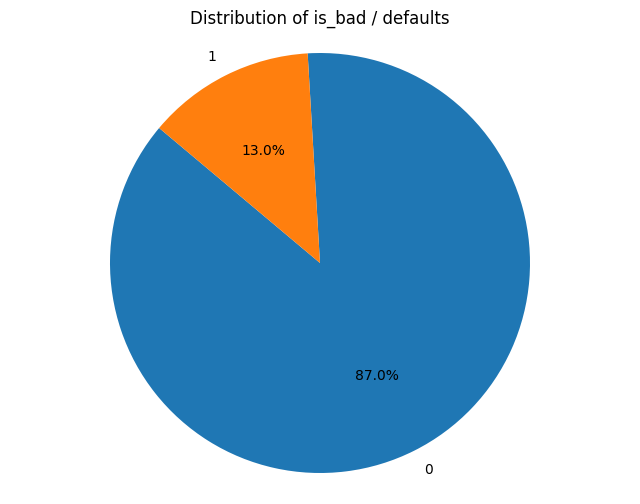

In [68]:
# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(df['is_bad'].value_counts(), labels=df['is_bad'].value_counts().keys(), autopct='%1.1f%%', startangle=140)
plt.title('Distribution of is_bad / defaults')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

We can see from the above pie charts that our data sert is **unbalanced**, meaning that out of 10000 people, only ~ 13% are "bad", so only 13% have a high probability of default.

For the modeling purpose, I would highly suggest creating another data set that's balnaced, meaning 50% of it would be Yes (or 1) for ***is_bad***.


Also, by checking the distribution of ***is_bad*** we can get our baseline accuracy - anything lower than 87.1% is less than guessing just from the data (meaning that without the model we can assume that 87.1 % of candidates won't default).

A few charts to present the data (might use it in the presentation)

In [106]:
def is_bad_by_feature_plot(df, feature):
    # Calculate total number of records per feature
    records_per_feature = df.groupby(feature)['is_bad'].count()

    # Calculate number of "is bad" per feature
    is_bad_per_feature = df.groupby(feature)['is_bad'].sum()

    # Create a DataFrame to hold the results
    cust_info = pd.DataFrame({
        'Feature_class': records_per_feature.index,
        'Total_Cust': records_per_feature.values,
        'Is_bad': is_bad_per_feature.values
    })

    # Calculate percentage of "is bad" per feature
    cust_info['Percentage_bad'] = (cust_info['Is_bad'] / cust_info['Total_Cust']) * 100

    # Sort by percentage of "is bad"/defaults
    cust_info = cust_info.sort_values(by='Percentage_bad', ascending=False)

    print(cust_info)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=cust_info, y='Feature_class', x='Percentage_bad', hue='Is_bad', dodge=False, order=cust_info['Feature_class'])
    ax.set_title(f'Percentage of Bad Cust by {feature.capitalize()}')
    ax.set_xlabel('Percentage of Bad Cust')
    ax.set_ylabel(feature.capitalize())

    plt.tight_layout()
    plt.show()

    return cust_info

In [149]:
#def plot_charts_v1(col, cat= 1):
 #   if cat == 1:
 #     df[col].value_counts()
 #       sns.countplot(data=df, y =col, order=df[col].value_counts().index)
 #       sns.countplot(data=df, y=col, hue='is_bad', order=df[col].value_counts().index)
 #       sns.countplot(data=df, y='is_bad', hue=col, order=df['is_bad'].value_counts().index)

 #       print(is_bad_by_feature_plot(df,col))
 #   else:
 #       df[col].describe()
 #       sns.displot(data=df, x=col, kde=True)
 #       df.hist(by='is_bad',column = col)
 #       sns.boxplot(x='is_bad', y=col, data=df)

In [191]:
def plot_charts(df,col, cat=1):
    if cat == 1:
        print(df[col].value_counts())

        plt.figure()
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.tight_layout(); plt.show()

        plt.figure()
        sns.countplot(data=df, y=col, hue='is_bad', order=df[col].value_counts().index)
        plt.tight_layout(); plt.show()

        plt.figure()
        sns.countplot(data=df, y='is_bad', hue=col, order=df['is_bad'].value_counts().index)
        plt.tight_layout(); plt.show()

        # this function already does its own plt.show()
        print(is_bad_by_feature_plot(df, col))

    else:
        print(df[col].describe())

        g = sns.displot(data=df, x=col, kde=True)
        plt.show()

        df.hist(by='is_bad', column=col)
        plt.tight_layout(); plt.show()

        plt.figure()
        sns.boxplot(x='is_bad', y=col, data=df)
        plt.tight_layout(); plt.show()

In [192]:
def plot_charts_2(df, col, cat=True):
    if cat:
        # counts table (printed, not plotted)
        print(df[col].value_counts(dropna=False))

        # 1) distribution of the category
        plt.figure(figsize=(8, max(3, 0.4*df[col].nunique())))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Count of {col}')
        plt.tight_layout()
        plt.show()

        # 2) distribution split by is_bad
        plt.figure(figsize=(8, max(3, 0.4*df[col].nunique())))
        sns.countplot(data=df, y=col, hue='is_bad', order=df[col].value_counts().index, dodge=True)
        plt.title(f'Count of {col} by is_bad')
        plt.tight_layout()
        plt.show()

        # 3) is_bad split by category
        plt.figure(figsize=(8, 3.5))
        sns.countplot(data=df, y='is_bad', hue=col, order=df['is_bad'].value_counts().index, dodge=True)
        plt.title(f'is_bad by {col}')
        plt.tight_layout()
        plt.show()

        # 4) bad-rate plot (your helper already calls plt.show())
        is_bad_by_feature_plot(df, col)

    else:
        # summary stats
        print(df[col].describe())

        # 1) distribution
        g = sns.displot(data=df, x=col, kde=True, height=4, aspect=1.6)
        g.fig.suptitle(f'Distribution of {col}')
        plt.tight_layout()
        plt.show()

        # 2) hist by class (creates its own Figure)
        df.hist(by='is_bad', column=col, figsize=(8, 4), grid=False, sharex=True)
        plt.tight_layout()
        plt.show()

        # 3) boxplot by class
        plt.figure(figsize=(8, 4))
        sns.boxplot(x='is_bad', y=col, data=df)
        plt.title(f'{col} by is_bad')
        plt.tight_layout()
        plt.show()

In [197]:
cat_col_plot = ['home_ownership', 'purpose_cat_new', 'addr_state', 'policy_code', 'verification_status', 'verification_status_ind' ,
                'pymnt_plan', 'small_business', 'total_acc_imp']

num_col_plot = ['emp_length_num','annual_inc', 'debt_to_income', 'total_acc_imp','mths_since_last_delinq']

count   3684
mean      36
std       22
min        0
25%       18
50%       34
75%       53
max      120
Name: mths_since_last_delinq, dtype: float64


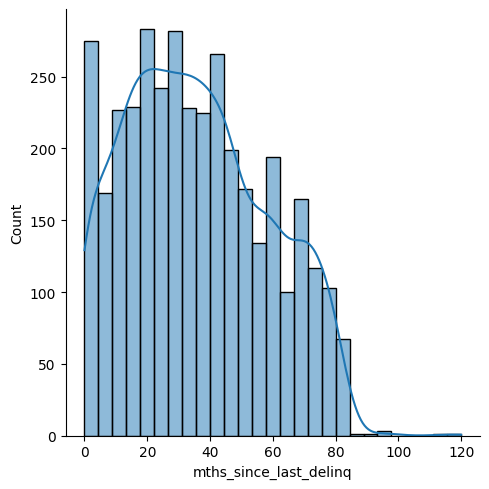

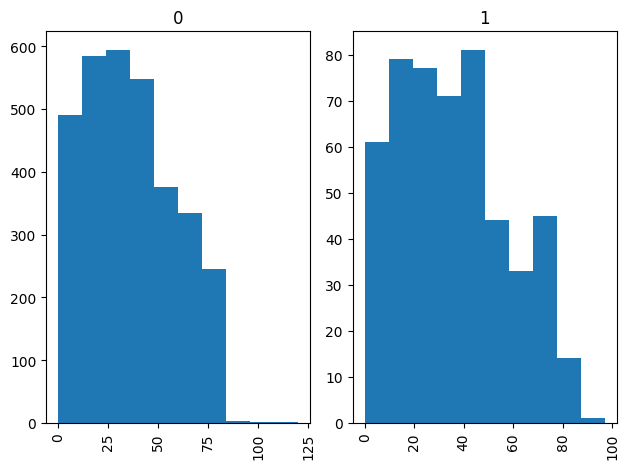

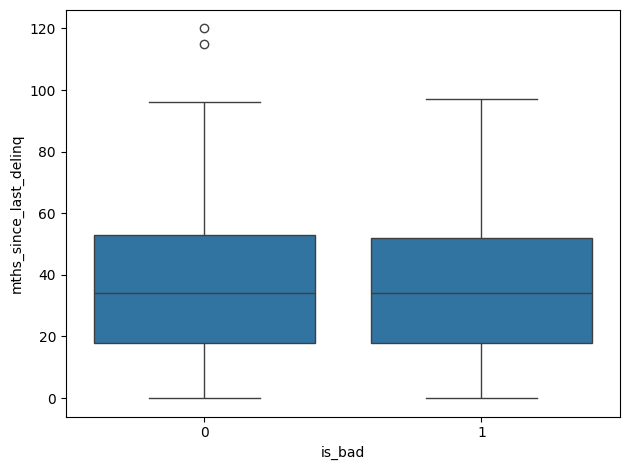

In [198]:
plot_charts(df,'mths_since_last_delinq', cat=0)

******************************. home_ownership. ******************************
home_ownership
RENT        4745
MORTGAGE    4445
OWN          775
OTHER         34
Name: count, dtype: int64


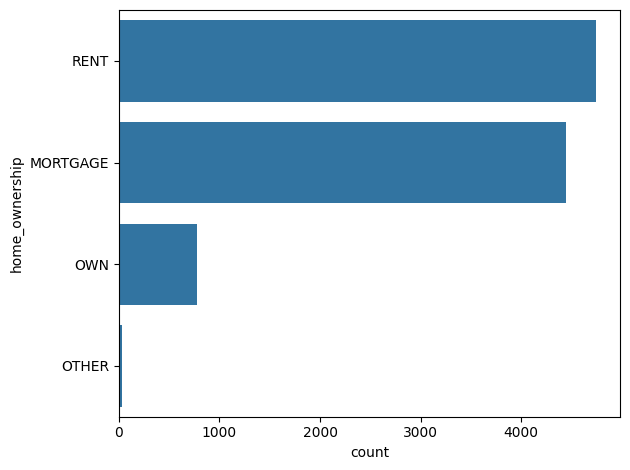

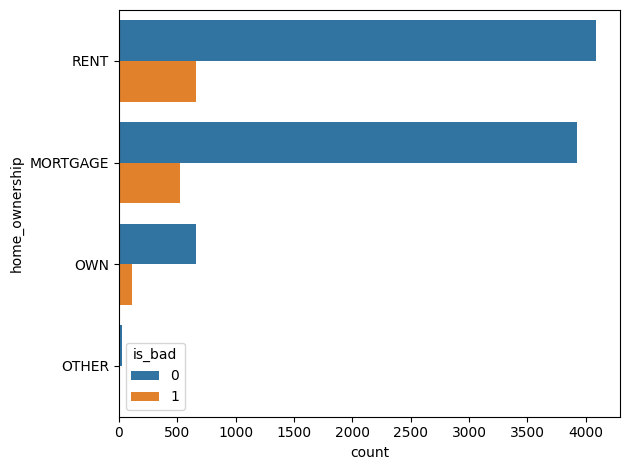

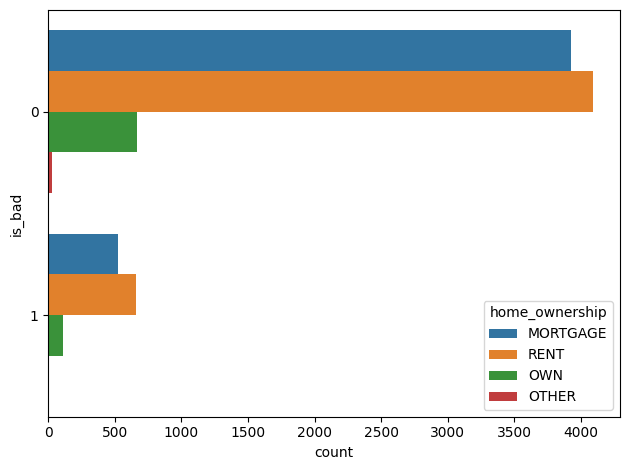

  Feature_class  Total_Cust  Is_bad  Percentage_bad
2           OWN         775     111              14
3          RENT        4745     657              14
0      MORTGAGE        4445     523              12
1         OTHER          34       4              12


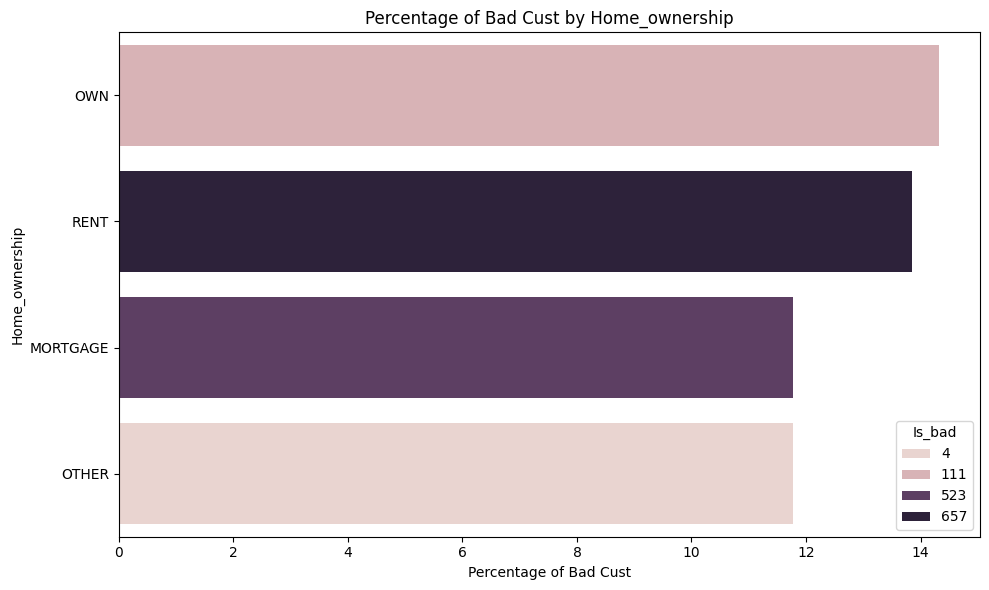

  Feature_class  Total_Cust  Is_bad  Percentage_bad
2           OWN         775     111              14
3          RENT        4745     657              14
0      MORTGAGE        4445     523              12
1         OTHER          34       4              12
******************************. purpose_cat_new. ******************************
purpose_cat_new
debt consolidation    4556
other                 1516
credit card           1290
home improvement       811
major purchase         551
car                    352
wedding                252
medical                185
moving                 162
educational            112
house                   97
vacation                96
renewable energy        19
Name: count, dtype: int64


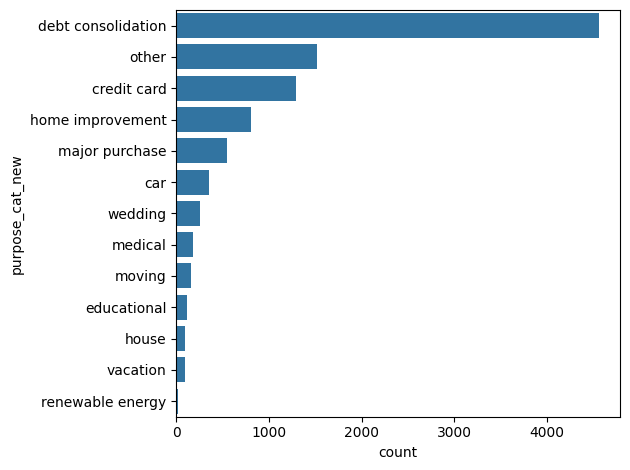

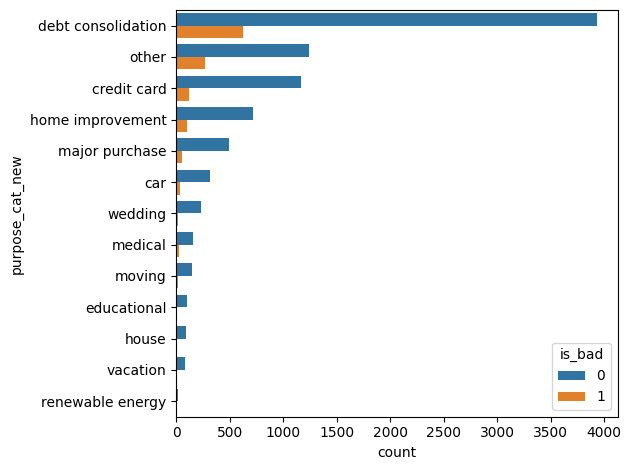

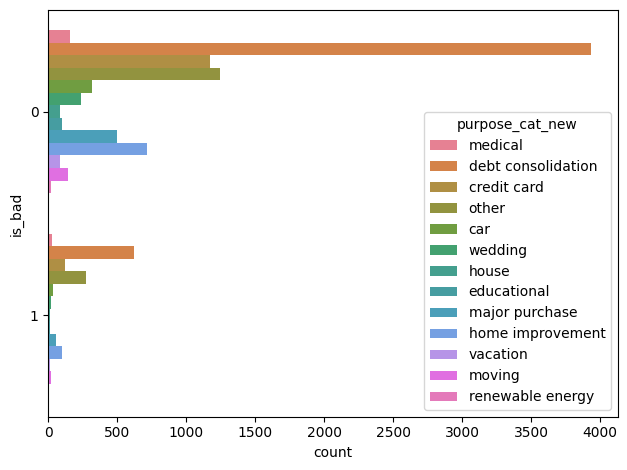

         Feature_class  Total_Cust  Is_bad  Percentage_bad
9                other        1516     271              18
7              medical         185      27              15
2   debt consolidation        4556     624              14
11            vacation          96      12              12
4     home improvement         811      97              12
8               moving         162      18              11
10    renewable energy          19       2              11
6       major purchase         551      56              10
3          educational         112      11              10
1          credit card        1290     120               9
5                house          97       9               9
0                  car         352      32               9
12             wedding         252      16               6


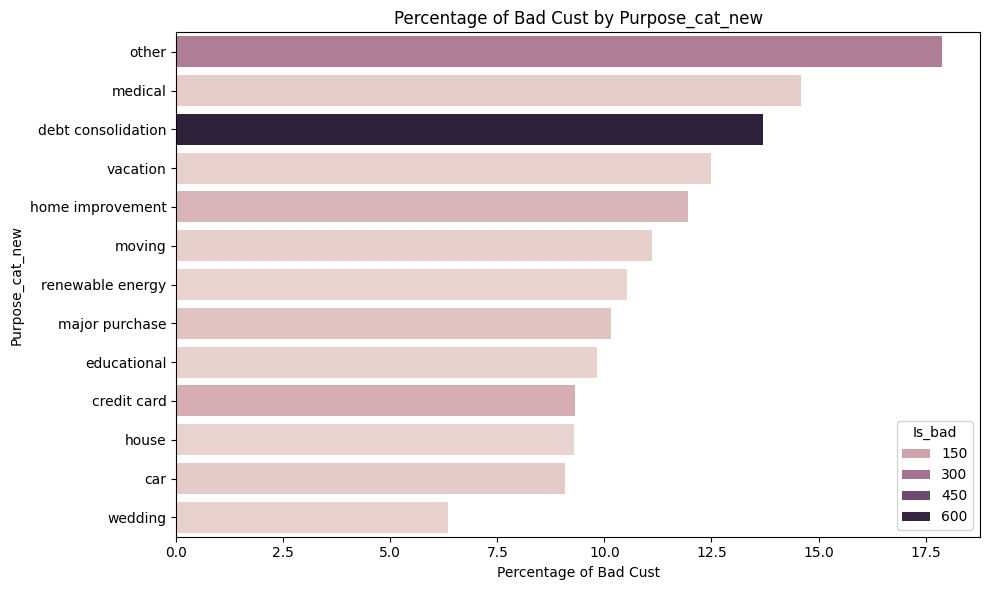

         Feature_class  Total_Cust  Is_bad  Percentage_bad
9                other        1516     271              18
7              medical         185      27              15
2   debt consolidation        4556     624              14
11            vacation          96      12              12
4     home improvement         811      97              12
8               moving         162      18              11
10    renewable energy          19       2              11
6       major purchase         551      56              10
3          educational         112      11              10
1          credit card        1290     120               9
5                house          97       9               9
0                  car         352      32               9
12             wedding         252      16               6
******************************. addr_state. ******************************
addr_state
CA    1748
NY     957
FL     714
TX     700
NJ     482
VA     392
IL     386
PA     378


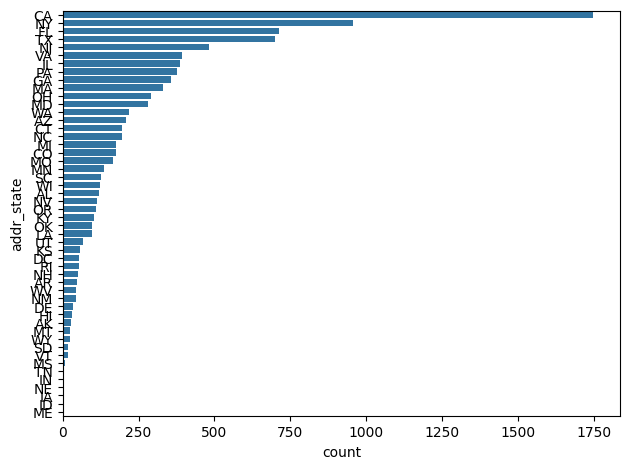

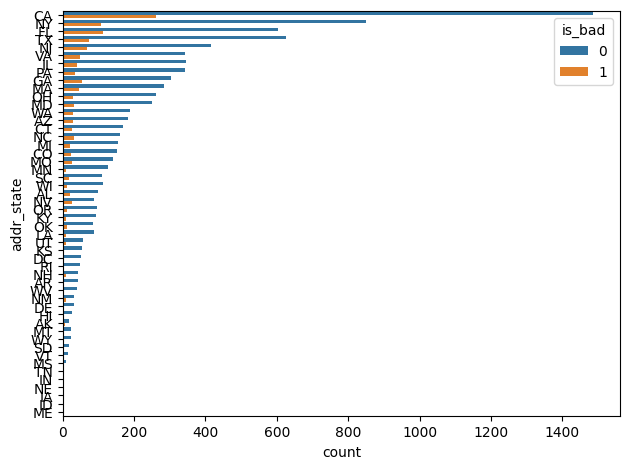

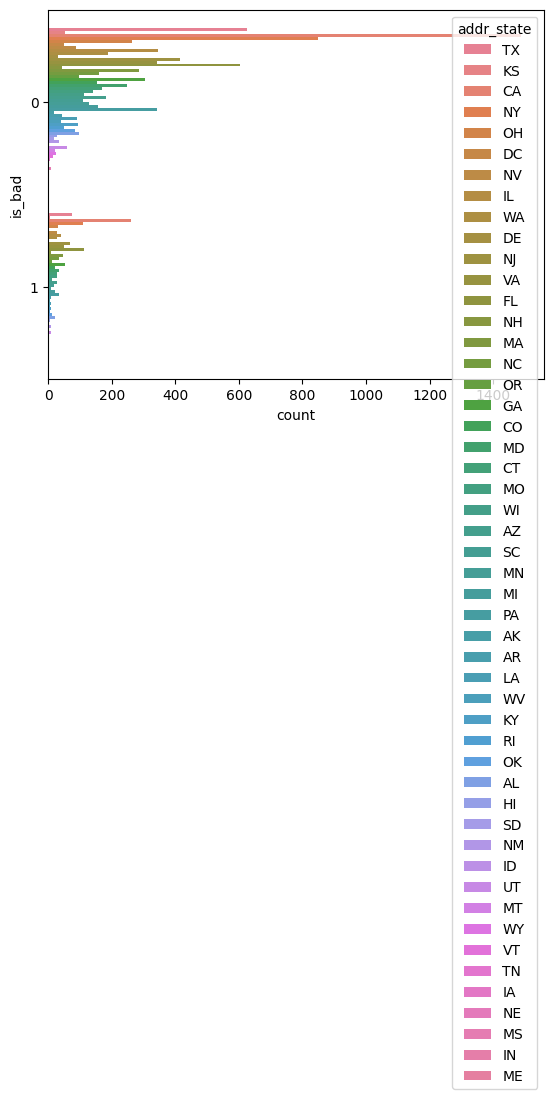

   Feature_class  Total_Cust  Is_bad  Percentage_bad
28            NE           3       1              33
0             AK          26       7              27
32            NV         114      27              24
31            NM          43      10              23
41            TN           5       1              20
1             AL         119      21              18
27            NC         194      33              17
29            NH          50       8              16
9             FL         714     112              16
11            HI          32       5              16
24            MO         167      26              16
4             CA        1748     261              15
10            GA         357      53              15
43            UT          68      10              15
30            NJ         482      67              14
19            MA         331      46              14
6             CT         195      27              14
39            SC         126      17          

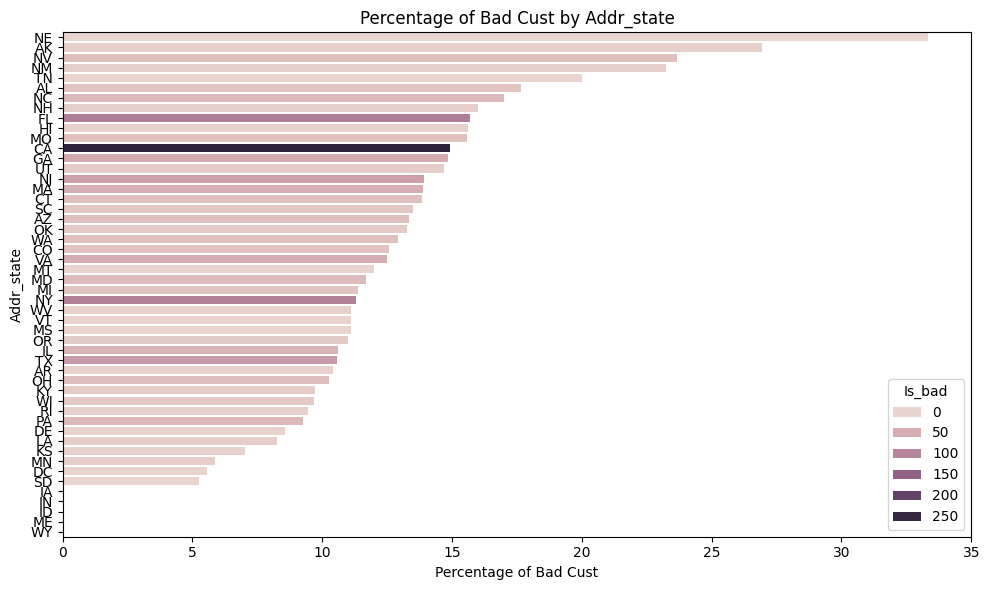

   Feature_class  Total_Cust  Is_bad  Percentage_bad
28            NE           3       1              33
0             AK          26       7              27
32            NV         114      27              24
31            NM          43      10              23
41            TN           5       1              20
1             AL         119      21              18
27            NC         194      33              17
29            NH          50       8              16
9             FL         714     112              16
11            HI          32       5              16
24            MO         167      26              16
4             CA        1748     261              15
10            GA         357      53              15
43            UT          68      10              15
30            NJ         482      67              14
19            MA         331      46              14
6             CT         195      27              14
39            SC         126      17          

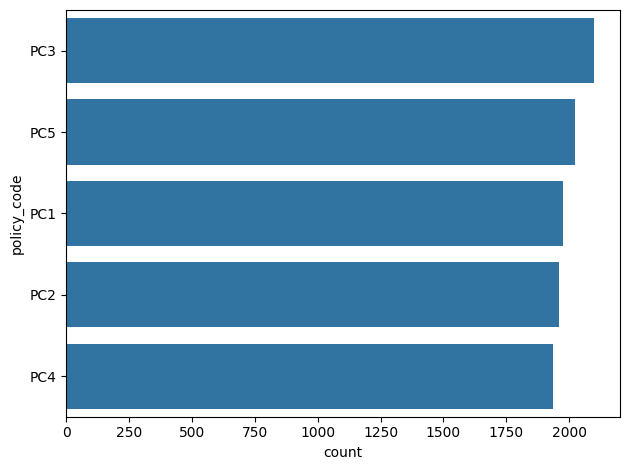

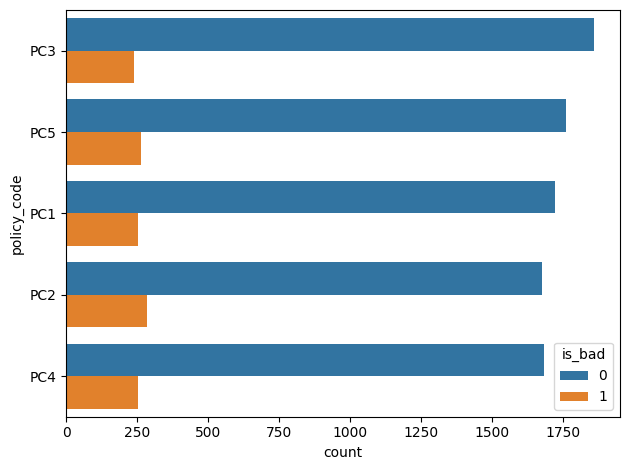

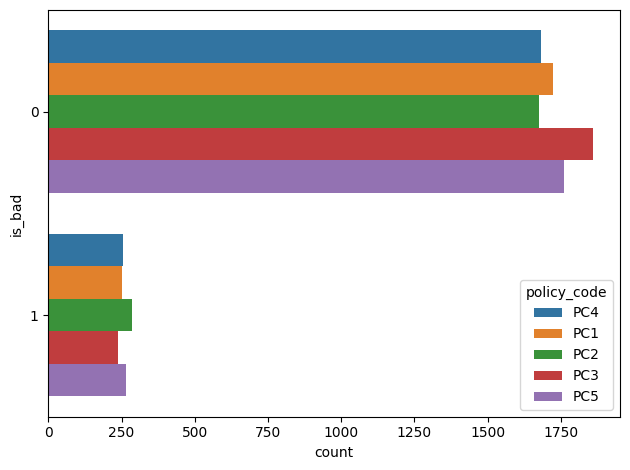

  Feature_class  Total_Cust  Is_bad  Percentage_bad
1           PC2        1962     285              15
3           PC4        1937     254              13
4           PC5        2025     264              13
0           PC1        1977     253              13
2           PC3        2098     239              11


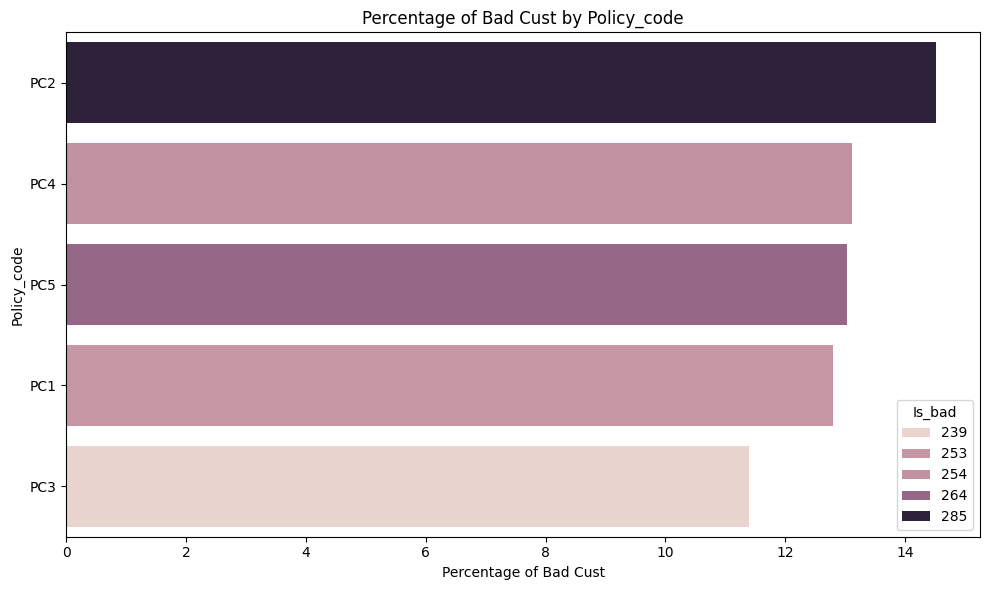

  Feature_class  Total_Cust  Is_bad  Percentage_bad
1           PC2        1962     285              15
3           PC4        1937     254              13
4           PC5        2025     264              13
0           PC1        1977     253              13
2           PC3        2098     239              11
******************************. verification_status. ******************************
verification_status
not verified                4366
VERIFIED - income           3214
VERIFIED - income source    2419
Name: count, dtype: int64


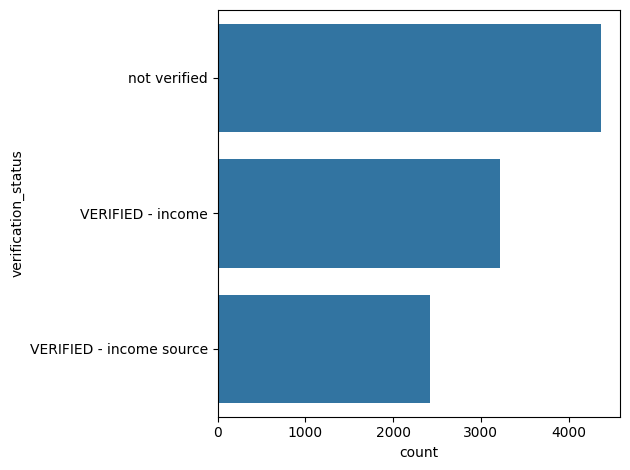

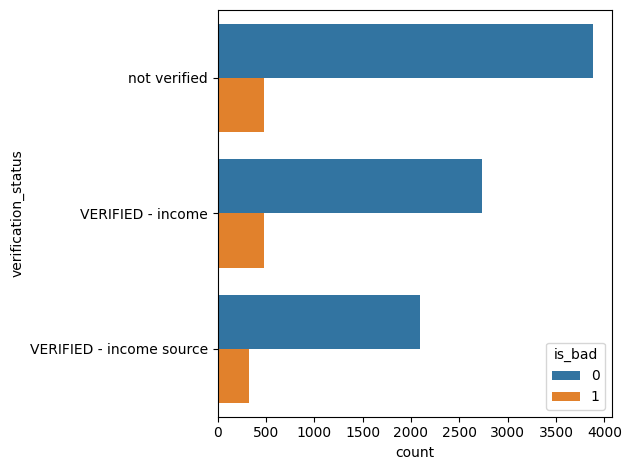

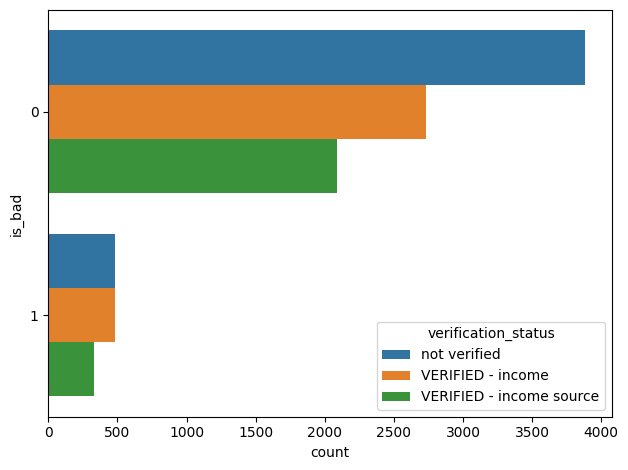

              Feature_class  Total_Cust  Is_bad  Percentage_bad
0         VERIFIED - income        3214     484              15
1  VERIFIED - income source        2419     329              14
2              not verified        4366     482              11


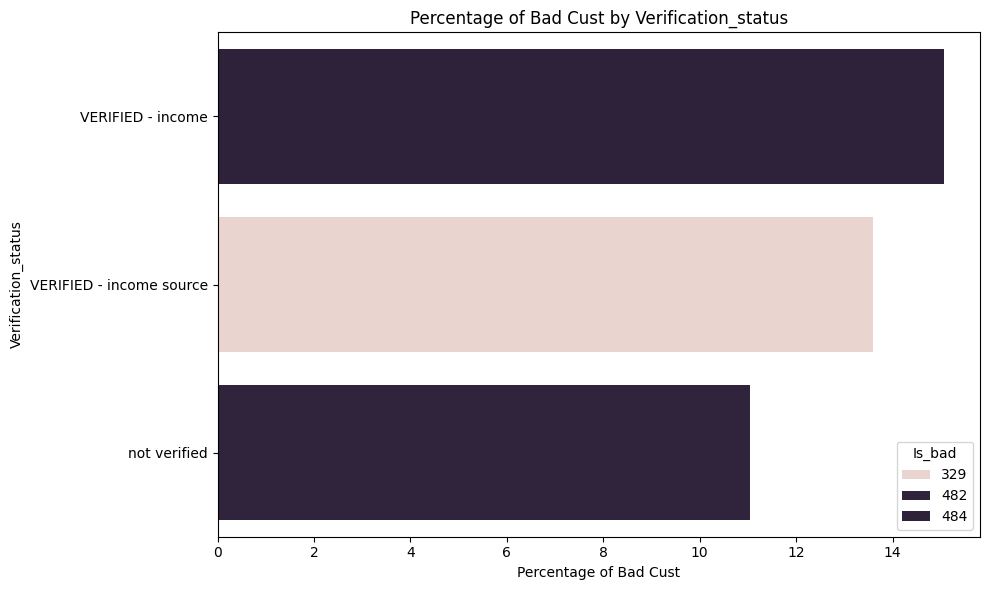

              Feature_class  Total_Cust  Is_bad  Percentage_bad
0         VERIFIED - income        3214     484              15
1  VERIFIED - income source        2419     329              14
2              not verified        4366     482              11
******************************. verification_status_ind. ******************************
verification_status_ind
1    5633
0    4366
Name: count, dtype: int64


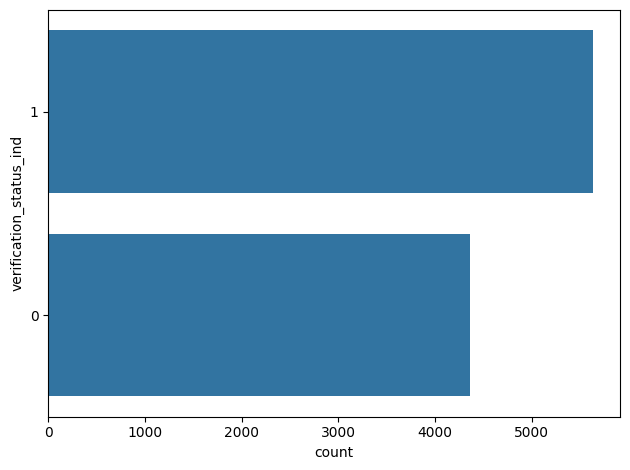

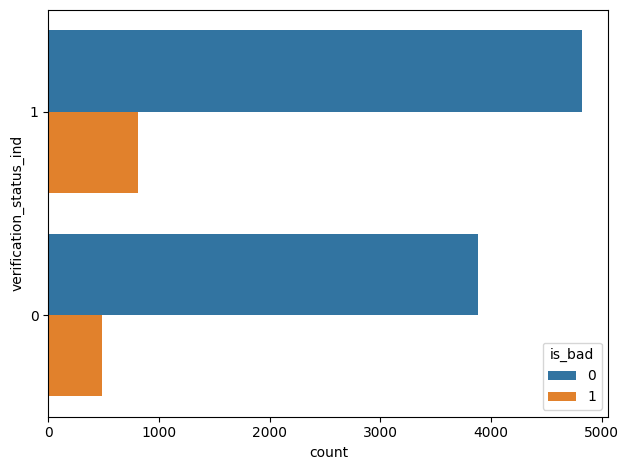

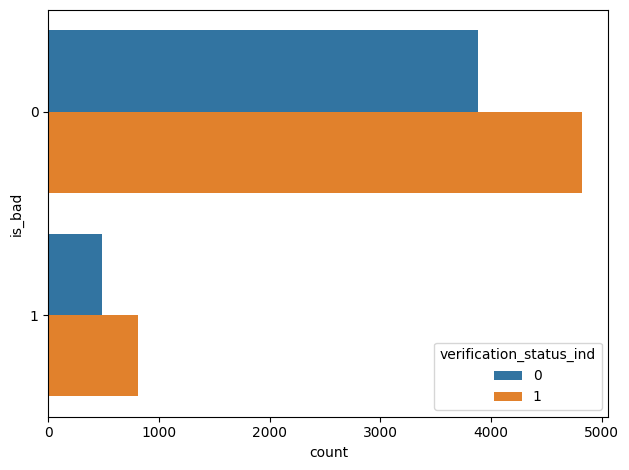

   Feature_class  Total_Cust  Is_bad  Percentage_bad
1              1        5633     813              14
0              0        4366     482              11


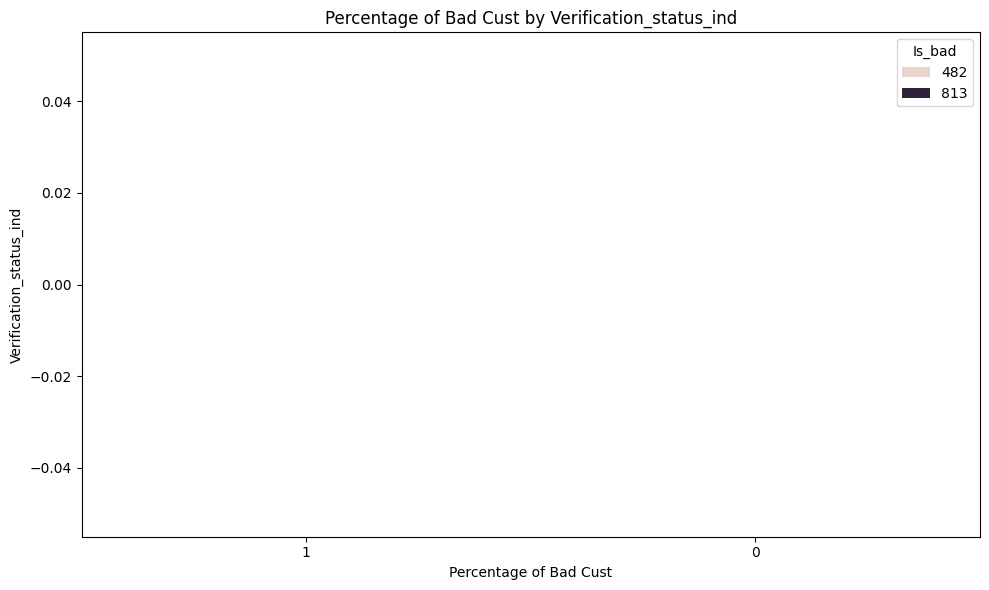

   Feature_class  Total_Cust  Is_bad  Percentage_bad
1              1        5633     813              14
0              0        4366     482              11
******************************. pymnt_plan. ******************************
pymnt_plan
n    9997
y       2
Name: count, dtype: int64


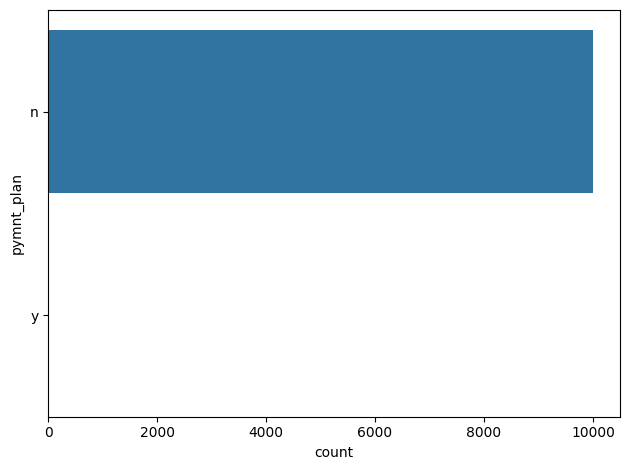

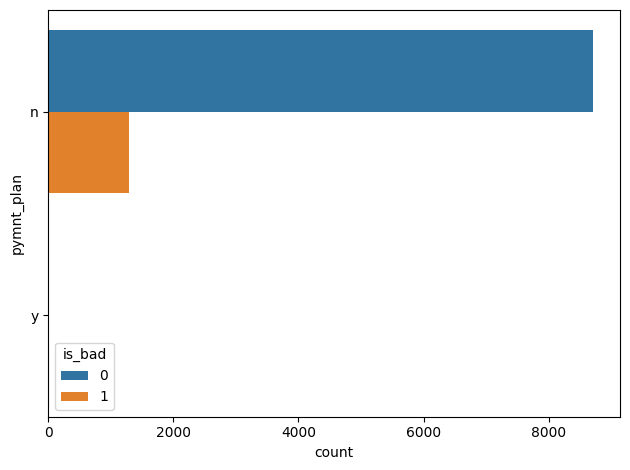

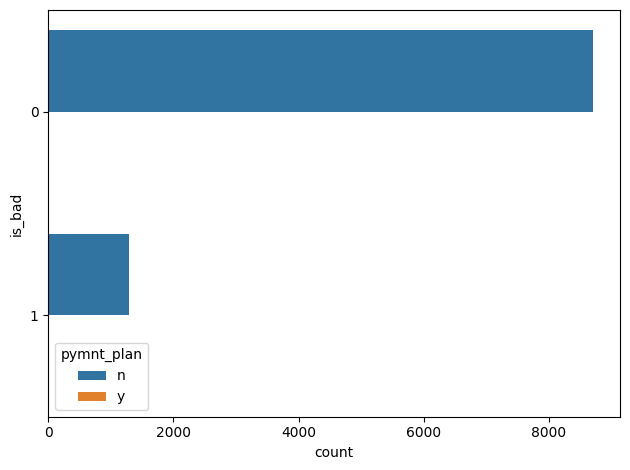

  Feature_class  Total_Cust  Is_bad  Percentage_bad
1             y           2       2             100
0             n        9997    1293              13


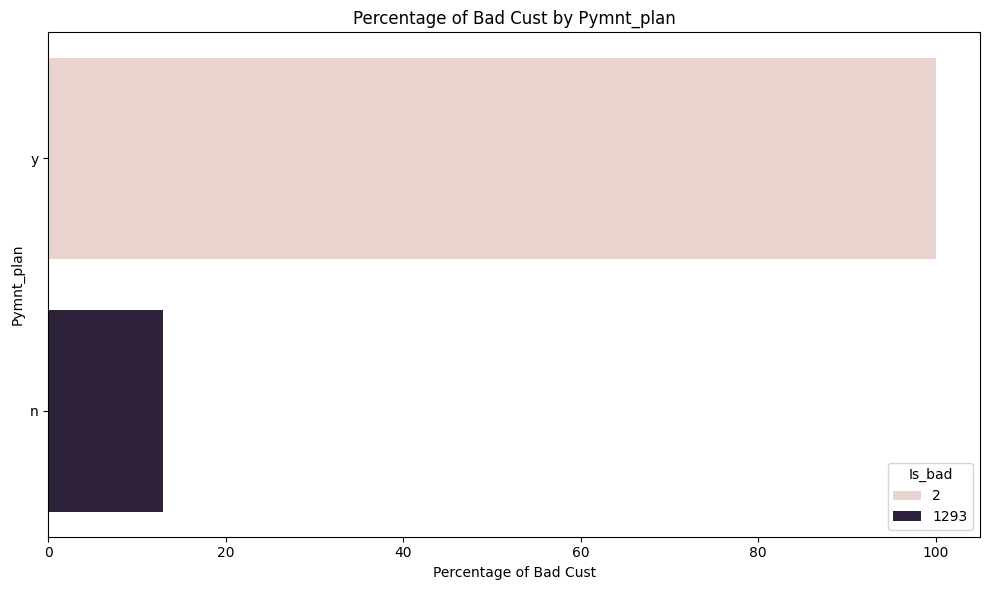

  Feature_class  Total_Cust  Is_bad  Percentage_bad
1             y           2       2             100
0             n        9997    1293              13
******************************. small_business. ******************************
small_business
0    9353
1     646
Name: count, dtype: int64


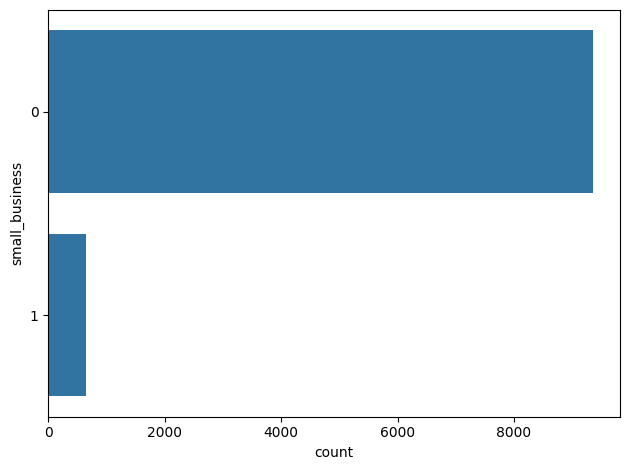

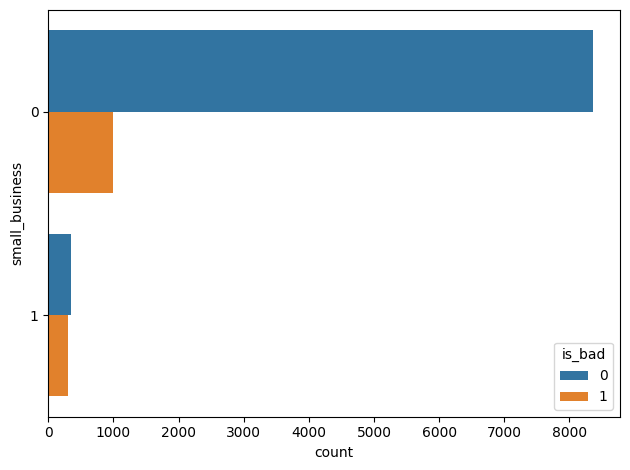

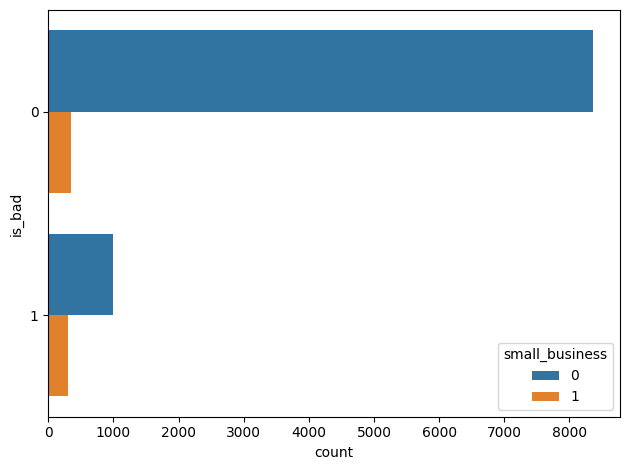

   Feature_class  Total_Cust  Is_bad  Percentage_bad
1              1         646     301              47
0              0        9353     994              11


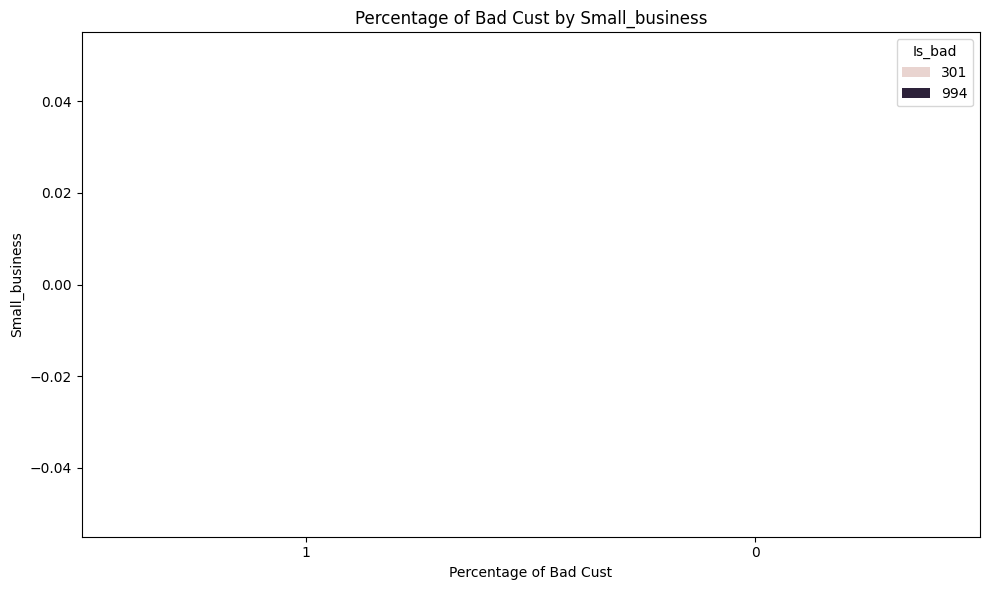

   Feature_class  Total_Cust  Is_bad  Percentage_bad
1              1         646     301              47
0              0        9353     994              11
******************************. total_acc_imp. ******************************
total_acc_imp
15    369
20    364
17    360
12    357
14    351
19    346
16    340
18    339
13    331
22    329
11    328
21    322
24    300
23    299
10    291
27    290
7     280
9     272
25    270
28    253
8     245
26    240
29    238
30    221
31    196
32    192
6     188
33    177
34    156
35    145
5     144
38    127
37    127
36    125
4     115
39    105
41     74
40     73
42     73
46     62
43     58
3      58
44     50
45     46
47     44
48     41
50     32
53     32
63     32
52     31
49     22
51     21
57     14
54     13
55     13
56     11
2      10
60      9
62      8
61      7
59      7
58      5
77      4
1       3
66      2
64      2
67      2
78      1
90      1
76      1
80      1
70      1
79      1
69      1
81      1

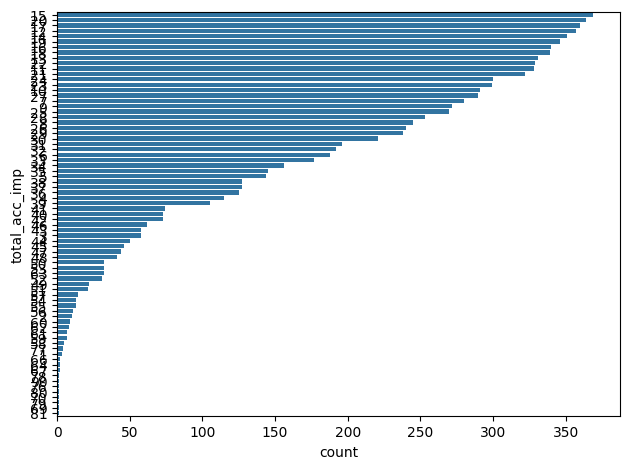

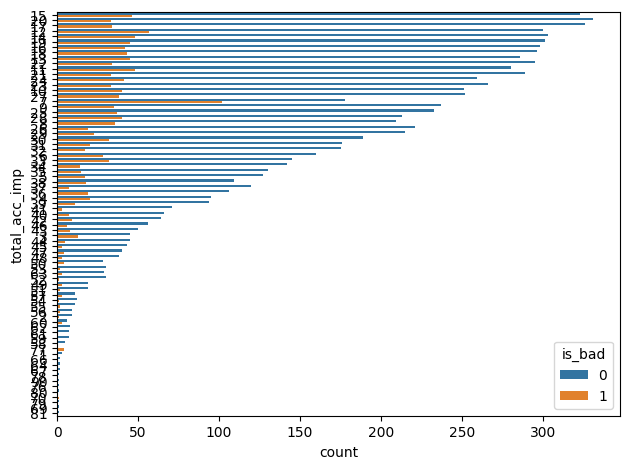

TypeError: Cannot interpret 'Int64Dtype()' as a data type

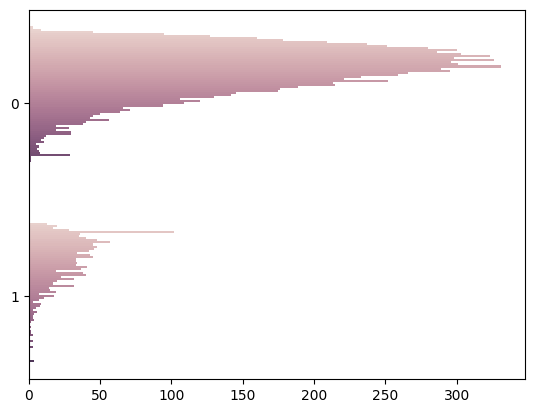

In [199]:
# Creating plots for multiple columns

for col in cat_col_plot:
    print('******************************. ' + col +'. ******************************')
    plot_charts(df,col)

for col in num_col_plot:
    print('******************************. ' + col + '  ******************************')
    plot_charts(df,col, cat=0)


home_ownership
RENT        4745
MORTGAGE    4445
OWN          775
OTHER         34
Name: count, dtype: int64


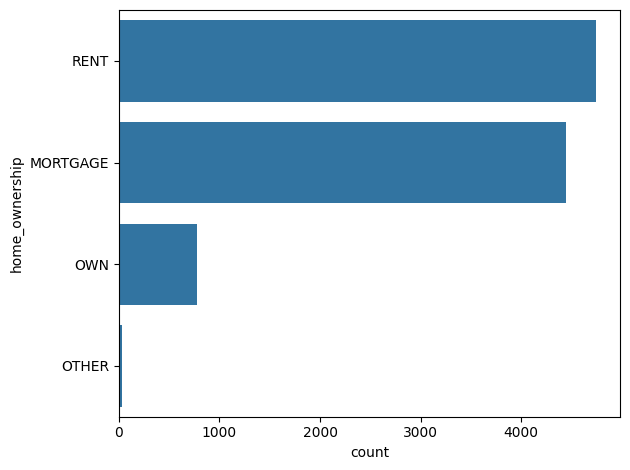

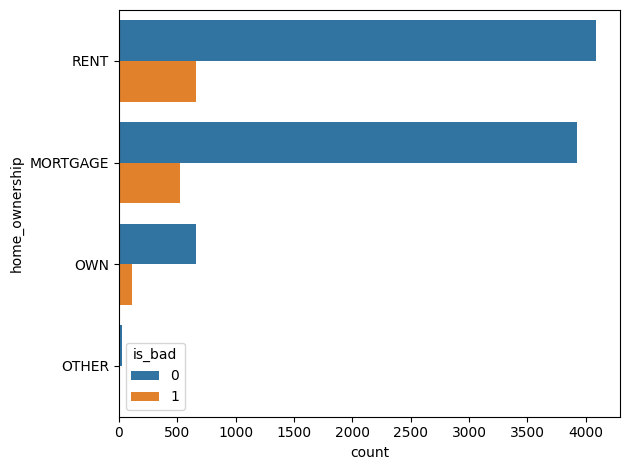

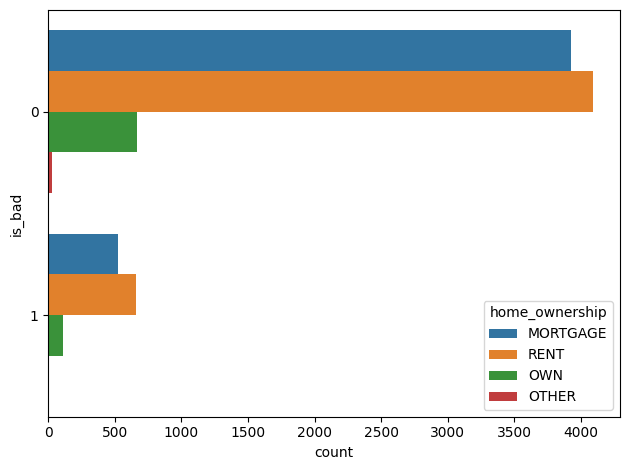

  Feature_class  Total_Cust  Is_bad  Percentage_bad
2           OWN         775     111              14
3          RENT        4745     657              14
0      MORTGAGE        4445     523              12
1         OTHER          34       4              12


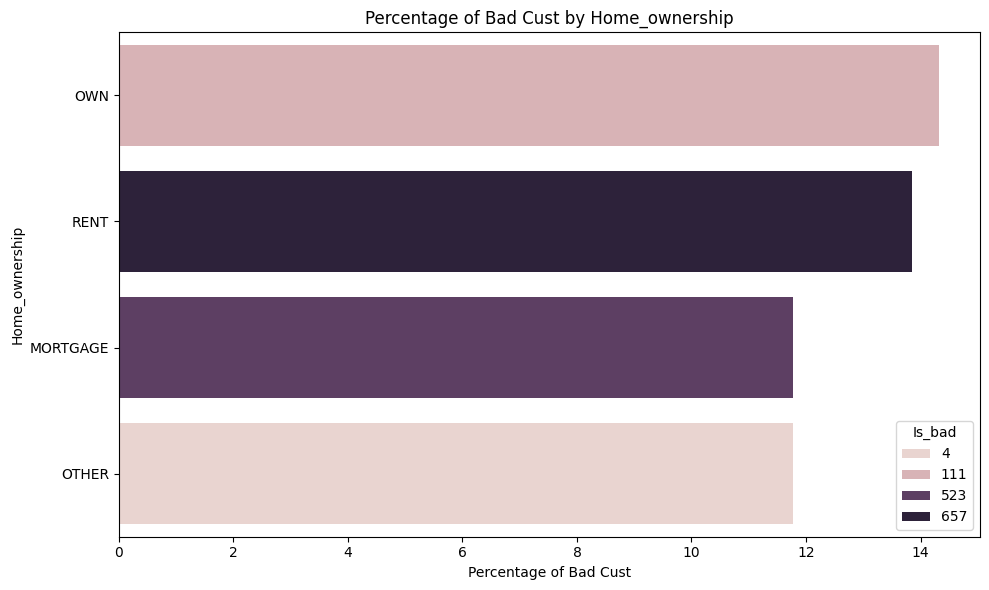

  Feature_class  Total_Cust  Is_bad  Percentage_bad
2           OWN         775     111              14
3          RENT        4745     657              14
0      MORTGAGE        4445     523              12
1         OTHER          34       4              12


In [152]:
plot_charts(df,'home_ownership')

count   9999
mean       5
std        3
min        1
25%        2
50%        4
75%        8
max       33
Name: emp_length_num, dtype: float64


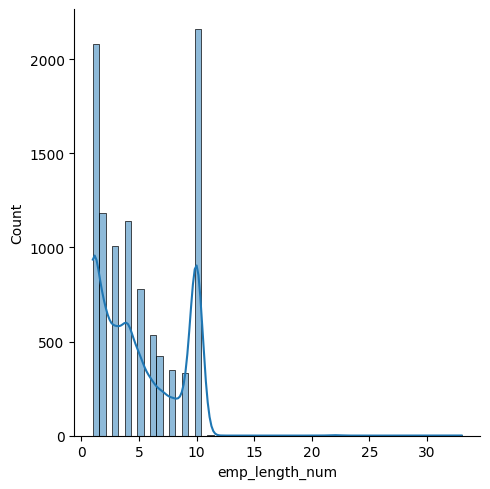

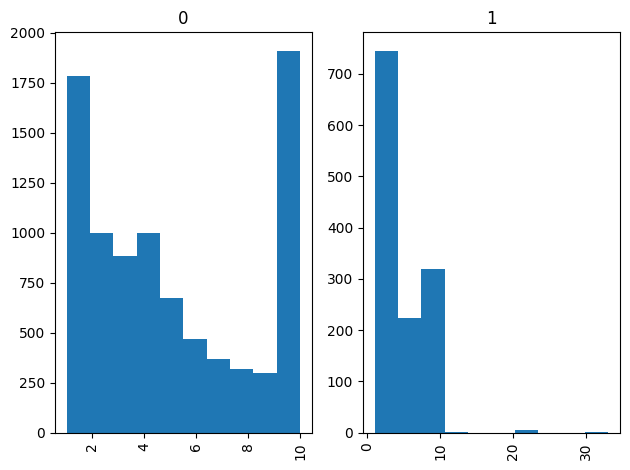

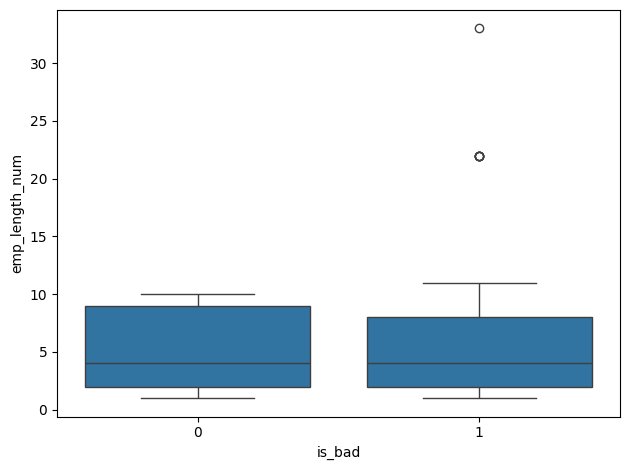

In [200]:
plot_charts(df,'emp_length_num',cat=0)

count   9999
mean       5
std        3
min        1
25%        2
50%        4
75%        8
max       33
Name: emp_length_num, dtype: float64


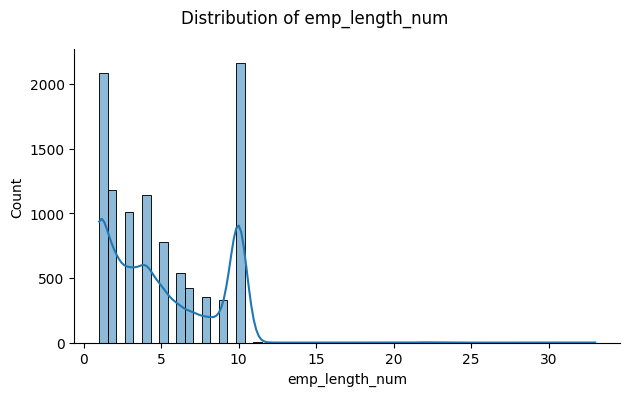

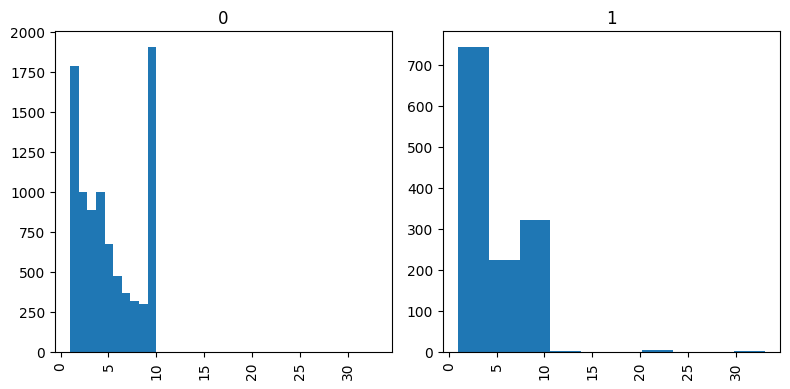

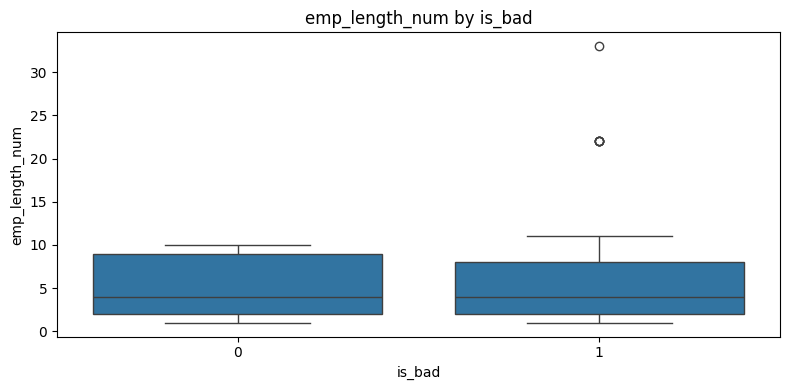

In [201]:
plot_charts_2(df,'emp_length_num',cat=False)

<Axes: xlabel='count', ylabel='home_ownership'>

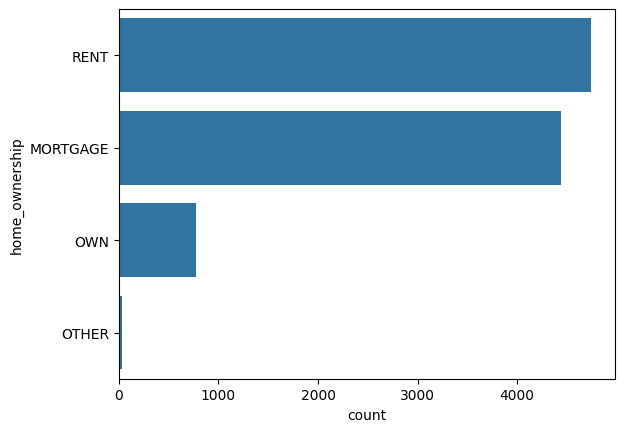

In [202]:
sns.countplot(data=df, y ='home_ownership', order=df['home_ownership'].value_counts().index)

<Axes: xlabel='count', ylabel='home_ownership'>

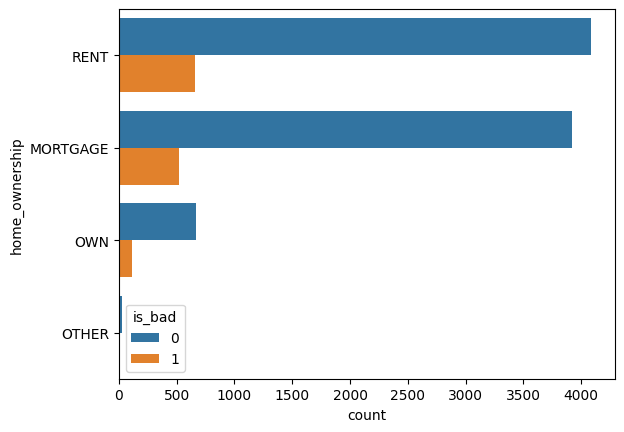

In [203]:
sns.countplot(data=df, y='home_ownership', hue="is_bad", order=df['home_ownership'].value_counts().index)

<Axes: xlabel='count', ylabel='is_bad'>

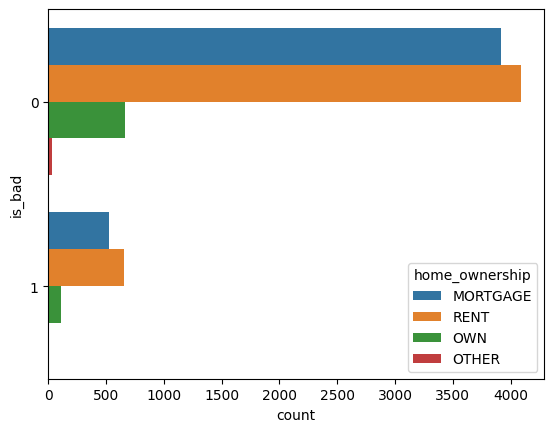

In [204]:
sns.countplot(data=df, y='is_bad', hue="home_ownership", order=df['is_bad'].value_counts().index)

  Feature_class  Total_Cust  Is_bad  Percentage_bad
2           OWN         775     111              14
3          RENT        4745     657              14
0      MORTGAGE        4445     523              12
1         OTHER          34       4              12


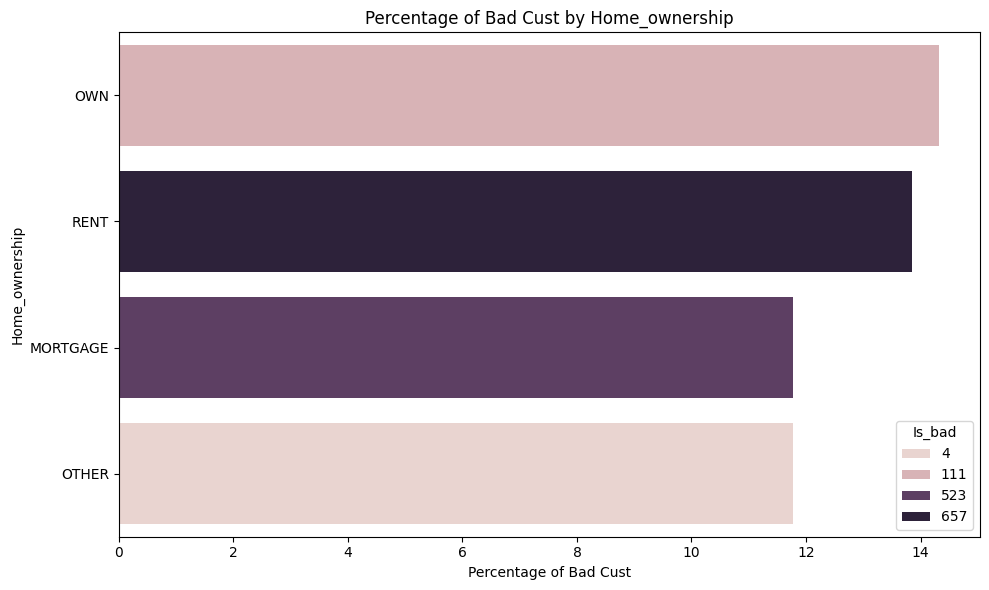

,Feature_class,Total_Cust,Is_bad,Percentage_bad
2,OWN,775,111,14
3,RENT,4745,657,14
0,MORTGAGE,4445,523,12
1,OTHER,34,4,12


In [205]:
is_bad_by_feature_plot(df,'home_ownership')

This is example of a variable that doesn't really bring much predictive power into our model (since percentage of bad is very similar for all the classes).

<Axes: xlabel='count', ylabel='purpose_cat_new'>

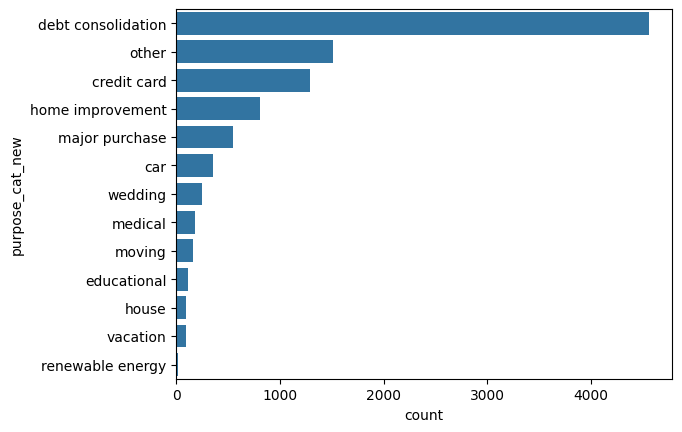

In [206]:
sns.countplot(data=df, y ='purpose_cat_new', order=df['purpose_cat_new'].value_counts().index)

<Axes: xlabel='count', ylabel='purpose_cat_new'>

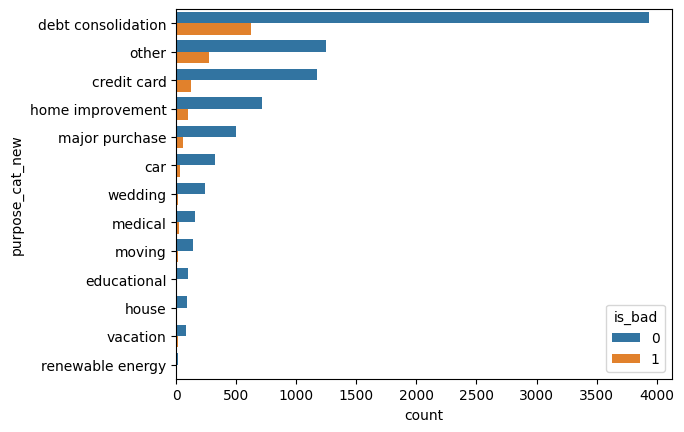

In [207]:
sns.countplot(data=df, y='purpose_cat_new', hue="is_bad", order=df['purpose_cat_new'].value_counts().index)

<Axes: xlabel='count', ylabel='is_bad'>

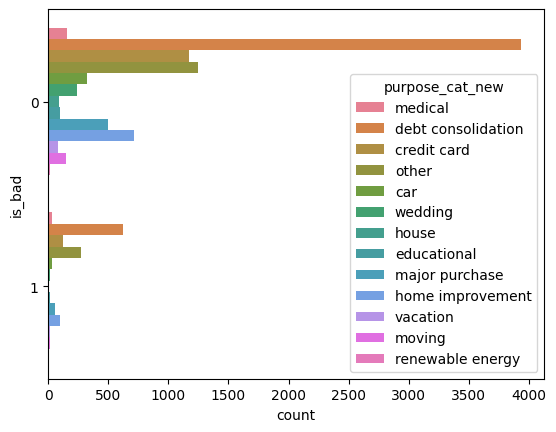

In [208]:
sns.countplot(data=df, y='is_bad', hue="purpose_cat_new", order=df['is_bad'].value_counts().index)

         Feature_class  Total_Cust  Is_bad  Percentage_bad
9                other        1516     271              18
7              medical         185      27              15
2   debt consolidation        4556     624              14
11            vacation          96      12              12
4     home improvement         811      97              12
8               moving         162      18              11
10    renewable energy          19       2              11
6       major purchase         551      56              10
3          educational         112      11              10
1          credit card        1290     120               9
5                house          97       9               9
0                  car         352      32               9
12             wedding         252      16               6


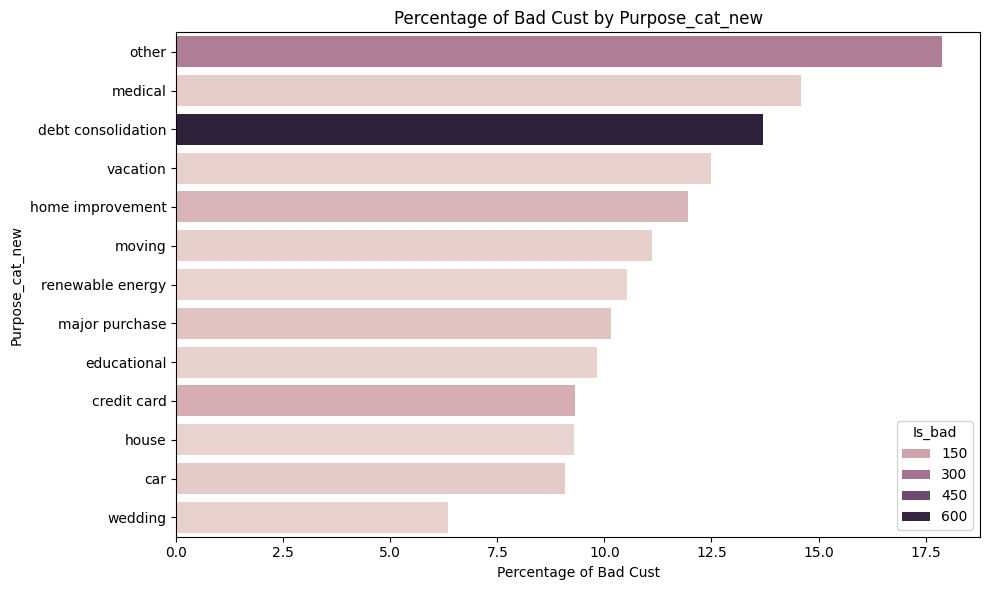

,Feature_class,Total_Cust,Is_bad,Percentage_bad
9,other,1516,271,18
7,medical,185,27,15
2,debt consolidation,4556,624,14
11,vacation,96,12,12
4,home improvement,811,97,12
8,moving,162,18,11
10,renewable energy,19,2,11
6,major purchase,551,56,10
3,educational,112,11,10
1,credit card,1290,120,9


In [209]:
is_bad_by_feature_plot(df,'purpose_cat_new')

We want the number of *Percentage_bad* to be different for different categories, this might indicate predictive power of the feature.

<Axes: xlabel='count', ylabel='addr_state'>

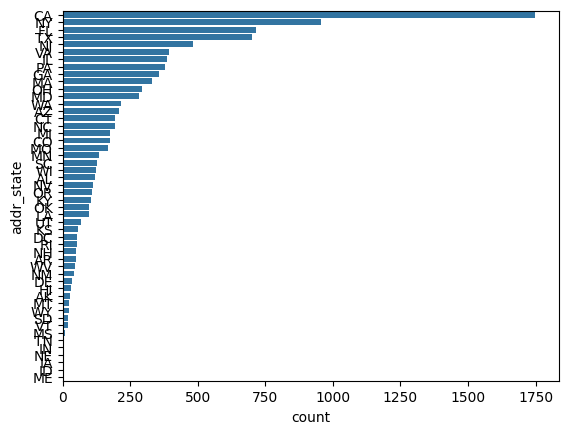

In [210]:
sns.countplot(data=df, y ='addr_state', order=df['addr_state'].value_counts().index)

<Axes: xlabel='count', ylabel='addr_state'>

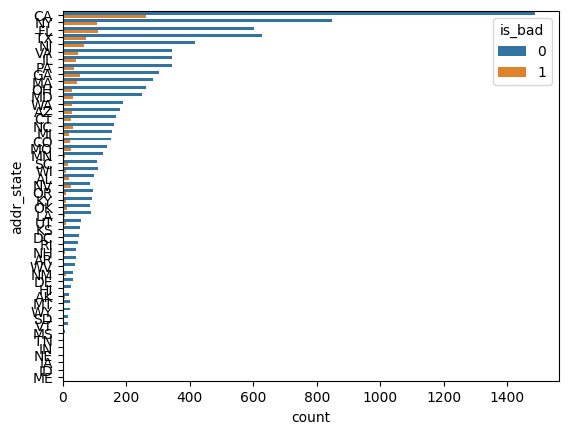

In [211]:
sns.countplot(data=df, y='addr_state', hue="is_bad", order=df['addr_state'].value_counts().index)

   Feature_class  Total_Cust  Is_bad  Percentage_bad
28            NE           3       1              33
0             AK          26       7              27
32            NV         114      27              24
31            NM          43      10              23
41            TN           5       1              20
1             AL         119      21              18
27            NC         194      33              17
29            NH          50       8              16
9             FL         714     112              16
11            HI          32       5              16
24            MO         167      26              16
4             CA        1748     261              15
10            GA         357      53              15
43            UT          68      10              15
30            NJ         482      67              14
19            MA         331      46              14
6             CT         195      27              14
39            SC         126      17          

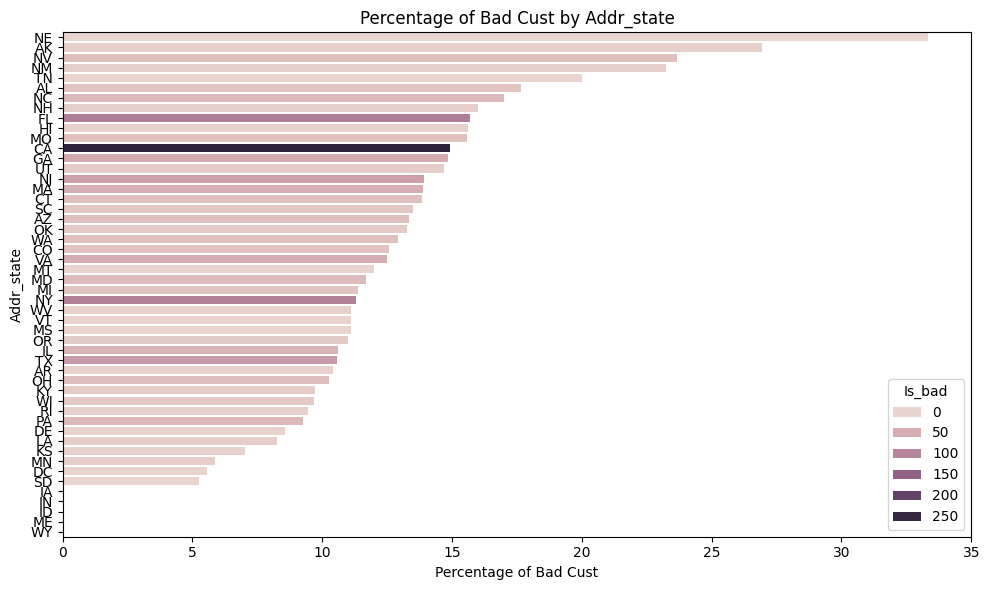

,Feature_class,Total_Cust,Is_bad,Percentage_bad
28,NE,3,1,33
0,AK,26,7,27
32,NV,114,27,24
31,NM,43,10,23
41,TN,5,1,20
1,AL,119,21,18
27,NC,194,33,17
29,NH,50,8,16
9,FL,714,112,16
11,HI,32,5,16


In [212]:
is_bad_by_feature_plot(df,'addr_state')

<Axes: xlabel='count', ylabel='policy_code'>

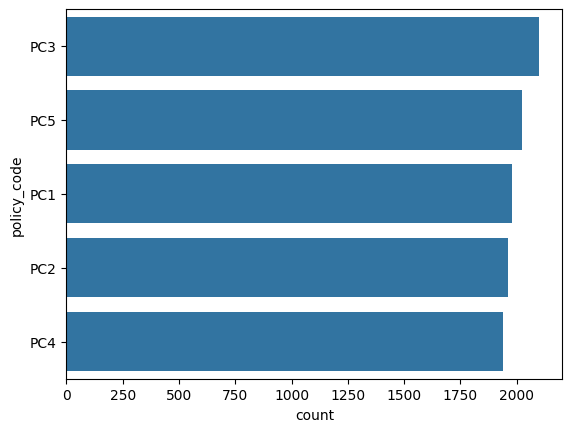

In [213]:
sns.countplot(data=df, y ='policy_code', order=df['policy_code'].value_counts().index)

<Axes: xlabel='count', ylabel='policy_code'>

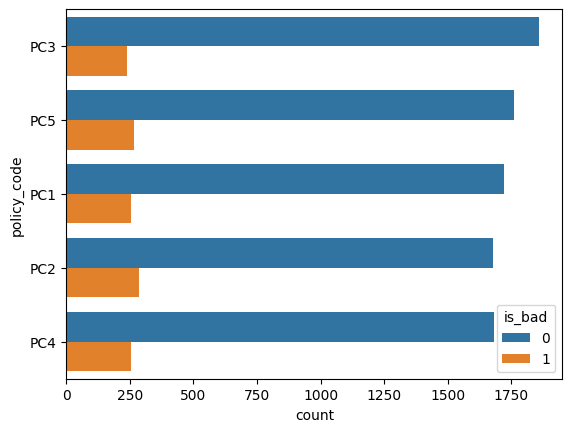

In [214]:
sns.countplot(data=df, y='policy_code', hue="is_bad", order=df['policy_code'].value_counts().index)

<Axes: xlabel='count', ylabel='is_bad'>

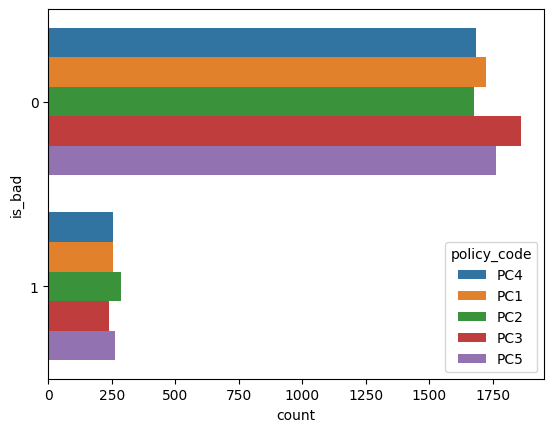

In [215]:
sns.countplot(data=df, y='is_bad', hue="policy_code", order=df['is_bad'].value_counts().index)

The histograms/bar plots look slightly different for 0 and 1 (*is_bad*) but I don't think they're different enough to be a predictor for the dependent feature.

  Feature_class  Total_Cust  Is_bad  Percentage_bad
1           PC2        1962     285              15
3           PC4        1937     254              13
4           PC5        2025     264              13
0           PC1        1977     253              13
2           PC3        2098     239              11


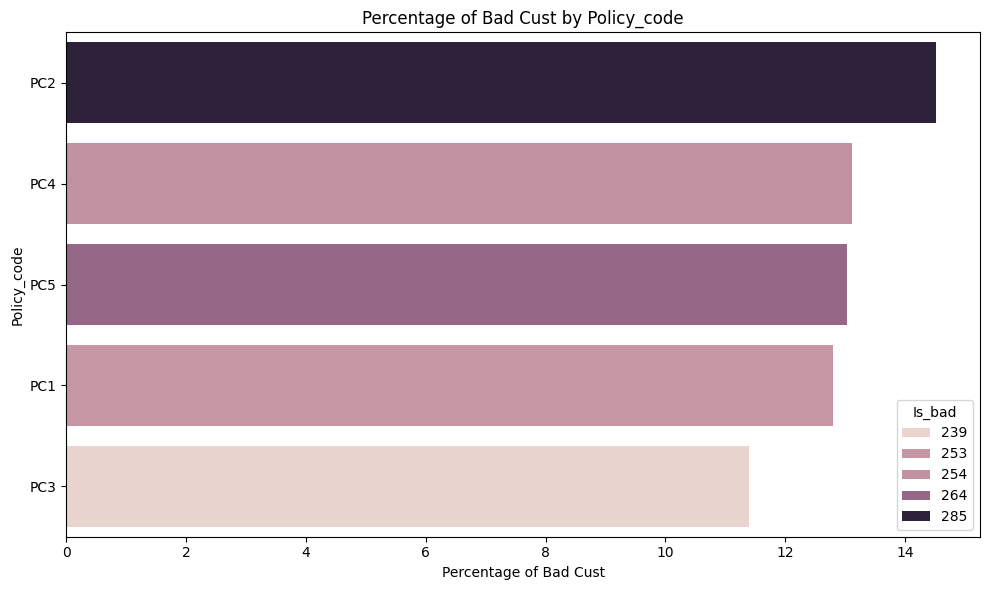

,Feature_class,Total_Cust,Is_bad,Percentage_bad
1,PC2,1962,285,15
3,PC4,1937,254,13
4,PC5,2025,264,13
0,PC1,1977,253,13
2,PC3,2098,239,11


In [216]:
is_bad_by_feature_plot(df,'policy_code')

<Axes: xlabel='count', ylabel='verification_status'>

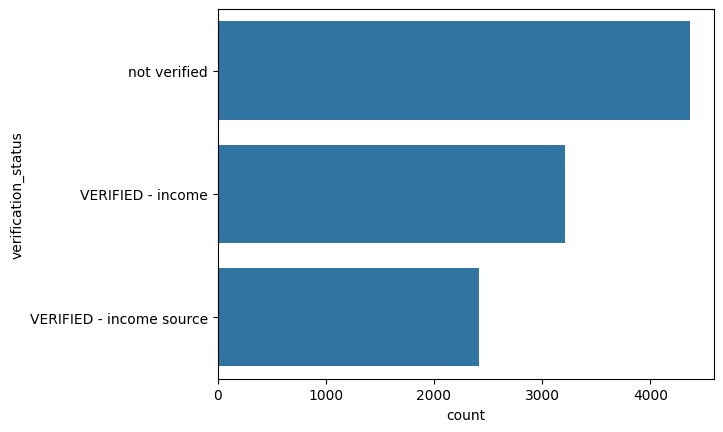

In [217]:
sns.countplot(data=df, y ='verification_status', order=df['verification_status'].value_counts().index)

<Axes: xlabel='count', ylabel='verification_status_ind'>

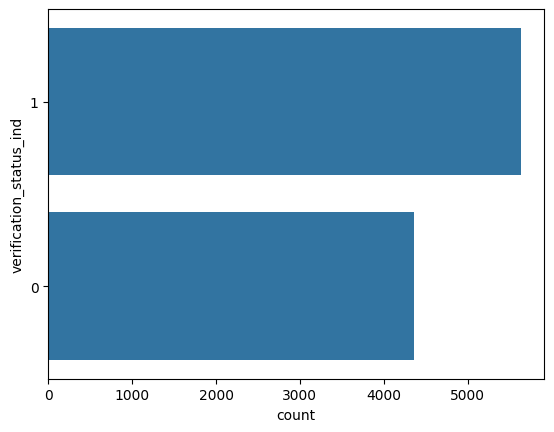

In [218]:
sns.countplot(data=df, y ='verification_status_ind', order=df['verification_status_ind'].value_counts().index)

<Axes: xlabel='count', ylabel='verification_status_ind'>

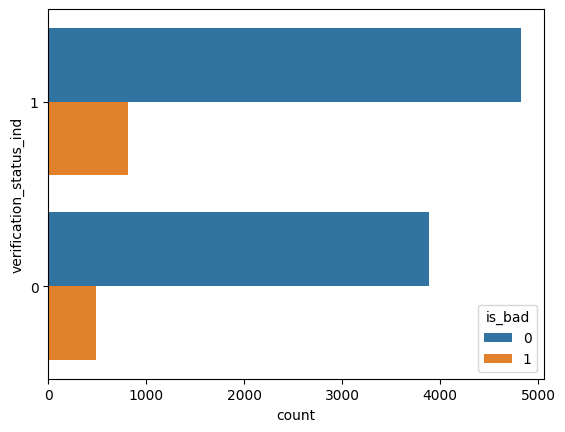

In [219]:
sns.countplot(data=df, y='verification_status_ind', hue="is_bad", order=df['verification_status_ind'].value_counts().index)

<Axes: xlabel='count', ylabel='is_bad'>

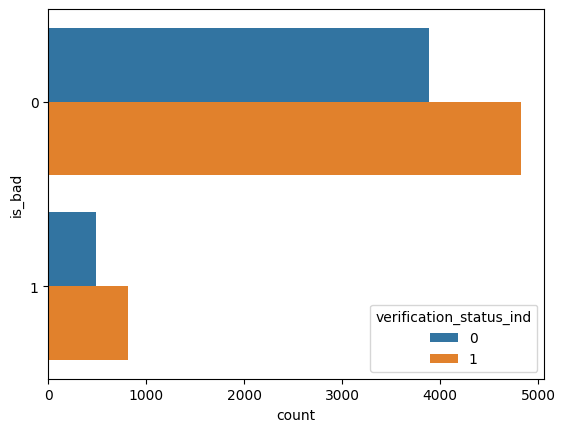

In [220]:
sns.countplot(data=df, y='is_bad', hue="verification_status_ind", order=df['is_bad'].value_counts().index)

   Feature_class  Total_Cust  Is_bad  Percentage_bad
1              1        5633     813              14
0              0        4366     482              11


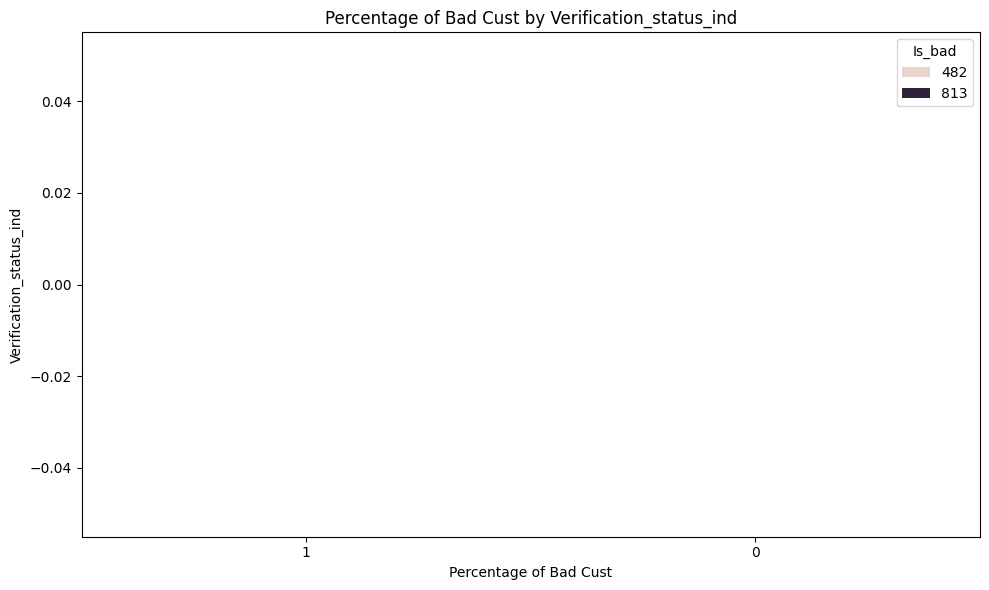

,Feature_class,Total_Cust,Is_bad,Percentage_bad
1,1,5633,813,14
0,0,4366,482,11


In [221]:
is_bad_by_feature_plot(df,'verification_status_ind')

count     9749
unique      13
top         10
freq      2160
Name: emp_length, dtype: object


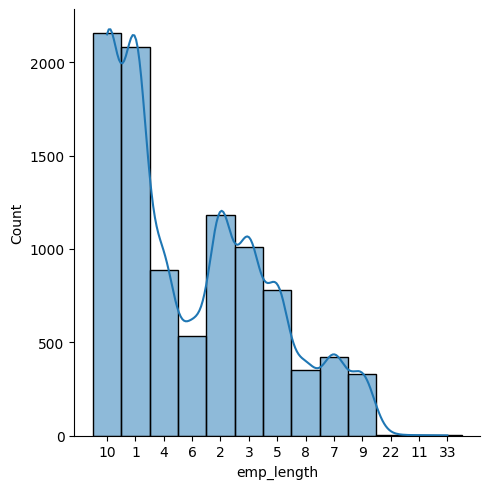

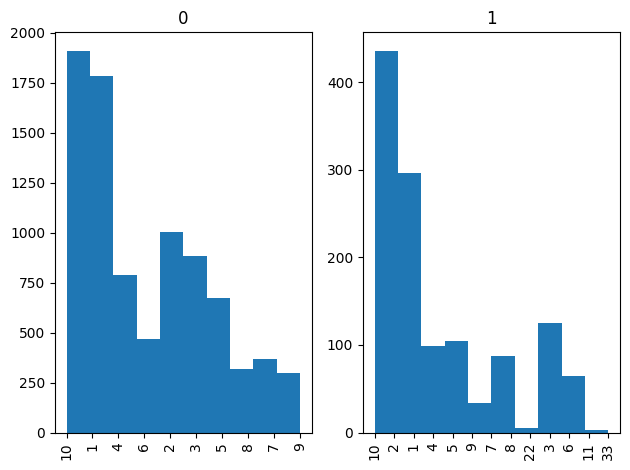

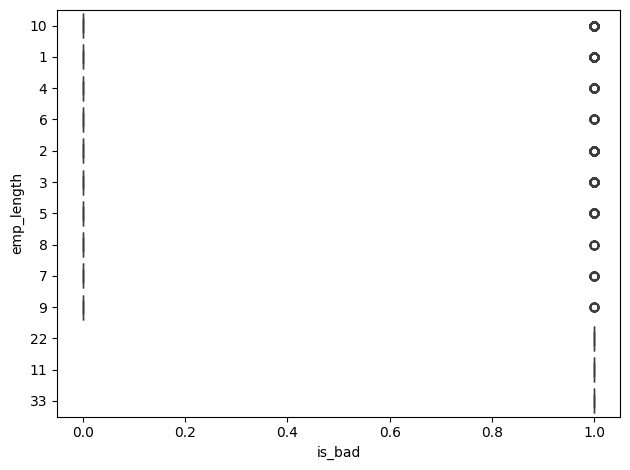

In [223]:

plot_charts(df,'emp_length',0) #before converting to num

In [224]:
df.verification_status.value_counts()

,count
verification_status,
not verified,4366
VERIFIED - income,3214
VERIFIED - income source,2419


<Axes: xlabel='count', ylabel='verification_status'>

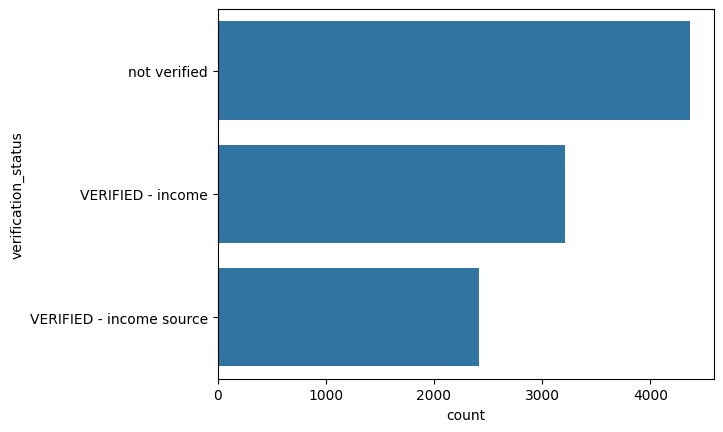

In [225]:
sns.countplot(data=df, y ='verification_status', order=df['verification_status'].value_counts().index)

In [226]:
df.pymnt_plan.value_counts()

,count
pymnt_plan,
n,9997
y,2


<Axes: xlabel='count', ylabel='pymnt_plan'>

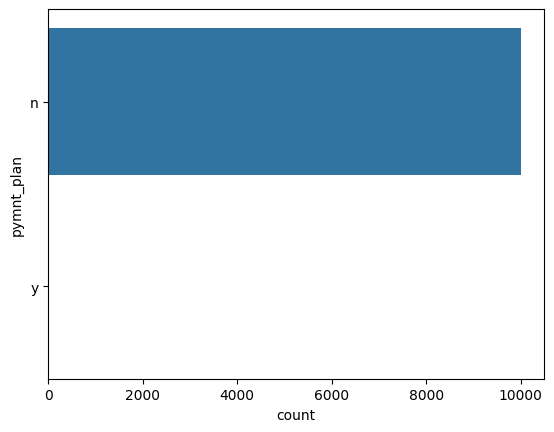

In [227]:
sns.countplot(data=df, y ='pymnt_plan', order=df['pymnt_plan'].value_counts().index)

<Axes: xlabel='count', ylabel='pymnt_plan'>

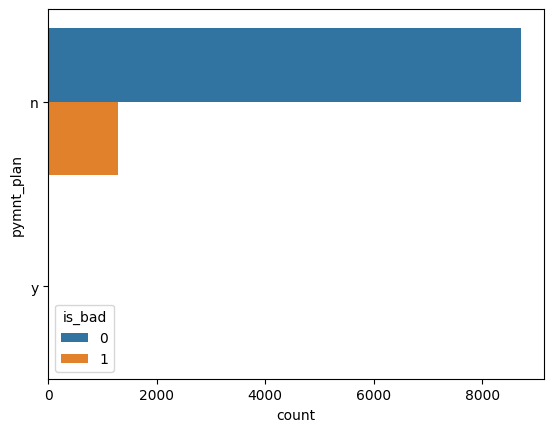

In [228]:
sns.countplot(data=df, y='pymnt_plan', hue="is_bad", order=df['pymnt_plan'].value_counts().index)

In [229]:
df.small_business.value_counts()

,count
small_business,
0,9353
1,646


<Axes: xlabel='count', ylabel='small_business'>

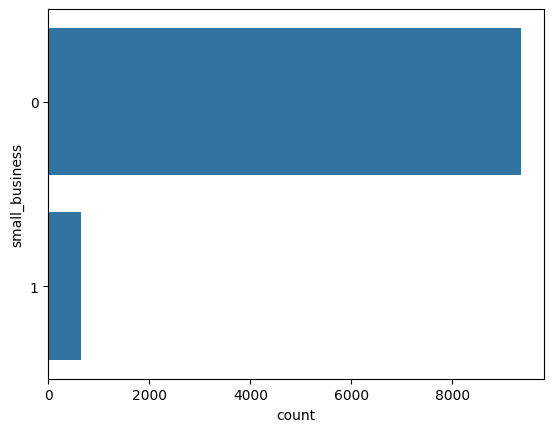

In [230]:
sns.countplot(data=df, y ='small_business', order=df['small_business'].value_counts().index)

<Axes: xlabel='count', ylabel='small_business'>

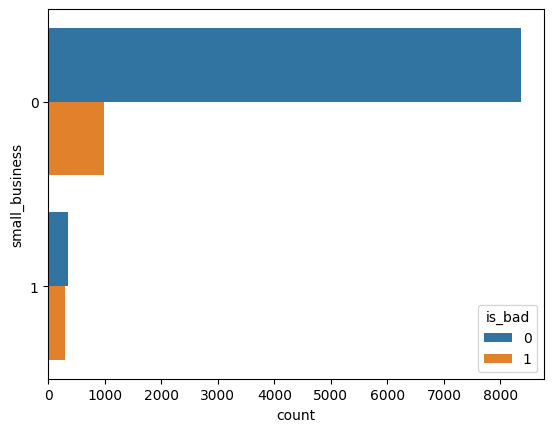

In [231]:
sns.countplot(data=df, y='small_business', hue="is_bad", order=df['small_business'].value_counts().index)

   Feature_class  Total_Cust  Is_bad  Percentage_bad
1              1         646     301              47
0              0        9353     994              11


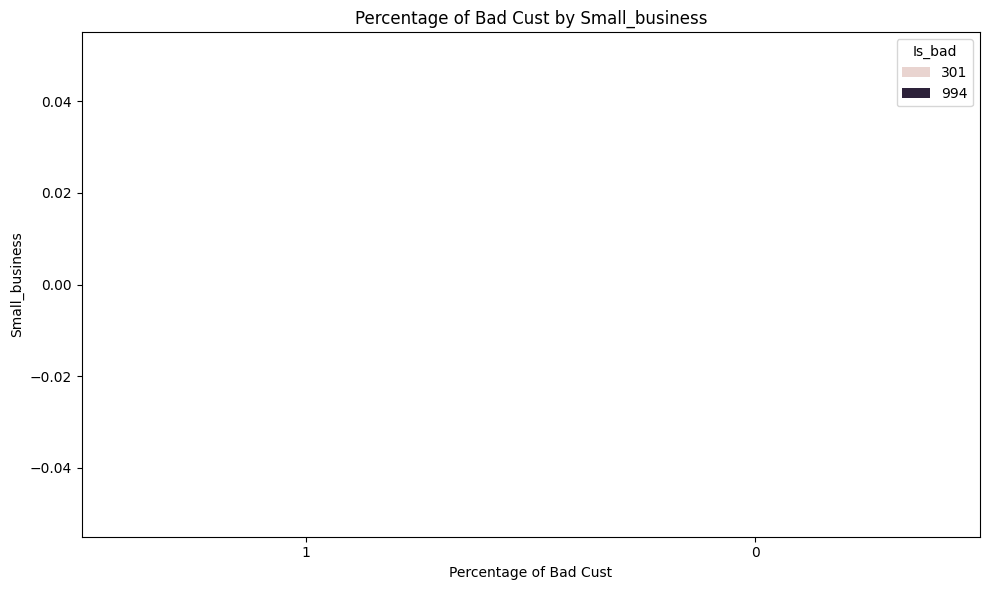

,Feature_class,Total_Cust,Is_bad,Percentage_bad
1,1,646,301,47
0,0,9353,994,11


In [232]:
is_bad_by_feature_plot(df,'small_business')

<Axes: xlabel='count', ylabel='total_acc_imp'>

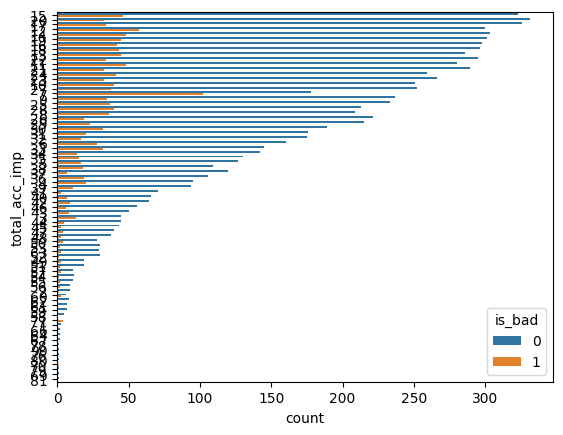

In [233]:
sns.countplot(data=df, y='total_acc_imp', hue="is_bad", order=df['total_acc_imp'].value_counts().index)

Let's take a look at numerical features

In [234]:
# Checking the descriptive statistics of the columns

ndf.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,10000,5000,2887,1,2501,5000,7500,10000
is_bad,10000,0,0,0,0,0,0,1
annual_inc,9999,68203,48590,2000,40000,58000,82000,900000
debt_to_income,10000,13,7,0,8,13,19,30
delinq_2yrs,9995,0,1,0,0,0,0,11
inq_last_6mths,9995,1,1,0,0,1,2,25
mths_since_last_delinq,3684,36,22,0,18,34,53,120
mths_since_last_record,840,62,46,0,0,86,101,119
open_acc,9995,9,5,1,6,9,12,39
pub_rec,9995,0,0,0,0,0,0,3


In [235]:
df.emp_length_num.describe()

,emp_length_num
count,9999
mean,5
std,3
min,1
25%,2
50%,4
75%,8
max,33


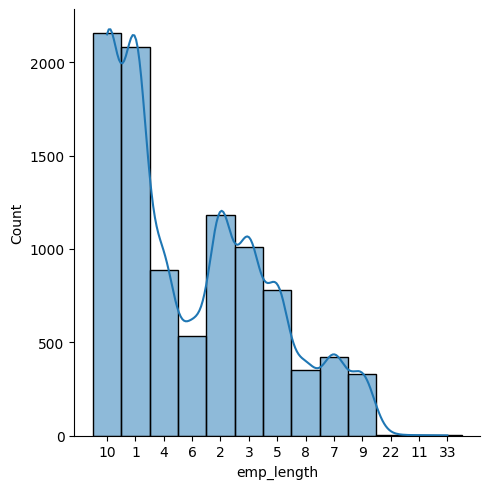

In [236]:
sns.displot(data=df, x='emp_length', kde=True)

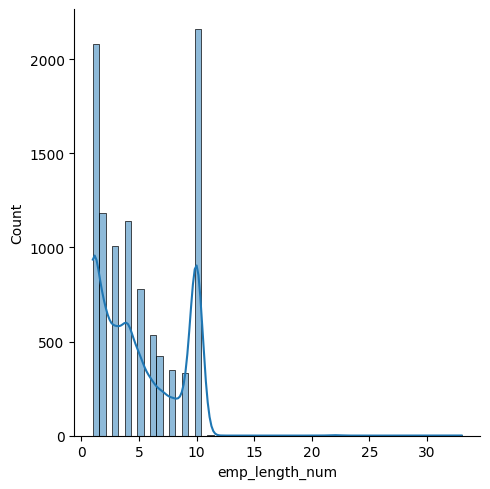

In [237]:
sns.displot(data=df, x='emp_length_num', kde=True)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

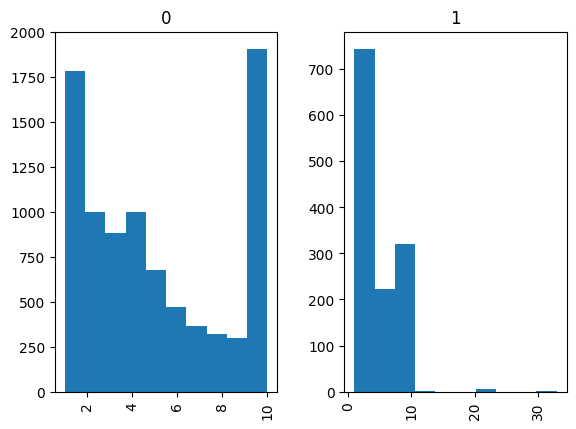

In [238]:
df.hist(by='is_bad',column = 'emp_length_num')

<Axes: xlabel='is_bad', ylabel='emp_length'>

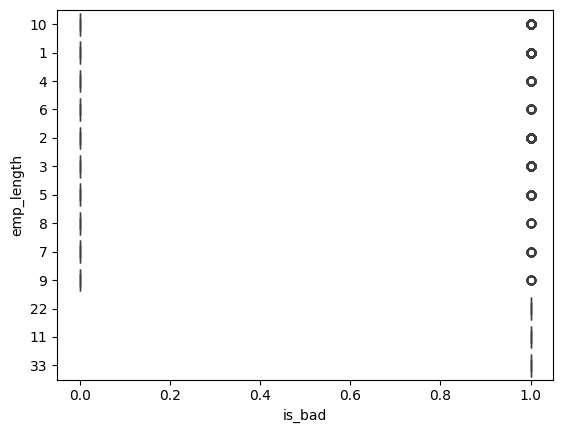

In [239]:
sns.boxplot(x="is_bad", y="emp_length", data=df)

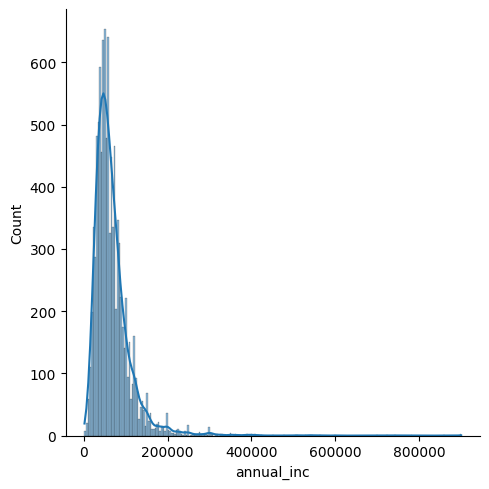

In [240]:
sns.displot(data=df, x='annual_inc', kde=True)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

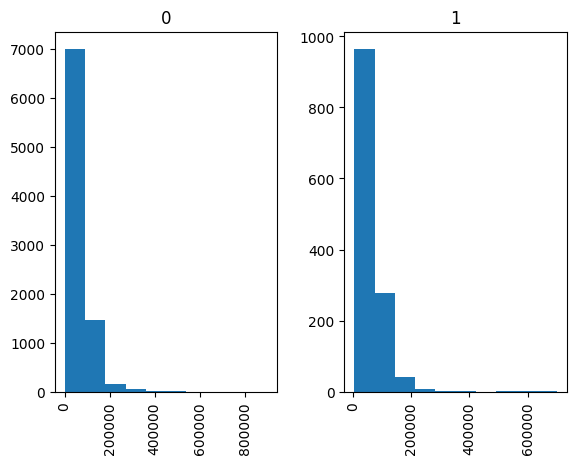

In [241]:
df.hist(by='is_bad',column = 'annual_inc')

<Axes: xlabel='is_bad', ylabel='annual_inc'>

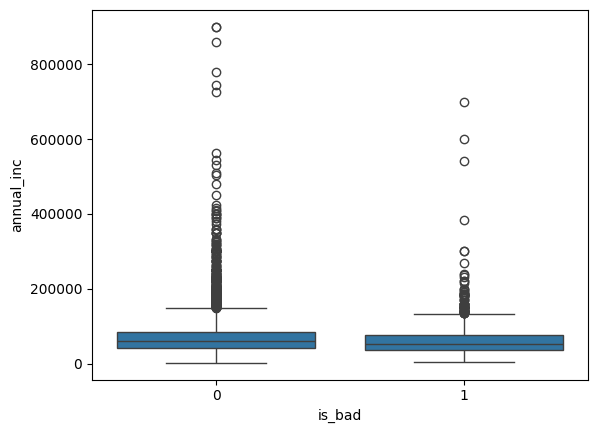

In [242]:
sns.boxplot(x="is_bad", y="annual_inc", data=df)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

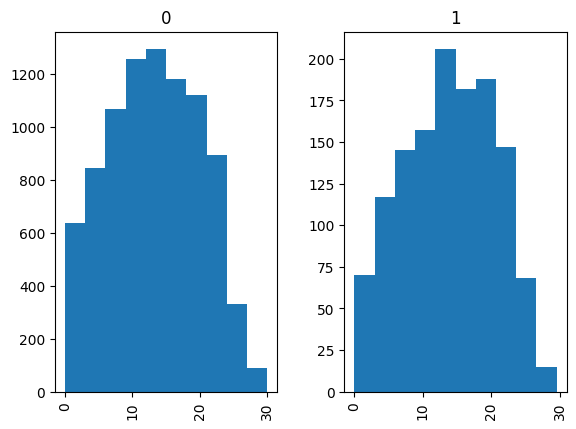

In [243]:
df.hist(by='is_bad',column = 'debt_to_income')

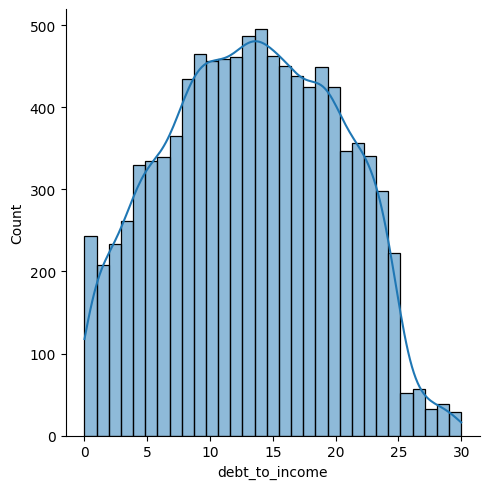

In [244]:
sns.displot(data=df, x='debt_to_income', kde=True)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

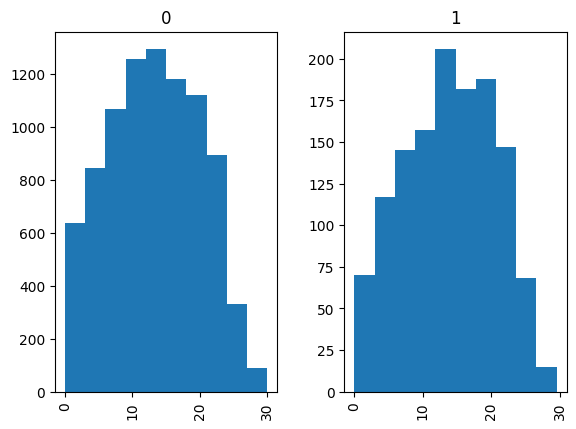

In [245]:
df.hist(by='is_bad',column = 'debt_to_income')

<Axes: xlabel='is_bad', ylabel='debt_to_income'>

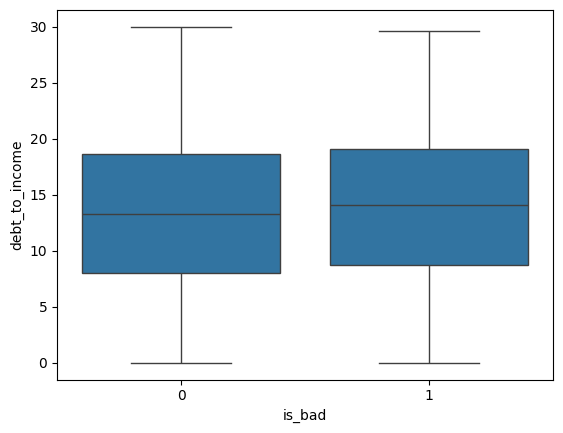

In [246]:
sns.boxplot(x="is_bad", y="debt_to_income", data=df)

In [247]:
# Reset any global rounding that forces 0/1 display
pd.reset_option('display.float_format')
pd.reset_option('display.precision')  # optional
import numpy as np
np.set_printoptions()  # reset numpy formatting

# When printing results, format to 4–6 decimals explicitly:
#with pd.option_context('display.float_format', '{:.6f}'.format):
#    print(corr_table.head(10))

In [248]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ Calculate Cramér's V statistic for two nominal variables """
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

# Select only object and categorical columns from the original dataframe (ndf)
categorical_cols = ndf.select_dtypes(include=['object', 'category']).columns

# Calculate Cramér's V matrix
cramers_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(ndf[col1], ndf[col2])

# Convert to float for better display
cramers_matrix = cramers_matrix.astype(float)

# Display the Cramér's V matrix
display(cramers_matrix)

,emp_title,emp_length,home_ownership,verification_status,pymnt_plan,Notes,purpose_cat,purpose,zip_code,addr_state,earliest_cr_line,initial_list_status,policy_code
emp_title,1.000000,0.947120,0.940369,0.938430,1.000000,0.999292,0.943350,0.934198,0.943584,0.937928,0.939225,0.971780,0.932894
emp_length,0.947120,1.000000,0.134537,0.085418,0.021512,0.999531,0.066174,0.681522,0.276501,0.073174,0.243275,0.032721,0.038520
home_ownership,0.940369,0.134537,1.000000,0.087171,0.004227,0.999760,0.135154,0.838360,0.320644,0.142312,0.284619,0.009600,0.020885
verification_status,0.938430,0.085418,0.087171,1.000000,0.020551,0.999530,0.116622,0.750921,0.274531,0.082264,0.235381,0.013090,0.017508
pymnt_plan,1.000000,0.021512,0.004227,0.020551,0.749950,1.000000,0.069392,0.710052,0.118776,0.059206,0.162444,0.000000,0.017634
Notes,0.999292,0.999531,0.999760,0.999530,1.000000,1.000000,0.999919,0.999474,0.999568,0.999633,0.999381,1.000000,0.999504
purpose_cat,0.943350,0.066174,0.135154,0.116622,0.069392,0.999919,1.000000,0.867499,0.269406,0.078133,0.208774,0.068351,0.051960
purpose,0.934198,0.681522,0.838360,0.750921,0.710052,0.999474,0.867499,1.000000,0.754623,0.776266,0.757880,0.750466,0.753244
zip_code,0.943584,0.276501,0.320644,0.274531,0.118776,0.999568,0.269406,0.754623,1.000000,0.995382,0.278180,0.219856,0.263711
addr_state,0.937928,0.073174,0.142312,0.082264,0.059206,0.999633,0.078133,0.776266,0.995382,1.000000,0.208265,0.044728,0.067676


In [250]:
#print("pandas float_format:", pd.get_option('display.float_format'))
#print("pandas precision  :", pd.get_option('display.precision'))

# show raw (unformatted) numbers
#print(corr_table[['pearson_r','spearman_rho']].head().to_dict('records'))

In [ ]:
#list(corr_table[['feature','pearson_r','spearman_rho']].head(5).itertuples(index=False))

In [251]:
df.dtypes

,0
Id,int64
is_bad,int64
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64
verification_status,object
pymnt_plan,object
Notes,object
purpose_cat,object


In [252]:
ndf.isna().sum()

,0
Id,0
is_bad,0
emp_title,592
emp_length,0
home_ownership,0
annual_inc,1
verification_status,0
pymnt_plan,0
Notes,3231
purpose_cat,0


In [253]:
df.shape

(9999, 180)

In [254]:
df_temp = df.copy()
old_columns = ['id','empl_length','emp_title','Notes','purpose','' 'delinq_2yrs', 'earliest_cr_line_dt', 'inq_last_6mths','mths_since_last_delinq','mths_since_last_record',
               'open_acc','pub_rec','revol_util','total_acc','collections_12_mths_ex_med','earliest_cr_line',
               'delinq_2yrs_na','inq_last_6mths_na','open_acc_na','pub_rec_na','total_acc_na','revol_util_na',
               'mths_since_last_delinq_capped','mths_since_last_record_capped','emp_title']

df_temp = df_temp.drop(columns=old_columns, errors='ignore')

In [256]:
def drop_ohe_by_prefix(df: pd.DataFrame,
                       prefixes=("policy_", "zip3", "purpose_", "home_"),
                       handle_pipeline_prefix: bool = True):
    """
    Drop one-hot encoded columns whose (post-pipeline) names start with any of the
    provided prefixes. For prefixes without a trailing underscore (e.g., 'zip3'),
    this function matches only 'zip3_' to avoid dropping a base column named 'zip3'.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with potential OHE columns.
    prefixes : tuple[str]
        Prefixes to match (e.g., ('policy_', 'zip3', 'purpose_', 'home_')).
    handle_pipeline_prefix : bool
        If True, strip any transformer prefix like 'prep__cat__' before matching.

    Returns
    -------
    df_out : pd.DataFrame
        DataFrame with matching OHE columns removed.
    dropped : list[str]
        Sorted list of dropped column names.
    """
    def matches_prefix(col_name: str) -> bool:
        tail = col_name.split("__")[-1] if handle_pipeline_prefix else col_name
        for p in prefixes:
            # if user gave 'zip3' (no underscore), only match 'zip3_'
            want = p if p.endswith("_") else (p + "_")
            if tail.startswith(want):
                return True
        return False

    dropped = [c for c in df.columns if matches_prefix(c)]
    return df.drop(columns=dropped, errors="ignore"), sorted(dropped)

In [257]:
df_clean, dropped_cols = drop_ohe_by_prefix(df_temp,prefixes=("policy_", "zip3", "purpose_", "home_"))
# print(f"Dropped {len(dropped_cols)} columns. Example:", dropped_cols[:10])


In [258]:
dropped_cols

['home_ownership',
 'home_ownership_MORTGAGE',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'policy_<NA>',
 'policy_PC1',
 'policy_PC2',
 'policy_PC3',
 'policy_PC4',
 'policy_PC5',
 'policy_code',
 'purpose_car',
 'purpose_cat',
 'purpose_cat_new',
 'purpose_credit card',
 'purpose_debt consolidation',
 'purpose_educational',
 'purpose_home improvement',
 'purpose_house',
 'purpose_major purchase',
 'purpose_medical',
 'purpose_moving',
 'purpose_other',
 'purpose_renewable energy',
 'purpose_vacation',
 'purpose_wedding',
 'zip3_010',
 'zip3_018',
 'zip3_021',
 'zip3_028',
 'zip3_060',
 'zip3_064',
 'zip3_068',
 'zip3_070',
 'zip3_076',
 'zip3_080',
 'zip3_088',
 'zip3_100',
 'zip3_103',
 'zip3_104',
 'zip3_105',
 'zip3_109',
 'zip3_111',
 'zip3_112',
 'zip3_113',
 'zip3_117',
 'zip3_152',
 'zip3_180',
 'zip3_190',
 'zip3_191',
 'zip3_194',
 'zip3_200',
 'zip3_201',
 'zip3_207',
 'zip3_208',
 'zip3_210',
 'zip3_212',
 'zip3_220',
 'zip3_223',
 'zip3_275',


In [259]:
df_clean['home_ownership'] = df['home_ownership']
df_clean['policy_code'] = df['policy_code']
df_clean['purpose_cat'] = df['purpose_cat']
#df_clean[] = df['zip_code]

In [260]:
#df_clean.dtypes
df_clean.head()

,Id,is_bad,emp_length,annual_inc,verification_status,pymnt_plan,zip_code,addr_state,debt_to_income,revol_bal,initial_list_status,mths_since_last_major_derog,never_delinq,mths_since_last_delinq_imputed,never_pubrec,mths_since_last_record_imputed,emp_length_num,delinq_2yrs_imp,inq_last_6mths_imp,open_acc_imp,pub_rec_imp,total_acc_imp,revol_util_imp,revol_util_frac,verification_status_ind,pymnt_plan_ind,small_business,zip3,initial_list_status_ind,credit_age_years,home_ownership,policy_code,purpose_cat
0,1,0,10,50000.0,not verified,n,766xx,TX,10.87,12087,f,1,1,121.0,1,120.0,10.0,0,0,15,0,44,12.1,0.121,0,0,0,766,0,18.997947,MORTGAGE,PC4,medical
1,2,0,1,39216.0,not verified,n,660xx,KS,9.15,10114,f,2,1,121.0,1,120.0,1.0,0,2,4,0,5,64.0,0.640,0,0,0,660,0,6.080767,RENT,PC1,debt consolidation
2,3,0,4,65000.0,not verified,n,916xx,CA,11.24,81,f,3,1,121.0,1,120.0,4.0,0,0,4,0,8,0.6,0.006,0,0,0,916,0,41.500342,RENT,PC4,credit card
3,4,0,10,57500.0,not verified,n,124xx,NY,6.18,10030,f,2,0,16.0,1,120.0,10.0,1,0,6,0,23,37.1,0.371,0,0,0,124,0,29.248460,MORTGAGE,PC2,debt consolidation
4,5,0,10,50004.0,VERIFIED - income,n,439xx,OH,19.03,10740,f,3,1,121.0,1,120.0,10.0,0,4,8,0,21,40.4,0.404,1,0,0,439,0,12.167009,MORTGAGE,PC3,debt consolidation


In [261]:
#drop_ohe_by_prefix(df_temp)
df_clean.isna().sum()

,0
Id,0
is_bad,0
emp_length,250
annual_inc,0
verification_status,0
pymnt_plan,0
zip_code,0
addr_state,0
debt_to_income,0
revol_bal,0


In [262]:
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# helper functions
def is_numeric(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def is_categorical(s: pd.Series, max_card=50) -> bool:
    return (not is_numeric(s)) or (s.nunique(dropna=True) <= max_card and not is_numeric(s))

def cramers_v(x, y):
    # Cramér's V with bias correction
    tbl = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tbl)[0]
    n = tbl.sum().sum()
    r, k = tbl.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def correlation_ratio(categories, measurements):
    # η: categorical -> numeric association (0..1)
    cat = pd.Series(categories).astype("category")
    y = pd.Series(measurements).astype(float)
    groups = [y[cat == lev].dropna().values for lev in cat.cat.categories]
    n_total = sum(len(g) for g in groups)
    if n_total == 0 or len(groups) <= 1:
        return np.nan
    y_bar = np.nanmean(y)
    ss_between = sum(len(g) * (np.nanmean(g) - y_bar)**2 for g in groups)
    ss_total = np.nansum((y - y_bar)**2)
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

def point_biserial(x, y):
    # x numeric, y binary {0,1}
    try:
        r, p = stats.pointbiserialr(x, y)
        return r, p
    except Exception:
        return np.nan, np.nan

def safe_mutual_info(X_col, y, task):
    s = pd.Series(X_col)
    x = s.astype("category").cat.codes if not is_numeric(s) else s.fillna(s.median())
    yv = pd.Series(y)
    if task == "classification":
        y_enc = yv.astype("category").cat.codes
        return float(mutual_info_classif(x.values.reshape(-1,1), y_enc, discrete_features=False, random_state=0)[0])
    else:
        return float(mutual_info_regression(x.values.reshape(-1,1), yv.astype(float), random_state=0)[0])

# main function
def rank_feature_associations(df: pd.DataFrame, target: str, top_k=20, max_card_cat=50):
    assert target in df.columns, f"{target=} not in df"
    dfc = df.copy()
    y = dfc[target]
    X = dfc.drop(columns=[target])

    # Basic target type inference
    target_is_numeric = is_numeric(y)
    target_unique = y.nunique(dropna=True)
    if (not target_is_numeric) or target_unique <= 10:
        task = "classification"
    else:
        task = "regression"

    # Clean obvious booleans to 0/1
    for c in X.columns:
        if pd.api.types.is_bool_dtype(X[c]):
            X[c] = X[c].astype("int8")

    rows = []
    for col in X.columns:
        s = X[col]
        # Skip all-null or constant
        if s.dropna().nunique() <= 1:
            rows.append(dict(feature=col, measure="constant", score=np.nan, p_value=np.nan, kind="—"))
            continue

        try:
            if task == "regression":
                # numeric target
                if is_numeric(s):
                    pearson = stats.pearsonr(s.dropna(), y.loc[s.dropna().index].astype(float).dropna())
                    spear = stats.spearmanr(s, y, nan_policy='omit')
                    rows.append(dict(feature=col, measure="Pearson r", score=float(pearson.statistic), p_value=float(pearson.pvalue), kind="num↔num"))
                    rows.append(dict(feature=col, measure="Spearman ρ", score=float(spear.statistic), p_value=float(spear.pvalue), kind="num↔num"))
                else:
                    eta = correlation_ratio(s, y)
                    rows.append(dict(feature=col, measure="Correlation Ratio η", score=float(eta), p_value=np.nan, kind="cat↔num"))
                mi = safe_mutual_info(s, y, task)
                rows.append(dict(feature=col, measure="Mutual Information", score=float(mi), p_value=np.nan, kind="mixed"))
            else:
                # classification target
                # Make binary if target has 2 classes for point-biserial
                y_enc = y.astype("category").cat.codes
                if is_numeric(s):
                    if target_unique == 2:
                        r, p = point_biserial(s, y_enc)
                        rows.append(dict(feature=col, measure="Point-biserial r_pb", score=float(r), p_value=float(p), kind="num↔bin"))
                    # Also add Spearman as a rank-based proxy
                    spear = stats.spearmanr(s, y_enc, nan_policy='omit')
                    rows.append(dict(feature=col, measure="Spearman ρ", score=float(spear.statistic), p_value=float(spear.pvalue), kind="num↔cat"))
                else:
                    cv = cramers_v(s, y)
                    rows.append(dict(feature=col, measure="Cramér's V", score=float(cv), p_value=np.nan, kind="cat↔cat"))
                mi = safe_mutual_info(s, y, task)
                rows.append(dict(feature=col, measure="Mutual Information", score=float(mi), p_value=np.nan, kind="mixed"))
        except Exception as e:
            rows.append(dict(feature=col, measure="error", score=np.nan, p_value=np.nan, kind=str(e)))

    assoc = pd.DataFrame(rows)

    # Summaries: pick best score per feature (absolute value when symmetric around 0)
    def score_for_rank(row):
        if row["measure"] in ["Pearson r", "Spearman ρ", "Point-biserial r_pb"]:
            return abs(row["score"])
        else:
            return row["score"]

    best = (assoc
            .assign(rank_score=assoc.apply(score_for_rank, axis=1))
            .sort_values(["feature","rank_score"], ascending=[True, False])
            .groupby("feature")
            .head(1)
            .sort_values("rank_score", ascending=False)
            .head(top_k))

    # Multicollinearity: numeric features only
    num_cols = [c for c in X.columns if is_numeric(X[c])]
    mc_report = None
    if len(num_cols) >= 2:
        corr = X[num_cols].corr(method="pearson").abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        pairs = [(i,j,upper.loc[i,j]) for i in upper.index for j in upper.columns if i!=j and pd.notna(upper.loc[i,j])]
        pairs_sorted = sorted(pairs, key=lambda t: t[2], reverse=True)
        mc_report = pd.DataFrame(pairs_sorted, columns=["feature_a","feature_b","|corr|"]).query("`|corr|`>=0.8")

    return assoc, best, mc_report

# ---------- example usage ----------
# assoc_all, top_features, multicollinear_pairs = rank_feature_associations(df, target="is_bad", top_k=20)
# top_features  # ranked “best” association per feature
# multicollinear_pairs  # pairs with |corr| >= 0.8


In [263]:
assoc_all, top_features, multicollinear_pairs = rank_feature_associations(df_clean, target="is_bad", top_k=20)

In [264]:
top_features

,feature,measure,score,p_value,kind,rank_score
84,purpose_cat,Cramér's V,0.367607,NaN,cat↔cat,0.367607
70,small_business,Spearman ρ,0.263329,3.001611e-158,num↔cat,0.263329
57,revol_util_imp,Point-biserial r_pb,0.087844,1.369633e-18,num↔bin,0.087844
60,revol_util_frac,Point-biserial r_pb,0.087844,1.369633e-18,num↔bin,0.087844
3,emp_length,Cramér's V,0.080794,NaN,cat↔cat,0.080794
6,annual_inc,Spearman ρ,-0.072129,5.157296e-13,num↔cat,0.072129
72,zip3,Cramér's V,0.064137,NaN,cat↔cat,0.064137
12,zip_code,Cramér's V,0.064137,NaN,cat↔cat,0.064137
55,total_acc_imp,Spearman ρ,-0.063113,2.674967e-10,num↔cat,0.063113
14,addr_state,Cramér's V,0.054158,NaN,cat↔cat,0.054158


In [267]:
multicollinear_pairs

,feature_a,feature_b,|corr|
0,revol_util_imp,revol_util_frac,1.00000
1,never_delinq,mths_since_last_delinq_imputed,0.94947


In [268]:
df_clean.shape

(9999, 33)

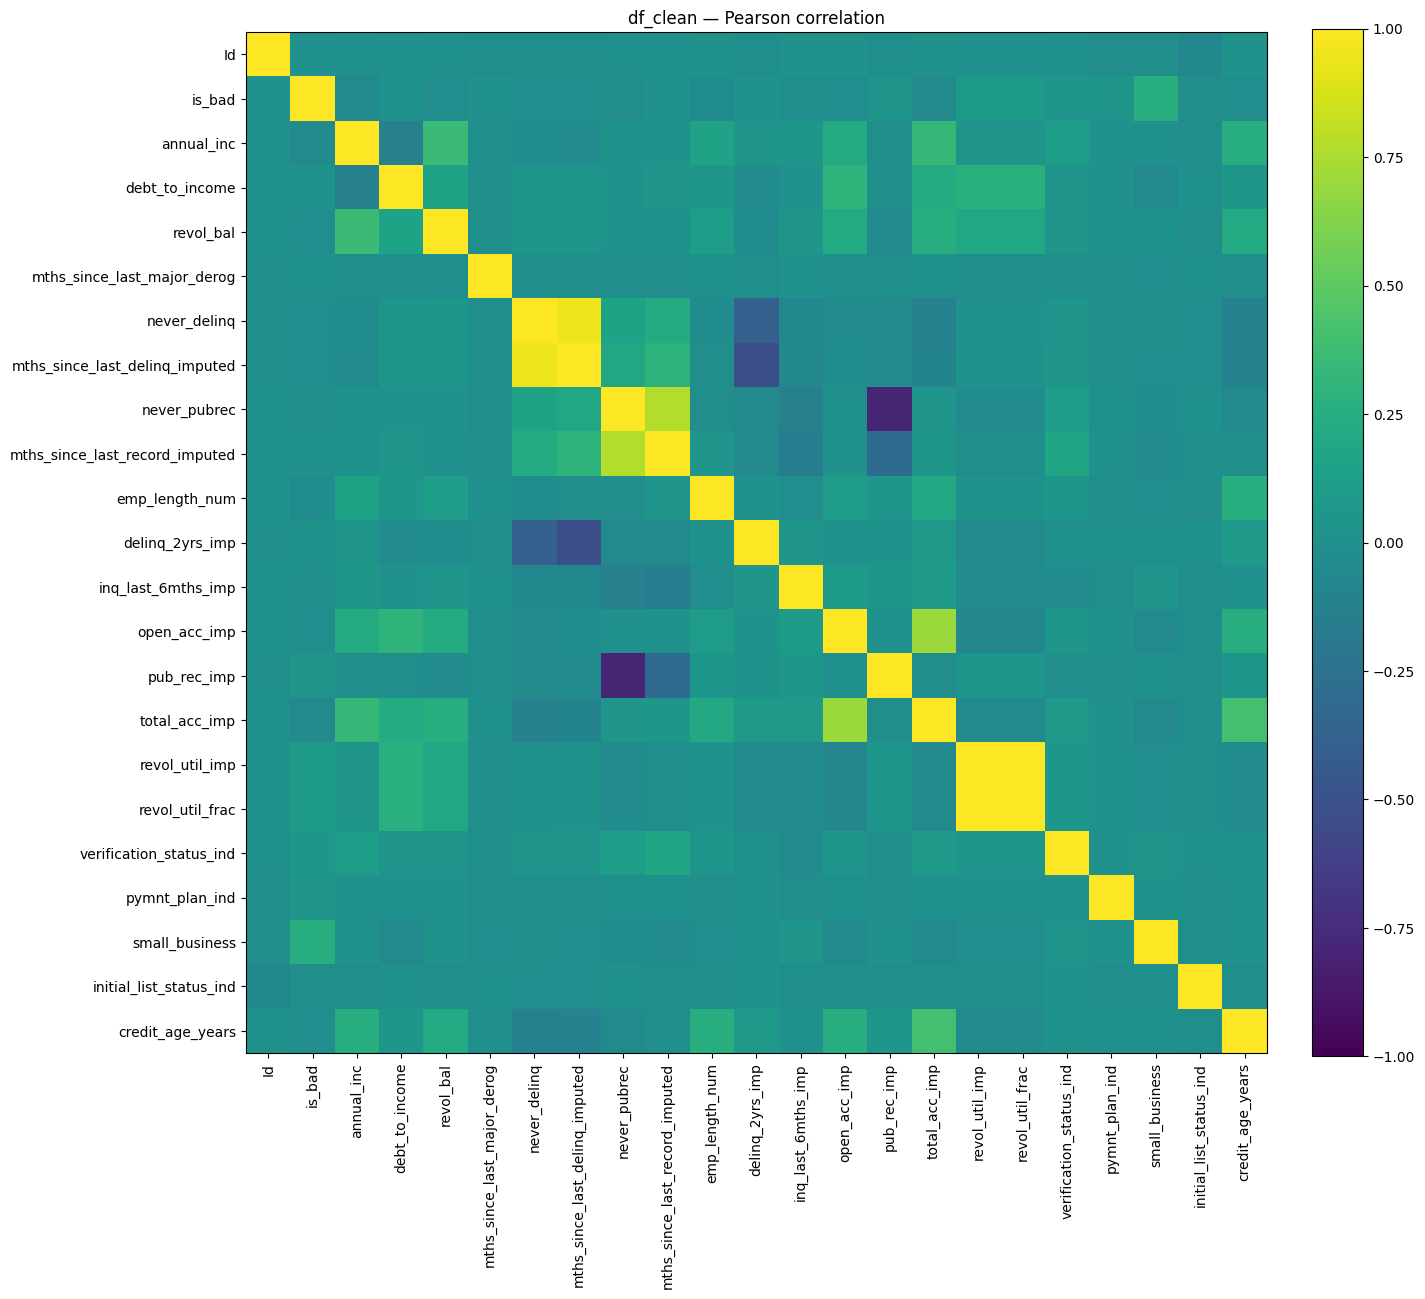

Top correlated pairs (Pearson):
revol_util_imp  revol_util_frac                   1.000000
never_delinq    mths_since_last_delinq_imputed    0.949470
never_pubrec    pub_rec_imp                       0.790148
                mths_since_last_record_imputed    0.770752
open_acc_imp    total_acc_imp                     0.695387
dtype: float64


In [269]:
import matplotlib.pyplot as plt

# 1) Choose numeric columns (corr is only defined for numerics)
num_cols = df_clean.select_dtypes(include=[np.number]).columns

# 2) Correlation matrices (Pearson = default; Spearman optional)
corr_pearson  = df_clean[num_cols].corr(method="pearson")
corr_spearman = df_clean[num_cols].corr(method="spearman")  # optional

# 3) Save to CSV (optional)
corr_pearson.to_csv("df_clean_corr_pearson.csv")
corr_spearman.to_csv("df_clean_corr_spearman.csv")

# 4) Heatmap helper (matplotlib; single plot; default colors)
def plot_corr(cm: pd.DataFrame, title: str):
    n = len(cm.columns)
    fig, ax = plt.subplots(figsize=(min(20, 0.45*n+4), min(20, 0.45*n+4)))
    im = ax.imshow(cm.values, vmin=-1, vmax=1)  # default colormap
    ax.set_xticks(np.arange(n))
    ax.set_xticklabels(cm.columns, rotation=90)
    ax.set_yticks(np.arange(n))
    ax.set_yticklabels(cm.columns)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# View Pearson (comment/uncomment as you like)
plot_corr(corr_pearson, "df_clean — Pearson correlation")
# plot_corr(corr_spearman, "df_clean — Spearman correlation")

# 5) Quick multicollinearity view: strongest pairs
def strongest_pairs(cm: pd.DataFrame, top_k=25, min_abs=0.6):
    c = cm.abs()
    upper = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False)  # (feature_i, feature_j) -> |corr|
    if min_abs is not None:
        pairs = pairs[pairs >= min_abs]
    return pairs.head(top_k)

print("Top correlated pairs (Pearson):")
print(strongest_pairs(corr_pearson, top_k=25, min_abs=0.6))

In [276]:
def parse_binary_target(y):
    """Return a float Series of 0/1 (with NaNs for anything unparseable)."""
    s = pd.Series(y)

    # Already numeric/bool → coerce to 0/1 floats
    if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
        return pd.to_numeric(s, errors="coerce").astype(float)

    # Map common string encodings
    sl = s.astype(str).str.strip().str.lower()
    mapping = {
        "1": 1, "0": 0,
        "true": 1, "false": 0, "t": 1, "f": 0,
        "yes": 1, "no": 0, "y": 1, "n": 0,
        "bad": 1, "good": 0,
        "default": 1, "defaulted": 1,
        "non-default": 0, "nondefault": 0, "fully paid": 0, "charged off": 1
    }
    out = sl.map(mapping)

    # Fallback: try numeric strings (e.g., "0", "1")
    out = out.where(~out.isna(), pd.to_numeric(sl, errors="coerce"))

    # Final fallback: if exactly 2 unique labels, map them deterministically
    if out.isna().all():
        vals = sl.dropna().unique()
        if len(vals) == 2:
            a, b = sorted(vals)  # stable mapping
            out = sl.map({a: 0, b: 1}).astype(float)

    return out.astype(float)

In [277]:
from scipy import stats

def correlation_with_target_strict(df: pd.DataFrame, target: str = "is_bad"):
    assert target in df.columns
    y_raw = df[target]
    # Parse target robustly
    y_num = parse_binary_target(y_raw)

    rows = []
    for col in df.columns:
        if col == target:
            continue
        s = df[col]
        if not pd.api.types.is_numeric_dtype(s):
            rows.append({"feature": col, "pearson_r": np.nan, "pearson_p": np.nan,
                         "spearman_rho": np.nan, "spearman_p": np.nan, "n": 0,
                         "note": "non-numeric"})
            continue

        sx = pd.to_numeric(s, errors="coerce").astype(float)
        m = sx.notna() & y_num.notna()
        sx, sy = sx[m], y_num[m]

        if len(sx) < 3:
            note = "insufficient n"
            pr = pp = sr = sp = np.nan
        elif sx.nunique() < 2:
            note = "feature constant"
            pr = pp = sr = sp = np.nan
        elif sy.nunique() < 2:
            note = "target constant after mask"
            pr = pp = sr = sp = np.nan
        else:
            pr = stats.pearsonr(sx, sy).statistic
            pp = stats.pearsonr(sx, sy).pvalue
            sp_res = stats.spearmanr(sx, sy, nan_policy="omit")
            sr, sp = float(sp_res.statistic), float(sp_res.pvalue)
            note = ""

        rows.append({"feature": col, "pearson_r": pr, "pearson_p": pp,
                     "spearman_rho": sr, "spearman_p": sp, "n": int(len(sx)), "note": note})

    out = pd.DataFrame(rows)
    out = (out
           .assign(rank_score=np.abs(out["pearson_r"]))
           .sort_values(["rank_score", "spearman_rho"], ascending=[False, False])
           .drop(columns=["rank_score"]))
    return out

In [278]:
corr_table = correlation_with_target_strict(df_clean, target='is_bad')

In [279]:
corr_table_sorted = corr_table.sort_values("pearson_r", ascending=False)


Looking a tthe above table:

* **feature** — the predictor being tested against your target (is_bad).

* **pearson_r** — Pearson correlation coefficient (linear association). Range [-1, 1].

  * **Sign**: + means as the feature increases, is_bad tends to increase; - means the opposite.

  * **Magnitude**: |r| close to 0 = weak; ~0.1 small, ~0.3 medium, ~0.5+ large (rough Cohen-style rule of thumb).

* **pearson_p** — p-value for the null hypothesis r = 0 (two-sided). Very small p means the observed r is unlikely under “no linear association.” With large n, even tiny r can be “statistically significant.”

* **spearman_rho** — Spearman rank correlation (monotonic association). Also in [-1, 1]. Less sensitive to outliers and linearity; compares ranks instead of raw values.

* **spearman_p** — p-value for the null hypothesis ρ = 0 (two-sided).

* **n** — number of rows used in the calculation (after joint NaN filtering).

* **note** — diagnostic flag (e.g., “non-numeric”, “constant/insufficient”, etc.). Blank means no issue.

In [280]:
corr_table_sorted

,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n,note
25,small_business,0.263329,3.001611e-158,0.263329,3.001611e-158,9999,
21,revol_util_imp,0.087844,1.369633e-18,0.087781,1.448788e-18,9999,
22,revol_util_frac,0.087844,1.369633e-18,0.087781,1.448788e-18,9999,
23,verification_status_ind,0.050118,5.328453e-07,0.050118,5.328453e-07,9999,
24,pymnt_plan_ind,0.036669,2.448960e-04,0.036669,2.448960e-04,9999,
19,pub_rec_imp,0.032210,1.276417e-03,0.034322,5.978949e-04,9999,
7,debt_to_income,0.029808,2.873936e-03,0.030728,2.119291e-03,9999,
16,delinq_2yrs_imp,0.021886,2.863475e-02,0.016724,9.448160e-02,9999,
10,mths_since_last_major_derog,0.015481,1.216320e-01,0.015475,1.217878e-01,9999,
14,mths_since_last_record_imputed,0.014633,1.434289e-01,-0.013317,1.830132e-01,9999,


* **small_business** (r ≈ 0.263): Positive, small-to-moderate association. With a binary target, you can loosely think of r² ≈ 0.069 (~7%) as the proportion of linear variance explained (interpret cautiously for a binary y, but it signals a stronger signal than others). Pearson and Spearman are identical → relationship is fairly monotonic and close to linear.

* **revol_util_imp** / **revol_util_frac** (r ≈ 0.088): Very small positive association. The two are essentially duplicates (same signal) → consider dropping one.

* **verification_status_ind** (r ≈ 0.050) and **pymnt_plan_ind** (r ≈ 0.037): Tiny effects. With n = 9,999, even tiny r becomes highly significant (p ≪ 0.001). Treat as statistically significant but practically weak.

In [282]:
def fdr_bh(pvals: pd.Series) -> pd.Series:
    """Benjamini–Hochberg FDR for a 1D array/Series of p-values (NaN-safe)."""
    p = pvals.values.astype(float)
    mask = ~np.isnan(p)
    p_clean = p[mask]
    n = p_clean.size
    if n == 0:
        return pd.Series([np.nan]*len(p), index=pvals.index)

    order = np.argsort(p_clean)
    ranked = p_clean[order]
    # BH step-up
    bh = ranked * n / (np.arange(1, n+1))
    # enforce monotonicity
    bh = np.minimum.accumulate(bh[::-1])[::-1]
    # put back to original positions
    q = np.empty_like(p, dtype=float)
    q[:] = np.nan
    q_masked = np.empty_like(p_clean, dtype=float)
    q_masked[order] = np.clip(bh, 0, 1)
    q[mask] = q_masked
    return pd.Series(q, index=pvals.index)

# ---- augment your corr_table ----
corr_aug = corr_table.copy()

# absolute effects
corr_aug["abs_pearson_r"]  = corr_aug["pearson_r"].abs()
corr_aug["abs_spearman_r"] = corr_aug["spearman_rho"].abs()

# FDR-adjusted p-values
corr_aug["pearson_q"]  = fdr_bh(corr_aug["pearson_p"])
corr_aug["spearman_q"] = fdr_bh(corr_aug["spearman_p"])

# ranks (1 = strongest |r|)  <-- changed to nullable Int64 to allow NaNs
corr_aug["rank_by_|r|"]   = corr_aug["abs_pearson_r"].rank(method="dense", ascending=False).astype("Int64")
corr_aug["rank_by_|rho|"] = corr_aug["abs_spearman_r"].rank(method="dense", ascending=False).astype("Int64")

# pretty view: Top 20 by |Pearson r|
cols = ["feature","pearson_r","pearson_p","pearson_q",
        "spearman_rho","spearman_p","spearman_q",
        "abs_pearson_r","abs_spearman_r","rank_by_|r|","n","note"]

top20 = (corr_aug
         .sort_values("abs_pearson_r", ascending=False)
         .loc[:, cols]
         .head(20))

with pd.option_context('display.float_format', '{:.6f}'.format):
    print(top20)




                           feature  pearson_r  pearson_p  pearson_q  \
25                  small_business   0.263329   0.000000   0.000000   
21                  revol_util_imp   0.087844   0.000000   0.000000   
22                 revol_util_frac   0.087844   0.000000   0.000000   
20                   total_acc_imp  -0.055279   0.000000   0.000000   
2                       annual_inc  -0.050975   0.000000   0.000001   
23         verification_status_ind   0.050118   0.000001   0.000002   
24                  pymnt_plan_ind   0.036669   0.000245   0.000770   
19                     pub_rec_imp   0.032210   0.001276   0.003510   
7                   debt_to_income   0.029808   0.002874   0.007025   
15                  emp_length_num  -0.024192   0.015556   0.034224   
16                 delinq_2yrs_imp   0.021886   0.028635   0.057269   
18                    open_acc_imp  -0.020344   0.041929   0.076870   
11                    never_delinq  -0.017829   0.074630   0.126297   
28    

In [283]:
top20_sorted = top20.sort_values("pearson_r", ascending=False)


In [284]:
top20_sorted

,feature,pearson_r,pearson_p,pearson_q,spearman_rho,spearman_p,spearman_q,abs_pearson_r,abs_spearman_r,rank_by_|r|,n,note
25,small_business,0.263329,3.001611e-158,6.603544e-157,0.263329,3.001611e-158,6.603544e-157,0.263329,0.263329,1,9999,
21,revol_util_imp,0.087844,1.369633e-18,1.004397e-17,0.087781,1.448788e-18,1.062444e-17,0.087844,0.087781,2,9999,
22,revol_util_frac,0.087844,1.369633e-18,1.004397e-17,0.087781,1.448788e-18,1.062444e-17,0.087844,0.087781,2,9999,
23,verification_status_ind,0.050118,5.328453e-07,1.953766e-06,0.050118,5.328453e-07,1.953766e-06,0.050118,0.050118,5,9999,
24,pymnt_plan_ind,0.036669,2.448960e-04,7.696730e-04,0.036669,2.448960e-04,7.696730e-04,0.036669,0.036669,6,9999,
19,pub_rec_imp,0.032210,1.276417e-03,3.510146e-03,0.034322,5.978949e-04,1.644211e-03,0.032210,0.034322,7,9999,
7,debt_to_income,0.029808,2.873936e-03,7.025177e-03,0.030728,2.119291e-03,4.662440e-03,0.029808,0.030728,8,9999,
16,delinq_2yrs_imp,0.021886,2.863475e-02,5.726950e-02,0.016724,9.448160e-02,1.299122e-01,0.021886,0.016724,10,9999,
10,mths_since_last_major_derog,0.015481,1.216320e-01,1.553835e-01,0.015475,1.217878e-01,1.553835e-01,0.015481,0.015475,16,9999,
14,mths_since_last_record_imputed,0.014633,1.434289e-01,1.660755e-01,-0.013317,1.830132e-01,2.119100e-01,0.014633,0.013317,18,9999,


### **Creating model**

In [285]:
#numerical_features_all = df.select_dtypes(include=['int64', 'float64', 'int8', 'Int64'])

In [286]:
#numerical_features = ['annual_inc', 'debt_to_income', 'delinq_2yrs_imp','inq_last_6mths_imp', 'mths_since_last_delinq_imputed','mths_since_last_record_imputed']

In [287]:
ndf.mths_since_last_record.describe()

,mths_since_last_record
count,840.000000
mean,61.652381
std,46.189619
min,0.000000
25%,0.000000
50%,86.000000
75%,101.000000
max,119.000000


In [288]:
df.mths_since_last_record_imputed.describe()

,mths_since_last_record_imputed
count,9999.000000
mean,115.098310
std,21.000868
min,0.000000
25%,120.000000
50%,120.000000
75%,120.000000
max,120.000000


In [289]:
# Convert boolean columns to integers (0 and 1)
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

# Display the data types to verify the conversion
display(df.dtypes[df.dtypes == 'int'])

,0
Id,int64
is_bad,int64
revol_bal,int64
mths_since_last_major_derog,int64
never_delinq,int64
never_pubrec,int64
delinq_2yrs_na,int64
inq_last_6mths_na,int64
open_acc_na,int64
pub_rec_na,int64


#### **Removing unnecessary columns**

Before building model, let's define the dataset and remove fearues that are not needed anymore.

In [290]:
df2 = df.copy() # saving copy just in case; we can use it for more explanatory data analysis

In [291]:
# List of columns to drop
columns_to_drop = [
    'Id',                      # Identifier column
    'emp_title',               # High cardinality, many missing values
    'emp_length',              # Replaced by emp_length_num
    'title',                   # High cardinality, redundant with purpose_cat
    'home_ownership',          # Replaced by one-hot encoded columns
    'verification_status',     # Replaced by indicator column
    'pymnt_plan',              # Replaced by indicator column
    'Notes',                   # Many missing values, likely not useful
    'purpose_cat',             # Replaced by purpose_cat_new and small_business
    'purpose',                 # Similar to purpose_cat, redundant
    'zip_code',                # Replaced by zip3 and zip3_topK
    'addr_state',              # Can be dropped if zip3 is used
    'earliest_cr_line',        # Replaced by engineered feature 'credit_age_years'
    'mths_since_last_delinq',  # Replaced by imputed/indicator features
    'mths_since_last_record',  # Replaced by imputed/indicator features
    'delinq_2yrs',             # Replaced by imputed/indicator features
    'inq_last_6mths',          # Replaced by imputed/indicator features
    'open_acc',                # Replaced by imputed/indicator features
    'pub_rec',                 # Replaced by imputed/indicator features
    'revol_util',              # Replaced by imputed/indicator features
    'total_acc',               # Replaced by imputed/indicator features
    'collections_12_mths_ex_med', # Mostly zero values
    'mths_since_last_delinq_capped', # Intermediate column
    'mths_since_last_record_capped', # Intermediate column (though it was commented out, it's good practice to include)
    'zip3', # Intermediate column
    'zip3_topK', # Intermediate column
    'purpose_cat_new', # Replaced by one-hot encoded columns
    'earliest_cr_line_dt', # Intermediate datetime object
    'initial_list_status', # Replaced by indicator column  'initial_list_status_ind'
    'policy_code' # Replaced by one-hot encoded columns


]

# Drop the columns
df = df.drop(columns=columns_to_drop, errors='ignore')

# Display the remaining columns and info to verify
display(df.columns)
df.info()

Index(['is_bad', 'annual_inc', 'debt_to_income', 'revol_bal',
       'mths_since_last_major_derog', 'never_delinq',
       'mths_since_last_delinq_imputed', 'never_pubrec',
       'mths_since_last_record_imputed', 'emp_length_num',
       ...
       'purpose_other', 'purpose_renewable energy', 'purpose_vacation',
       'purpose_wedding', 'home_ownership_MORTGAGE', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'initial_list_status_ind',
       'credit_age_years'],
      dtype='object', length=152)

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Columns: 152 entries, is_bad to credit_age_years
dtypes: Int64(5), boolean(6), float64(8), int64(132), int8(1)
memory usage: 11.3 MB


#### **Scaling the data**

In [292]:
numerical_features = ['annual_inc', 'debt_to_income','revol_bal','mths_since_last_major_derog',
                      'mths_since_last_delinq_imputed','mths_since_last_record_imputed', 'emp_length_num',
                      'delinq_2yrs_imp','inq_last_6mths_imp','open_acc_imp','pub_rec_imp', 'total_acc_imp',
                      'revol_util_imp','credit_age_years', 'revol_util_frac']

In [293]:
# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

df_scaled_all=df.copy()

# Selecting the numerical features from the DataFrame
numerical_df_to_scale = df[numerical_features]

scaler = StandardScaler()
df_scaled_values = scaler.fit_transform(numerical_df_to_scale)

# Creating a new DataFrame with scaled values and original column names
df_scaled = pd.DataFrame(df_scaled_values, columns=numerical_features, index=df.index)

# Replacing the original numerical columns in df with the scaled ones
for col in numerical_features:
    df_scaled_all[col] = df_scaled[col] # combined scaled numerical columns plus categorical ones

# Displaying the first few rows of the DataFrame with scaled numerical features
display(df_scaled_all.shape)

(9999, 152)

In [294]:
# scaled dataframe
df_scaled_all.shape

(9999, 152)

In [295]:
df.is_bad.value_counts()

,count
is_bad,
0,8704
1,1295


In [317]:
# Create feature matrix X (all columns except 'is_bad')
X = df.drop('is_bad', axis=1)

# Create target vector y ('is_bad' column)
y = df['is_bad']

# Display the shapes of X and y to verify
display(X.shape)
display(y.shape)

(9999, 151)

(9999,)

#### **Balancing the data**


Since out data set is very imbalanced, before I create the model, I want to make sure I am having balanced date set (only for the trianing data set, which is already taken care of in the *run_model* function)

In [318]:
# function to call/run different models for different datasets

# balancing = 0, we're not trying to balance our dataset
# balancing = 1, we are balancing our dataset (only for traning data)

def run_model(X, y, test_size_p, model_p, balancing=0, conf_m = 0):


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size_p, random_state=78978
    )

    # Removed feature name sanitization from here as it's handled before calling the function


    model = model_p

    # I am using resampling for balancing since our dataset is pretty small and
    # the class we're interested in is only 13% of the set
    if balancing == 1:
      smote = SMOTE(random_state=42)
      # Convert to numpy arrays for SMOTE if not already
      if not isinstance(X_train, np.ndarray):
          X_train_resample = X_train.to_numpy(dtype=np.float64)
      else:
          X_train_resample = X_train

      X_resampled, y_resampled = smote.fit_resample(X_train_resample, y_train)

      # Convert back to DataFrame to keep column names for XGBoost if needed later
      # Note: SMOTE output is typically numpy array, column names are lost
      # If needed for later steps, handle this conversion and name assignment carefully
      # For now, fitting the model directly with numpy array output of SMOTE is fine


      model.fit(X_resampled, y_resampled)

    else:
       # Convert to numpy arrays for fitting if not already (some models like SVC might prefer this)
      if not isinstance(X_train, np.ndarray):
          X_train_fit = X_train.to_numpy(dtype=np.float64)
      else:
          X_train_fit = X_train

      model.fit(X_train_fit, y_train)

    # Convert X_test to numpy array for prediction if not already
    if not isinstance(X_test, np.ndarray):
        X_test_pred = X_test.to_numpy(dtype=np.float64)
    else:
        X_test_pred = X_test


    y_pred = model.predict(X_test_pred)

    accur = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = metrics.roc_auc_score(y_test, y_pred)

    metrics_vec = [model_p, accur, prec, rec, f1, roc_auc]

    print("----------------------------------------------------------------------")
    print(model_p)
    print(metrics.classification_report(y_test, y_pred))
    print(metrics.confusion_matrix(y_test, y_pred))
    print("Accuracy: ")
    print(accur)
    print("Precision: ")
    print(prec)
    print("Recall: ")
    print(rec)
    print("F1: ")
    print(f1)
    print("ROC AUC: ")
    print(roc_auc)

    if conf_m == 1:
      cm = metrics.confusion_matrix(y_test, y_pred)
      disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
      disp.plot()
      plt.show()

    elif conf_m == 2:
      display(pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True))
    else:
      pass

    return metrics_vec

In [319]:
import matplotlib.pyplot as plt

def run_model_2(X, y, test_size_p, model_p, balancing=0, conf_m=0):
    # stratify to preserve class mix
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size_p, random_state=78978, stratify=y
    )

    model = model_p

    # Balance only if requested AND inputs are not already resampled
    if balancing == 1:
        smote = SMOTE(random_state=42)
        X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy(dtype=np.float64)
        X_resampled, y_resampled = smote.fit_resample(X_train_np, y_train)
        model.fit(X_resampled, y_resampled)
    else:
        X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy(dtype=np.float64)
        model.fit(X_train_np, y_train)

    # Ensure numpy for prediction
    X_test_pred = X_test if isinstance(X_test, np.ndarray) else X_test.to_numpy(dtype=np.float64)

    # Scores (needed for ROC/PR)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_pred)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_pred)
    else:
        # fallback: use labels (works for CM; ROC/PR are less meaningful)
        y_score = model.predict(X_test_pred)

    y_pred = (y_score >= 0.5).astype(int) if y_score.ndim == 1 else model.predict(X_test_pred)

    # Metrics (AUC uses scores, not labels)
    accur = metrics.accuracy_score(y_test, y_pred)
    prec  = metrics.precision_score(y_test, y_pred, zero_division=0)
    rec   = metrics.recall_score(y_test, y_pred, zero_division=0)
    f1    = metrics.f1_score(y_test, y_pred, zero_division=0)
    roc_auc = metrics.roc_auc_score(y_test, y_score) if y_score.ndim == 1 else np.nan

    metrics_vec = [model, accur, prec, rec, f1, roc_auc]

    print("----------------------------------------------------------------------")
    print(model_p)
    print(metrics.classification_report(y_test, y_pred))
    print(metrics.confusion_matrix(y_test, y_pred))
    print("Accuracy:", accur)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC AUC:", roc_auc)

    # ---- Plots ----
    if conf_m == 1:
        cm = metrics.confusion_matrix(y_test, y_pred)
        metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.array([0,1])).plot()

        # New API (works across versions)
        metrics.RocCurveDisplay.from_predictions(y_test, y_score)
        metrics.PrecisionRecallDisplay.from_predictions(y_test, y_score)
        plt.show()

        display(pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True))

    elif conf_m == 2:
        display(pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True))

    elif conf_m == 3:
        metrics.RocCurveDisplay.from_predictions(y_test, y_score); plt.show()

    elif conf_m == 4:
        metrics.PrecisionRecallDisplay.from_predictions(y_test, y_score); plt.show()

    elif conf_m == 5:
        metrics.RocCurveDisplay.from_predictions(y_test, y_score)
        metrics.PrecisionRecallDisplay.from_predictions(y_test, y_score)
        plt.show()

    return metrics_vec

In [312]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def run_model_3(X, y, test_size_p, model_p, balancing=0, conf_m=0):
    # Train/test split (stratify keeps the class mix)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size_p, random_state=78978, stratify=y
    )

    model = model_p

    # --- Fit (optionally SMOTE only on train) ---
    if balancing == 1:
        smote = SMOTE(random_state=42)
        X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy(dtype=np.float64)
        X_resampled, y_resampled = smote.fit_resample(X_train_np, y_train)
        model.fit(X_resampled, y_resampled)
    else:
        X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy(dtype=np.float64)
        model.fit(X_train_np, y_train)

    # Ensure numpy for prediction
    X_test_np = X_test if isinstance(X_test, np.ndarray) else X_test.to_numpy(dtype=np.float64)

    # Scores for ROC/PR
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_np)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_np)
    else:
        # fallback: labels (OK for CM; ROC/PR less meaningful)
        y_score = model.predict(X_test_np)

    # Default threshold 0.5 for hard predictions when we have scores
    if y_score.ndim == 1:
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test_np)

    # --- Metrics ---
    accur = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_score) if y_score.ndim == 1 else np.nan

    print("----------------------------------------------------------------------")
    print(model_p)
    print(metrics.classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("Accuracy:", accur)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC AUC:", roc_auc)

    # --- NEW: model parameters & learned attributes ---
    print("\n--- Model hyperparameters ---")
    try:
        print(model.get_params())
    except Exception as e:
        print("(could not get params)", e)

    # Learned attributes (guard so it works for any estimator)
    if hasattr(model, "get_depth"):
        print("Depth:", model.get_depth())
    if hasattr(model, "get_n_leaves"):
        print("Leaves:", model.get_n_leaves())

    # Feature importances (trees/forests/boosting). Show a tidy top table.
    if hasattr(model, "feature_importances_"):
        # Try to preserve feature names if X was a DataFrame
        if not isinstance(X, np.ndarray) and hasattr(X, "columns"):
            feat_names = list(X.columns)
        else:
            # fallback names
            n_feats = getattr(model, "n_features_in_", len(model.feature_importances_))
            feat_names = [f"f{i}" for i in range(n_feats)]

        imp = (pd.Series(model.feature_importances_, index=feat_names)
                 .sort_values(ascending=False))
        with pd.option_context('display.float_format', '{:.6f}'.format):
            print("\nTop features (Gini importance):")
            display(imp.head(20))
    else:
        print("\n(no feature_importances_ on this model)")

    # --- Plots (use sklearn displays; probabilities/scores) ---
    if conf_m == 1:
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=np.array([0,1])).plot()

        # ROC & PR from predictions (works across sklearn versions)
        if y_score.ndim == 1:
            RocCurveDisplay.from_predictions(y_test, y_score)
            PrecisionRecallDisplay.from_predictions(y_test, y_score)
        else:
            print("(No score output from model; skipping ROC/PR plots)")
        plt.show()

        display(pd.crosstab(y_test, y_pred, rownames=['True'],
                            colnames=['Predicted'], margins=True))

    elif conf_m == 2:
        display(pd.crosstab(y_test, y_pred, rownames=['True'],
                            colnames=['Predicted'], margins=True))

    elif conf_m == 3:
        if y_score.ndim == 1:
            RocCurveDisplay.from_predictions(y_test, y_score); plt.show()
        else:
            print("(No score output from model; skipping ROC plot)")

    elif conf_m == 4:
        if y_score.ndim == 1:
            PrecisionRecallDisplay.from_predictions(y_test, y_score); plt.show()
        else:
            print("(No score output from model; skipping PR plot)")

    elif conf_m == 5:
        if y_score.ndim == 1:
            RocCurveDisplay.from_predictions(y_test, y_score)
            PrecisionRecallDisplay.from_predictions(y_test, y_score)
            plt.show()
        else:
            print("(No score output from model; skipping ROC/PR plots)")

    # Keep your original return shape so your unpacking still works
    return [model, accur, prec, rec, f1, roc_auc]

In [382]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import math

def run_model_4(
    X, y, test_size_p, model_p, *,
    balancing=0,             # 0=no SMOTE, 1=SMOTE on train
    conf_m=0,                # 0=none, 1=CM+ROC+PR, 2=CM table, 3=ROC, 4=PR, 5=ROC+PR
    threshold=0.5,           # hard-label threshold for y_prob
    cm_thresholds=None,      # e.g., [0.1,0.2,...,0.9] to draw a grid of CMs
    plot_prob_hist=False     # True to show histogram of predicted probabilities
):
    """
    Trains model, returns [model, accuracy, precision, recall, f1, roc_auc].
    Side-effects:
      - Saves test labels/scores on model: model._y_test, model._y_prob, model._y_score_src
      - If `cm_thresholds` provided, shows a grid of confusion matrices at those thresholds.
    """
    # --- split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size_p, random_state=78978, stratify=y
    )

    model = model_p

    # --- fit (optionally SMOTE only on train) ---
    X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy(dtype=np.float64)
    if balancing == 1:
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X_train_np, y_train)
        model.fit(X_resampled, y_resampled)
    else:
        model.fit(X_train_np, y_train)

    # --- predict scores ---
    X_test_np = X_test if isinstance(X_test, np.ndarray) else X_test.to_numpy(dtype=np.float64)

    y_prob = None
    score_src = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_np)[:, 1].astype(float)
        score_src = "predict_proba"
    elif hasattr(model, "decision_function"):
        # raw scores may not be in [0,1]; keep them for ROC/PR,
        # and also min-max scale for thresholding/hist so UI remains consistent
        raw = model.decision_function(X_test_np).astype(float)
        score_src = "decision_function"
        if np.ptp(raw) > 0:
            y_prob = (raw - raw.min()) / (raw.max() - raw.min())
        else:
            y_prob = np.full_like(raw, 0.5, dtype=float)  # degenerate case
    else:
        # fallback: labels only
        y_prob = model.predict(X_test_np).astype(float)
        score_src = "predict_labels"  # ROC/PR less meaningful

    # --- hard predictions at chosen threshold ---
    if y_prob.ndim == 1:
        y_pred = (y_prob >= float(threshold)).astype(int)
    else:
        y_pred = model.predict(X_test_np)

    # --- metrics ---
    accur   = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob.ndim == 1 else np.nan

    print("----------------------------------------------------------------------")
    print(model_p)
    print(f"(threshold = {threshold}; scores from {score_src})")
    print(metrics.classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("Accuracy:", accur)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC AUC:", roc_auc)

    # --- params / learned attrs (unchanged) ---
    print("\n--- Model hyperparameters ---")
    try:
        print(model.get_params())
    except Exception as e:
        print("(could not get params)", e)

    if hasattr(model, "get_depth"):
        print("Depth:", model.get_depth())
    if hasattr(model, "get_n_leaves"):
        print("Leaves:", model.get_n_leaves())

    if hasattr(model, "feature_importances_"):
        if not isinstance(X, np.ndarray) and hasattr(X, "columns"):
            feat_names = list(X.columns)
        else:
            n_feats = getattr(model, "n_features_in_", len(model.feature_importances_))
            feat_names = [f"f{i}" for i in range(n_feats)]

        imp = (pd.Series(model.feature_importances_, index=feat_names)
                 .sort_values(ascending=False))
        with pd.option_context('display.float_format', '{:.6f}'.format):
            print("\nTop features (Gini importance):")
            display(imp.head(20))
    else:
        print("\n(no feature_importances_ on this model)")

    # --- standard plots ---
    if conf_m == 1:
        cm = confusion_matrix(y_test, y_pred)
        metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=np.array([0, 1])).plot()

        if y_prob.ndim == 1 and score_src != "predict_labels":
            RocCurveDisplay.from_predictions(y_test, y_prob)
            PrecisionRecallDisplay.from_predictions(y_test, y_prob)
        else:
            print("(No meaningful score output; skipping ROC/PR plots)")
        plt.show()

        display(pd.crosstab(y_test, y_pred, rownames=['True'],
                            colnames=['Predicted'], margins=True))

    elif conf_m == 2:
        display(pd.crosstab(y_test, y_pred, rownames=['True'],
                            colnames=['Predicted'], margins=True))

    elif conf_m == 3:
        if y_prob.ndim == 1 and score_src != "predict_labels":
            RocCurveDisplay.from_predictions(y_test, y_prob); plt.show()
        else:
            print("(No meaningful score output; skipping ROC plot)")

    elif conf_m == 4:
        if y_prob.ndim == 1 and score_src != "predict_labels":
            PrecisionRecallDisplay.from_predictions(y_test, y_prob); plt.show()
        else:
            print("(No meaningful score output; skipping PR plot)")

    elif conf_m == 5:
        if y_prob.ndim == 1 and score_src != "predict_labels":
            RocCurveDisplay.from_predictions(y_test, y_prob)
            PrecisionRecallDisplay.from_predictions(y_test, y_prob)
            plt.show()
        else:
            print("(No meaningful score output; skipping ROC/PR plots)")

    # --- optional: histogram of predicted probabilities ---
    if plot_prob_hist and score_src != "predict_labels":
        plt.figure(figsize=(5,3))
        plt.hist(y_prob, bins=20)
        plt.xlabel("Predicted probability of class 1")
        plt.ylabel("Frequency")
        plt.title("Distribution of predicted probabilities")
        plt.tight_layout(); plt.show()

    # --- optional: grid of CMs across thresholds ---
    if cm_thresholds is not None and score_src != "predict_labels":
        tlist = list(cm_thresholds)
        n = len(tlist)
        rows = math.ceil(n / 3)
        cols = min(3, n)
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = np.array(axes).reshape(rows, cols)

        for j, t in enumerate(tlist):
            r, c = divmod(j, cols)
            y_hat_t = (y_prob >= float(t)).astype(int)
            cm_t = confusion_matrix(y_test, y_hat_t)
            disp = metrics.ConfusionMatrixDisplay(cm_t, display_labels=[0,1])
            disp.plot(ax=axes[r, c], colorbar=True)
            axes[r, c].set_title(f"Threshold >= {t:.1f}")
        plt.tight_layout(); plt.show()

    # --- expose extras on model for easy reuse ---
    model._y_test = pd.Series(y_test).reset_index(drop=True)
    model._y_prob = pd.Series(y_prob).reset_index(drop=True)
    model._y_pred = pd.Series(y_pred).reset_index(drop=True)
    model._threshold = float(threshold)
    model._score_source = score_src

    return [model, accur, prec, rec, f1, roc_auc]

In [388]:
from IPython.display import display

def show_pretty_cm(y_true, y_pred, *, threshold=0.5, pct=False, title_suffix=""):
    # Counts table with totals
    cm_counts = pd.crosstab(
        y_true, y_pred, rownames=['True'], colnames=['Predicted'], margins=True
    ).astype(int)

    styled_counts = (
        cm_counts.style
        .format("{:,.0f}")
        .set_caption(f"Confusion Matrix (threshold={threshold}{title_suffix})")
        .set_table_styles([
            {"selector": "caption", "props": [("font-weight","600"), ("font-size","14px"), ("text-align","left")]},
            {"selector": "th", "props": [("text-align","center"), ("font-weight","600")]},
        ])
        .background_gradient(cmap="Blues", axis=None)
    )
    display(styled_counts)

    if pct:
        cm_pct = (pd.crosstab(
            y_true, y_pred, rownames=['True'], colnames=['Predicted'], normalize='index', margins=True
        ) * 100)
        styled_pct = (
            cm_pct.style
            .format("{:.1f}%")
            .set_caption(f"Confusion Matrix — Row % (threshold={threshold}{title_suffix})")
            .set_table_styles([
                {"selector": "caption", "props": [("font-weight","600"), ("font-size","14px"), ("text-align","left")]},
                {"selector": "th", "props": [("text-align","center"), ("font-weight","600")]},
            ])
            .background_gradient(cmap="Blues", axis=None)
        )
        display(styled_pct)


In [386]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import math
from IPython.display import display

def run_model_5(
    X, y, test_size_p, model_p, *,
    balancing=0,             # 0=no SMOTE, 1=SMOTE on train
    conf_m=0,                # 0=none, 1=CM+ROC+PR, 2=CM table, 3=ROC, 4=PR, 5=ROC+PR
    threshold=0.5,           # hard-label threshold for y_prob
    cm_thresholds=None,      # e.g., [0.1,0.2,...,0.9] to draw a grid of CMs
    plot_prob_hist=False,    # True to show histogram of predicted probabilities
    pretty_cm=True,          # >>> NEW: show a pretty confusion matrix at current threshold
    pretty_cm_pct=False      # >>> NEW: also show a normalized (%) version by true class
):
    """
    Trains model, returns [model, accuracy, precision, recall, f1, roc_auc].
    Side-effects:
      - Saves test labels/scores on model: model._y_test, model._y_prob, model._y_pred
      - If `cm_thresholds` provided, shows a grid of confusion matrices at those thresholds.
    """
    # --- split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size_p, random_state=78978, stratify=y
    )

    model = model_p

    # --- fit (optionally SMOTE only on train) ---
    X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy(dtype=np.float64)
    if balancing == 1:
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X_train_np, y_train)
        model.fit(X_resampled, y_resampled)
    else:
        model.fit(X_train_np, y_train)

    # --- predict scores ---
    X_test_np = X_test if isinstance(X_test, np.ndarray) else X_test.to_numpy(dtype=np.float64)

    y_prob = None
    score_src = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_np)[:, 1].astype(float)
        score_src = "predict_proba"
    elif hasattr(model, "decision_function"):
        raw = model.decision_function(X_test_np).astype(float)
        score_src = "decision_function"
        if np.ptp(raw) > 0:
            y_prob = (raw - raw.min()) / (raw.max() - raw.min())
        else:
            y_prob = np.full_like(raw, 0.5, dtype=float)
    else:
        y_prob = model.predict(X_test_np).astype(float)
        score_src = "predict_labels"

    # --- hard predictions at chosen threshold ---
    if y_prob.ndim == 1:
        y_pred = (y_prob >= float(threshold)).astype(int)
    else:
        y_pred = model.predict(X_test_np)

    # --- metrics ---
    accur   = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob.ndim == 1 else np.nan

    print("----------------------------------------------------------------------")
    print(model_p)
    print(f"(threshold = {threshold}; scores from {score_src})")
    print(metrics.classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("Accuracy:", accur)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC AUC:", roc_auc)

    # --- params / learned attrs ---
    print("\n--- Model hyperparameters ---")
    try:
        print(model.get_params())
    except Exception as e:
        print("(could not get params)", e)

    if hasattr(model, "get_depth"):
        print("Depth:", model.get_depth())
    if hasattr(model, "get_n_leaves"):
        print("Leaves:", model.get_n_leaves())

    if hasattr(model, "feature_importances_"):
        if not isinstance(X, np.ndarray) and hasattr(X, "columns"):
            feat_names = list(X.columns)
        else:
            n_feats = getattr(model, "n_features_in_", len(model.feature_importances_))
            feat_names = [f"f{i}" for i in range(n_feats)]

        imp = (pd.Series(model.feature_importances_, index=feat_names)
                 .sort_values(ascending=False))
        with pd.option_context('display.float_format', '{:.6f}'.format):
            print("\nTop features (Gini importance):")
            display(imp.head(20))
    else:
        print("\n(no feature_importances_ on this model)")

    # --- standard plots ---
    if conf_m == 1:
        cm = confusion_matrix(y_test, y_pred)
        metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=np.array([0, 1])).plot()

        if y_prob.ndim == 1 and score_src != "predict_labels":
            RocCurveDisplay.from_predictions(y_test, y_prob)
            PrecisionRecallDisplay.from_predictions(y_test, y_prob)
        else:
            print("(No meaningful score output; skipping ROC/PR plots)")
        plt.show()

        display(pd.crosstab(y_test, y_pred, rownames=['True'],
                            colnames=['Predicted'], margins=True))

    elif conf_m == 2:
        display(pd.crosstab(y_test, y_pred, rownames=['True'],
                            colnames=['Predicted'], margins=True))

    elif conf_m == 3:
        if y_prob.ndim == 1 and score_src != "predict_labels":
            RocCurveDisplay.from_predictions(y_test, y_prob); plt.show()
        else:
            print("(No meaningful score output; skipping ROC plot)")

    elif conf_m == 4:
        if y_prob.ndim == 1 and score_src != "predict_labels":
            PrecisionRecallDisplay.from_predictions(y_test, y_prob); plt.show()
        else:
            print("(No meaningful score output; skipping PR plot)")

    elif conf_m == 5:
        if y_prob.ndim == 1 and score_src != "predict_labels":
            RocCurveDisplay.from_predictions(y_test, y_prob)
            PrecisionRecallDisplay.from_predictions(y_test, y_prob)
            plt.show()
        else:
            print("(No meaningful score output; skipping ROC/PR plots)")

    # --- PRETTY CONFUSION MATRIX (counts and optional %) ---
    if pretty_cm:
        cm_counts = pd.crosstab(
            y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True
        ).astype(int)
        styled_counts = (
            cm_counts.style
            .format("{:,.0f}")
            .set_caption(f"Confusion Matrix (threshold={threshold})")
            .set_table_styles([
                {"selector": "caption", "props": [("font-weight","600"), ("font-size","14px"), ("text-align","left")]},
                {"selector": "th", "props": [("text-align","center"), ("font-weight","600")]},
            ])
            .background_gradient(cmap="Blues", axis=None)
        )
        display(styled_counts)

        if pretty_cm_pct:
            cm_pct = pd.crosstab(
                y_test, y_pred, rownames=['True'], colnames=['Predicted'],
                normalize='index', margins=True
            )*100
            # fix 'All' row (normalize makes it 100 by row)
            styled_pct = (
                cm_pct.style
                .format("{:.1f}%")
                .set_caption(f"Confusion Matrix — Row % (threshold={threshold})")
                .set_table_styles([
                    {"selector": "caption", "props": [("font-weight","600"), ("font-size","14px"), ("text-align","left")]},
                    {"selector": "th", "props": [("text-align","center"), ("font-weight","600")]},
                ])
                .background_gradient(cmap="Blues", axis=None)
            )
            display(styled_pct)

    # --- optional: histogram of predicted probabilities ---
    if plot_prob_hist and score_src != "predict_labels":
        plt.figure(figsize=(5,3))
        plt.hist(y_prob, bins=20)
        plt.xlabel("Predicted probability of class 1")
        plt.ylabel("Frequency")
        plt.title("Distribution of predicted probabilities")
        plt.tight_layout(); plt.show()

    # --- optional: grid of CMs across thresholds ---
    if cm_thresholds is not None and score_src != "predict_labels":
        tlist = list(cm_thresholds)
        n = len(tlist)
        rows = math.ceil(n / 3)
        cols = min(3, n)
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = np.array(axes).reshape(rows, cols)

        for j, t in enumerate(tlist):
            r, c = divmod(j, cols)
            y_hat_t = (y_prob >= float(t)).astype(int)
            cm_t = confusion_matrix(y_test, y_hat_t)
            disp = metrics.ConfusionMatrixDisplay(cm_t, display_labels=[0,1])
            disp.plot(ax=axes[r, c], colorbar=True)
            axes[r, c].set_title(f"Threshold >= {t:.1f}")
        plt.tight_layout(); plt.show()

    # --- expose extras on model for easy reuse ---
    model._y_test = pd.Series(y_test).reset_index(drop=True)
    model._y_prob = pd.Series(y_prob).reset_index(drop=True)
    model._y_pred = pd.Series(y_pred).reset_index(drop=True)
    model._threshold = float(threshold)
    model._score_source = score_src

    return [model, accur, prec, rec, f1, roc_auc]


In [320]:
def one_hot_x(X):

  X_cat_col = X.select_dtypes(include=['object']).columns
  X = pd.get_dummies(X, columns=X_cat_col)
  return X


In [321]:
#checking
run_model(X,y,0.2, GaussianNB())

----------------------------------------------------------------------
GaussianNB()
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1744
           1       0.00      0.00      0.00       256

    accuracy                           0.87      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.76      0.87      0.81      2000

[[1742    2]
 [ 256    0]]
Accuracy: 
0.871
Precision: 
0.0
Recall: 
0.0
F1: 
0.0
ROC AUC: 
0.4994266055045872


[GaussianNB(), 0.871, 0.0, 0.0, 0.0, np.float64(0.4994266055045872)]

In [322]:
# Those are the models I want to use for predicting interesting story
models_to_run = [LogisticRegression(C=1e9), DecisionTreeClassifier(), RandomForestClassifier(),
                 GradientBoostingClassifier(random_state=78978), SVC(random_state=78978), GaussianNB(),
                 KNeighborsClassifier(n_neighbors=3),XGBClassifier(use_label_encoder=False)]

In [323]:
# Sanitize feature names in the main DataFrame X before running models
X.columns = X.columns.astype(str)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


m_res = []
for m in models_to_run:
  print(m)
  # Pass the sanitized X DataFrame to the run_model function
  m_res. append(run_model(X, y, 0.2, m))

LogisticRegression(C=1000000000.0)
----------------------------------------------------------------------
LogisticRegression(C=1000000000.0)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1744
           1       0.00      0.00      0.00       256

    accuracy                           0.87      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.76      0.87      0.81      2000

[[1740    4]
 [ 256    0]]
Accuracy: 
0.87
Precision: 
0.0
Recall: 
0.0
F1: 
0.0
ROC AUC: 
0.4988532110091743
DecisionTreeClassifier()
----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1744
           1       0.28      0.29      0.29       256

    accuracy                           0.81      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.82      

In [324]:
# Combining results and having it in a readable format
def convert_results(m_res):

  df_results = pd.DataFrame(m_res, columns=[
      'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'
  ])


  df_results['Model'] = df_results['Model'].apply(lambda x: type(x).__name__)

  pd.set_option('display.float_format', lambda x: '%.17f' % x)


  return(df_results)

In [325]:
df_results = convert_results(m_res)

In [326]:
df_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.87000000000000000,0.00000000000000000,0.00000000000000000,0.00000000000000000,0.49885321100917429
1,DecisionTreeClassifier,0.81200000000000006,0.27777777777777779,0.29296875000000000,0.28517110266159695,0.59057841169724778
2,RandomForestClassifier,0.88900000000000001,1.00000000000000000,0.13281250000000000,0.23448275862068965,0.56640625000000000
3,GradientBoostingClassifier,0.89349999999999996,0.95744680851063835,0.17578125000000000,0.29702970297029702,0.58731723050458717
4,SVC,0.87200000000000000,0.00000000000000000,0.00000000000000000,0.00000000000000000,0.50000000000000000
5,GaussianNB,0.87100000000000000,0.00000000000000000,0.00000000000000000,0.00000000000000000,0.49942660550458717
6,KNeighborsClassifier,0.84699999999999998,0.20930232558139536,0.07031250000000000,0.10526315789473684,0.51566083715596334
7,XGBClassifier,0.88749999999999996,0.71830985915492962,0.19921875000000000,0.31192660550458717,0.59387543004587162


In [327]:
# Sanitize feature names in the main DataFrame X before running models
X.columns = X.columns.astype(str)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


m_res_balanced = []
for m in models_to_run:
  print(m)
  # Pass the sanitized X DataFrame to the run_model function
  m_res_balanced. append(run_model(X, y, 0.2, m,1)) # running basic models with balancing data

LogisticRegression(C=1000000000.0)
----------------------------------------------------------------------
LogisticRegression(C=1000000000.0)
              precision    recall  f1-score   support

           0       0.89      0.54      0.67      1744
           1       0.15      0.56      0.24       256

    accuracy                           0.54      2000
   macro avg       0.52      0.55      0.46      2000
weighted avg       0.80      0.54      0.62      2000

[[939 805]
 [112 144]]
Accuracy: 
0.5415
Precision: 
0.1517386722866175
Recall: 
0.5625
F1: 
0.23900414937759337
ROC AUC: 
0.5504587155963303
DecisionTreeClassifier()
----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1744
           1       0.23      0.30      0.26       256

    accuracy                           0.79      2000
   macro avg       0.56      0.58      0.57      20

In [328]:
df_results_balanced = convert_results(m_res_balanced)


In [329]:
df_results_balanced

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.54149999999999998,0.15173867228661750,0.56250000000000000,0.23900414937759337,0.55045871559633031
1,DecisionTreeClassifier,0.78600000000000003,0.23456790123456789,0.29687500000000000,0.26206896551724140,0.57733658256880738
2,RandomForestClassifier,0.88700000000000001,0.89473684210526316,0.13281250000000000,0.23129251700680273,0.56525946100917435
3,GradientBoostingClassifier,0.89149999999999996,0.93333333333333335,0.16406250000000000,0.27906976744186046,0.58117115825688070
4,SVC,0.50349999999999995,0.15268614514608861,0.63281250000000000,0.24601366742596811,0.55866542431192667
5,GaussianNB,0.29799999999999999,0.12919896640826872,0.78125000000000000,0.22172949002217296,0.50415711009174313
6,KNeighborsClassifier,0.65049999999999997,0.13388429752066117,0.31640625000000000,0.18815331010452963,0.50797376720183485
7,XGBClassifier,0.88600000000000001,0.67948717948717952,0.20703125000000000,0.31736526946107785,0.59634819380733939


### **Creating models on the scaled data**

In [330]:
df.shape

(9999, 152)

In [331]:
df_scaled_all.shape

(9999, 152)

In [332]:
# Create feature matrix X (all columns except 'is_bad')
X_scaled = df_scaled_all.drop('is_bad', axis=1)

# Create target vector y ('is_bad' column)
y_scaled = df_scaled_all['is_bad']

# Display the shapes of X and y to verify
display(X_scaled.shape)
display(y_scaled.shape)

(9999, 151)

(9999,)

Models for scaled data



In [333]:
# Sanitize feature names in the main DataFrame X before running models
X_scaled.columns = X_scaled.columns.astype(str)
X_scaled.columns = X_scaled.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


m_res_scaled = []
for m in models_to_run:
  print(m)
  # Pass the sanitized X DataFrame to the run_model function
  m_res_scaled. append(run_model(X_scaled, y_scaled, 0.2, m))

LogisticRegression(C=1000000000.0)
----------------------------------------------------------------------
LogisticRegression(C=1000000000.0)
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1744
           1       0.75      0.16      0.26       256

    accuracy                           0.89      2000
   macro avg       0.82      0.58      0.60      2000
weighted avg       0.87      0.89      0.85      2000

[[1730   14]
 [ 215   41]]
Accuracy: 
0.8855
Precision: 
0.7454545454545455
Recall: 
0.16015625
F1: 
0.26366559485530544
ROC AUC: 
0.5760643635321101
DecisionTreeClassifier()
----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1744
           1       0.29      0.30      0.30       256

    accuracy                           0.82      2000
   macro avg       0.59      0.60      0.60

In [335]:
df_results_scaled = convert_results(m_res_scaled)

In [336]:
df_results_scaled

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.88549999999999995,0.74545454545454548,0.16015625000000000,0.26366559485530544,0.57606436353211010
1,DecisionTreeClassifier,0.81699999999999995,0.29166666666666669,0.30078125000000000,0.29615384615384616,0.59677823967889909
2,RandomForestClassifier,0.89049999999999996,1.00000000000000000,0.14453125000000000,0.25255972696245732,0.57226562500000000
3,GradientBoostingClassifier,0.89349999999999996,0.95744680851063835,0.17578125000000000,0.29702970297029702,0.58731723050458717
4,SVC,0.88349999999999995,0.81081081081081086,0.11718750000000000,0.20477815699658702,0.55658686926605505
5,GaussianNB,0.22200000000000000,0.12686567164179105,0.86328125000000000,0.22122122122122123,0.49557411123853212
6,KNeighborsClassifier,0.84199999999999997,0.16666666666666666,0.05859375000000000,0.08670520231213873,0.50779458142201828
7,XGBClassifier,0.88749999999999996,0.71830985915492962,0.19921875000000000,0.31192660550458717,0.59387543004587162


In [337]:
m_res_scaled_balanced = []
for m in models_to_run:
  print(m)
  # Pass the sanitized X DataFrame to the run_model function
  m_res_scaled_balanced. append(run_model(X_scaled, y_scaled, 0.2, m,1))

LogisticRegression(C=1000000000.0)
----------------------------------------------------------------------
LogisticRegression(C=1000000000.0)
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1744
           1       0.19      0.54      0.28       256

    accuracy                           0.65      2000
   macro avg       0.55      0.60      0.53      2000
weighted avg       0.82      0.65      0.71      2000

[[1165  579]
 [ 118  138]]
Accuracy: 
0.6515
Precision: 
0.19246861924686193
Recall: 
0.5390625
F1: 
0.28365878725590954
ROC AUC: 
0.6035335435779816
DecisionTreeClassifier()
----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      1744
           1       0.24      0.27      0.26       256

    accuracy                           0.80      2000
   macro avg       0.57      0.57      0.57

In [338]:

df_results_scaled_balanced = convert_results(m_res_scaled_balanced)

In [339]:
df_results_scaled_balanced

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.65149999999999997,0.19246861924686193,0.53906250000000000,0.28365878725590954,0.60353354357798161
1,DecisionTreeClassifier,0.79849999999999999,0.24390243902439024,0.27343750000000000,0.25782688766114181,0.57450544724770647
2,RandomForestClassifier,0.88549999999999995,0.76470588235294112,0.15234375000000000,0.25407166123778502,0.57273150802752293
3,GradientBoostingClassifier,0.88849999999999996,0.77049180327868849,0.18359375000000000,0.29652996845425866,0.58778311353211010
4,SVC,0.74299999999999999,0.22317596566523606,0.40625000000000000,0.28808864265927980,0.59934059633027525
5,GaussianNB,0.26750000000000002,0.12476722532588454,0.78515625000000000,0.21531869309051954,0.48833500573394495
6,KNeighborsClassifier,0.59050000000000002,0.14048531289910601,0.42968750000000000,0.21174205967276227,0.52189650229357798
7,XGBClassifier,0.88149999999999995,0.61176470588235299,0.20312500000000000,0.30498533724340177,0.59210149082568808


Now we can compare all of the models tan on different data.

In [341]:
# Adding a new column to each DataFrame indicating its origin
df_results['Source'] = 'Original'
df_results_balanced ['Source'] = 'Balanced'
df_results_scaled['Source'] = 'Scaled'
df_results_scaled_balanced['Source'] = 'Scaled & Balanced'

# Concatenating the three DataFrames
combined_df_results = pd.concat([df_results, df_results_balanced,df_results_scaled,df_results_scaled_balanced], ignore_index=True)

# Sorting the combined DataFrame by 'F1 Score', 'Accuracy', and 'ROC AUC'
sorted_combined_df_results = combined_df_results.sort_values(by=['F1 Score', 'Accuracy', 'ROC AUC'], ascending=False)

In [342]:
sorted_combined_df_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Source
15,XGBClassifier,0.88600000000000001,0.67948717948717952,0.20703125000000000,0.31736526946107785,0.59634819380733939,Balanced
7,XGBClassifier,0.88749999999999996,0.71830985915492962,0.19921875000000000,0.31192660550458717,0.59387543004587162,Original
23,XGBClassifier,0.88749999999999996,0.71830985915492962,0.19921875000000000,0.31192660550458717,0.59387543004587162,Scaled
31,XGBClassifier,0.88149999999999995,0.61176470588235299,0.20312500000000000,0.30498533724340177,0.59210149082568808,Scaled & Balanced
3,GradientBoostingClassifier,0.89349999999999996,0.95744680851063835,0.17578125000000000,0.29702970297029702,0.58731723050458717,Original
19,GradientBoostingClassifier,0.89349999999999996,0.95744680851063835,0.17578125000000000,0.29702970297029702,0.58731723050458717,Scaled
27,GradientBoostingClassifier,0.88849999999999996,0.77049180327868849,0.18359375000000000,0.29652996845425866,0.58778311353211010,Scaled & Balanced
17,DecisionTreeClassifier,0.81699999999999995,0.29166666666666669,0.30078125000000000,0.29615384615384616,0.59677823967889909,Scaled
28,SVC,0.74299999999999999,0.22317596566523606,0.40625000000000000,0.28808864265927980,0.59934059633027525,Scaled & Balanced
1,DecisionTreeClassifier,0.81200000000000006,0.27777777777777779,0.29296875000000000,0.28517110266159695,0.59057841169724778,Original


We can see from the output that the best results yield from the Balanced and Scaled data and ensamble methods, just like I suspected.
My idea was to use the best ensamble method in production, but also create a simple model (either logistic regression or decision tree) to present in order to gain trust (by examplaining how a simpler model works and then stating that the ensamble model is just an 'upgarde' /collection of a simple model.
Since logisitc regression didn't perform well, I'll focus on decision tree and random forest.

There's also possibility that if I chose a smaller subset of data, I might get better results, especially in logistic regression. I might check it out quickly.

In [350]:
# Create feature matrix X (all columns except 'is_bad')
#X_scaled = df_scaled_all.drop('is_bad', axis=1)

# Create target vector y ('is_bad' column)
#y_scaled = df_scaled_all['is_bad']

# Display the shapes of X and y to verify
display(X_scaled.shape)
display(y_scaled.shape)

(9999, 151)

(9999,)

In [351]:
X_selected_scaled = df_scaled_all[['small_business',
'revol_util_imp',
'verification_status_ind',
'pymnt_plan_ind',
'pub_rec_imp',
'debt_to_income',
'delinq_2yrs_imp',
'mths_since_last_major_derog',
'mths_since_last_record_imputed']]

y_scaled = df_scaled_all['is_bad']

display(X_selected_scaled.shape)
display(y_scaled.shape)

(9999, 9)

(9999,)

In [346]:
# running models for selected featues
m_res_s_b_sel_feat = []
for m in models_to_run:
  print(m)
  # Pass the sanitized X DataFrame to the run_model function
  m_res_s_b_sel_feat. append(run_model(X_selected_scaled, y_scaled, 0.2, m,1))

LogisticRegression(C=1000000000.0)
----------------------------------------------------------------------
LogisticRegression(C=1000000000.0)
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1744
           1       0.21      0.55      0.30       256

    accuracy                           0.67      2000
   macro avg       0.56      0.62      0.54      2000
weighted avg       0.82      0.67      0.72      2000

[[1203  541]
 [ 116  140]]
Accuracy: 
0.6715
Precision: 
0.2055800293685756
Recall: 
0.546875
F1: 
0.29882604055496265
ROC AUC: 
0.6183342889908257
DecisionTreeClassifier()
----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1744
           1       0.17      0.40      0.23       256

    accuracy                           0.66      2000
   macro avg       0.53      0.55      0.51  

In [348]:
df_scaled_balanced_sel_feat_results = convert_results(m_res_s_b_sel_feat)

In [349]:
df_scaled_balanced_sel_feat_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.67149999999999999,0.20558002936857561,0.54687500000000000,0.29882604055496265,0.61833428899082565
1,DecisionTreeClassifier,0.66300000000000003,0.16506410256410256,0.40234375000000000,0.23409090909090910,0.55180260894495414
2,RandomForestClassifier,0.73399999999999999,0.20638297872340425,0.37890625000000000,0.26721763085399447,0.58251505160550465
3,GradientBoostingClassifier,0.72799999999999998,0.21875000000000000,0.43750000000000000,0.29166666666666669,0.60407110091743121
4,SVC,0.70850000000000002,0.21164021164021163,0.46875000000000000,0.29161603888213850,0.60622133027522940
5,GaussianNB,0.86950000000000005,0.48251748251748250,0.26953125000000000,0.34586466165413532,0.61355002866972475
6,KNeighborsClassifier,0.67049999999999998,0.17447495961227788,0.42187500000000000,0.24685714285714286,0.56443520642201839
7,XGBClassifier,0.71550000000000002,0.20415879017013233,0.42187500000000000,0.27515923566878980,0.59023795871559626


We can see that after using less features indeed Logistic egression is best [erforming model but it's still much weaker model that ensamble methods or decision tree on the whole dataset.

In [359]:
# Adding a new column to each DataFrame indicating its origin

df_scaled_balanced_sel_feat_results['Source'] = 'Scaled & Balanced & Selected Features'

# Concatenating the three DataFrames
combined_df_results = pd.concat([combined_df_results,df_scaled_balanced_sel_feat_results], ignore_index=True)

# Sorting the combined DataFrame by 'F1 Score', 'Accuracy', and 'ROC AUC'
sorted_combined_df_results = combined_df_results.sort_values(by=['F1 Score', 'Accuracy', 'ROC AUC'], ascending=False)

In [360]:
sorted_combined_df_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Source
37,GaussianNB,0.86950000000000005,0.48251748251748250,0.26953125000000000,0.34586466165413532,0.61355002866972475,Scaled & Balanced & Selected Features
15,XGBClassifier,0.88600000000000001,0.67948717948717952,0.20703125000000000,0.31736526946107785,0.59634819380733939,Balanced
7,XGBClassifier,0.88749999999999996,0.71830985915492962,0.19921875000000000,0.31192660550458717,0.59387543004587162,Original
23,XGBClassifier,0.88749999999999996,0.71830985915492962,0.19921875000000000,0.31192660550458717,0.59387543004587162,Scaled
31,XGBClassifier,0.88149999999999995,0.61176470588235299,0.20312500000000000,0.30498533724340177,0.59210149082568808,Scaled & Balanced
32,LogisticRegression,0.67149999999999999,0.20558002936857561,0.54687500000000000,0.29882604055496265,0.61833428899082565,Scaled & Balanced & Selected Features
3,GradientBoostingClassifier,0.89349999999999996,0.95744680851063835,0.17578125000000000,0.29702970297029702,0.58731723050458717,Original
19,GradientBoostingClassifier,0.89349999999999996,0.95744680851063835,0.17578125000000000,0.29702970297029702,0.58731723050458717,Scaled
27,GradientBoostingClassifier,0.88849999999999996,0.77049180327868849,0.18359375000000000,0.29652996845425866,0.58778311353211010,Scaled & Balanced
17,DecisionTreeClassifier,0.81699999999999995,0.29166666666666669,0.30078125000000000,0.29615384615384616,0.59677823967889909,Scaled


Let's take a closer look into **Logistic Regression**

In [361]:
X_selected_scaled = df_scaled_all[['small_business',
'revol_util_imp',
'verification_status_ind',
'pymnt_plan_ind',
'pub_rec_imp',
'debt_to_income',
'delinq_2yrs_imp',
'mths_since_last_major_derog',
'mths_since_last_record_imputed']]

y_scaled = df_scaled_all['is_bad']

display(X_selected_scaled.shape)
display(y_scaled.shape)

(9999, 9)

(9999,)

In [362]:
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=78978)

In [363]:
# logisitc regression
logreg = LogisticRegression(C=1e9)
logreg.fit(X_train, y_train)

LogisticRegression(C=1000000000.0)

In [364]:
y_pred_class = logreg.predict(X_test)
from sklearn import metrics
print (metrics.accuracy_score(y_test, y_pred_class))

0.87


In [365]:
# compute null accuracy manually
print (y_test.mean())
print (1 - y_test.mean())

0.128
0.872


In [366]:
pd.crosstab(y_test, y_pred_class, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,1740,4,1744
1,256,0,256
All,1996,4,2000


In [368]:
# Keep feature names BEFORE converting to NumPy
feature_names = X_scaled.columns.to_list()

# Convert to NumPy
X_scaled_np = X_scaled.to_numpy(dtype=np.float64)

# Make sure y is 1-D ints (and NOT scaled; should be original 0/1 labels)
y_np = np.asarray(y_scaled).astype(int).ravel()

# Train/test split (note: you used X_np by mistake; use X_scaled_np)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_np, y_np, test_size=0.3, stratify=y_np, random_state=42
)

# SMOTE ONLY on the training set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# (Optional) sanity checks
print("Train shape after SMOTE:", X_res.shape, np.bincount(y_res))
print("Test shape:", X_test.shape, np.bincount(y_test))

Train shape after SMOTE: (12186, 151) [6093 6093]
Test shape: (3000, 151) [2611  389]


In [369]:
# logisitc regression
logreg_balanced = LogisticRegression(C=1e9)
logreg_balanced.fit(X_res, y_res)

LogisticRegression(C=1000000000.0)

In [370]:
y_pred_class_b = logreg_balanced.predict(X_test) # _b for balanced
from sklearn import metrics
print (metrics.accuracy_score(y_test, y_pred_class_b))

0.6816666666666666


In [372]:
pd.crosstab(y_test, y_pred_class_b, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,1833,778,2611
1,177,212,389
All,2010,990,3000


In [376]:
# store the predicted probabilities
y_pred_prob_b = logreg_balanced.predict_proba(X_test)[:, 1]

Text(0, 0.5, 'Frequency')

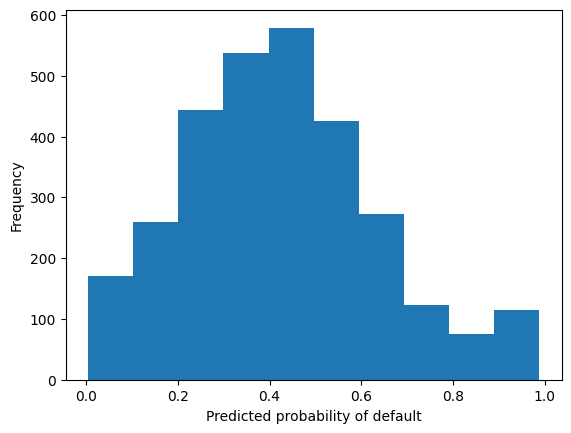

In [377]:
# plot the predicted probabilities
import matplotlib.pyplot as plt
plt.hist(y_pred_prob_b)
plt.xlabel('Predicted probability of default')
plt.ylabel('Frequency')

In [380]:
# BUILT OFF OF - https://www.kaggle.com/joparga3/in-depth-skewed-data-classif-93-recall-acc-now

import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [381]:
logreg2 = LogisticRegression(C= 0.01, penalty='l1')
logreg2.fit(X_res, y_res)
y_pred_proba2 = logreg2.predict_proba(X_test)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

plt.figure(figsize=(10,10))

j = 1

for i in thresholds:
    y_test_predictions_high_recall = y_pred_proba2[:, 1] > i

    plt.subplot(3, 3, j)
    j += 1

    # Compute confusion matrix
    cnf_matrix = metrics.confusion_matrix(y_test, y_test_predictions_high_recall)
    np.set_printoptions(precision=2)

    print("Recall metric in the testing dataset: ", float(cnf_matrix[1,1]) / float((cnf_matrix[1,0] + cnf_matrix[1,1])))

    # Plot non-normalized confusion matrix
    class_names = [0, 1]
    plot_confusion_matrix(cnf_matrix, classes=class_names, title='Threshold >= %s'%i)

ValueError: Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.

Let's focus now on decison tree and random forrest for the whole dataset (more features, still not all but most of them).


### **Decision Tree**

We already established the best dataset

----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1744
           1       0.26      0.30      0.28       256

    accuracy                           0.80      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.81      0.80      0.81      2000

[[1526  218]
 [ 178   78]]
Accuracy: 
0.802
Precision: 
0.2635135135135135
Recall: 
0.3046875
F1: 
0.2826086956521739
ROC AUC: 
0.58984375


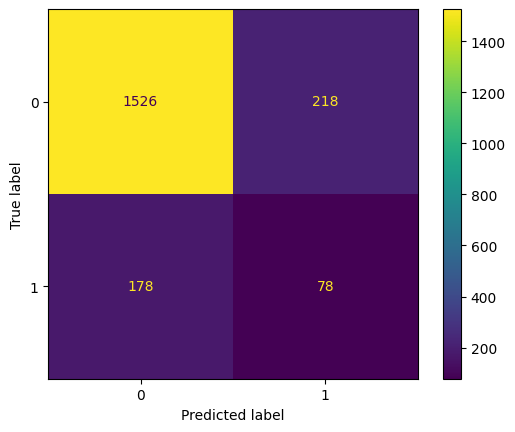

In [352]:

dec_tree_model = run_model(X_scaled, y_scaled, 0.2, DecisionTreeClassifier(),1,1)

In [353]:
clf = dec_tree_model[0]              # the fitted DecisionTreeClassifier
print(clf.get_params())              # hyperparameters (what you set or defaults)
print("Depth:", clf.get_depth())     # learned
print("Leaves:", clf.get_n_leaves()) # learned

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Depth: 35
Leaves: 1124


We can see that our tree has 1124 leaves and it's depth is 35.

In [ ]:
# unpack the list
clf, acc, prec, rec, f1, auc = dec_tree_model

# hyperparameters (knobs you set / defaults)
print(clf.get_params())

# learned attributes (after fit)
print("Depth:", clf.get_depth())
print("Leaves:", clf.get_n_leaves())
print("Importances:", clf.feature_importances_)


----------------------------------------------------------------------
DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      1741
           1       0.25      0.28      0.27       259

    accuracy                           0.80      2000
   macro avg       0.57      0.58      0.57      2000
weighted avg       0.81      0.80      0.80      2000

[[1529  212]
 [ 187   72]]
Accuracy: 0.8005
Precision: 0.2535211267605634
Recall: 0.277992277992278
F1: 0.26519337016574585
ROC AUC: 0.5781115898864319


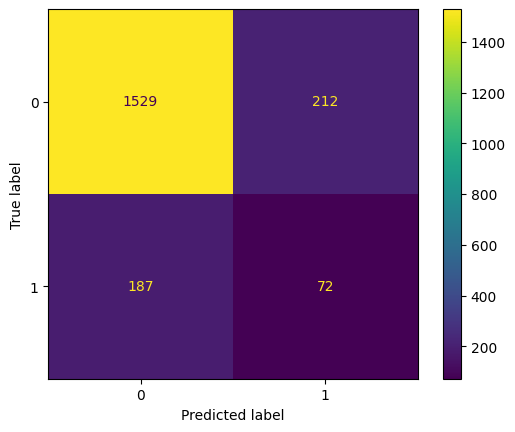

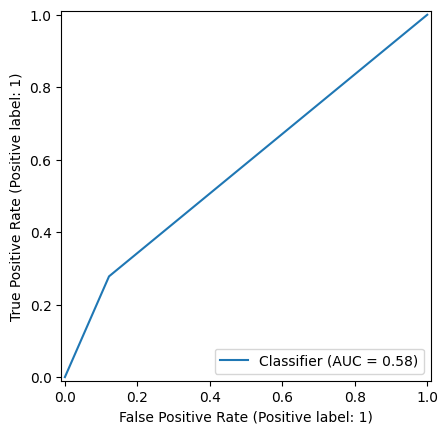

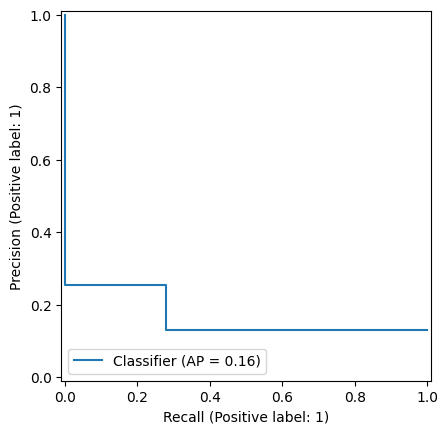

Predicted,0,1,All
True,,,
0,1529,212,1741
1,187,72,259
All,1716,284,2000


In [354]:
dec_tree_model_2 = run_model_2(X_scaled, y_scaled, 0.2, DecisionTreeClassifier(),1,1)

In [ ]:
dec_tree_model_2

In [ ]:
# Get params (hyperparameters)
print(dec_tree_model["model"].get_params())

# Learned attributes
print("Depth:", dec_tree_model["model"].get_depth())
print("Leaves:", dec_tree_model["model"].get_n_leaves())
print("Feature importances:", dec_tree_model["model"].feature_importances_)

# Metrics
print("Confusion matrix:\n", dec_tree_model["confusion_matrix"])
print("Precision/Recall/F1/AUC:",
      dec_tree_model["precision"], dec_tree_model["recall"], dec_tree_model["f1"], dec_tree_model["roc_auc"])

In [ ]:
from sklearn.tree import export_text
print(export_text(clf, feature_names=getattr(X_scaled, "columns", None)))

In [ ]:
dec_tree_model_3 = run_model_3(X_scaled, y_scaled, 0.2, DecisionTreeClassifier(),1,1)

----------------------------------------------------------------------
LogisticRegression(C=1000000000.0)
(threshold = 0.6; scores from predict_proba)
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1741
           1       0.81      0.11      0.20       259

    accuracy                           0.88      2000
   macro avg       0.84      0.55      0.57      2000
weighted avg       0.87      0.88      0.84      2000

[[1734    7]
 [ 230   29]]
Accuracy: 0.8815
Precision: 0.8055555555555556
Recall: 0.11196911196911197
F1: 0.19661016949152543
ROC AUC: 0.6653789261485988

--- Model hyperparameters ---
{'C': 1000000000.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

(no feature_importances_ on this model)


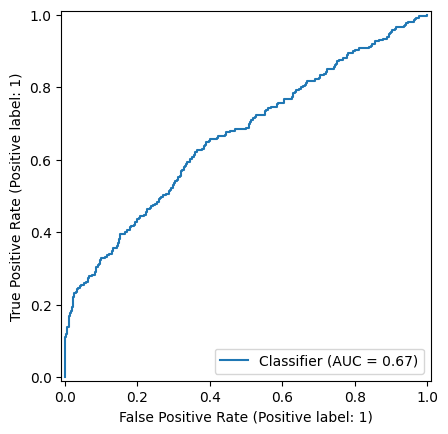

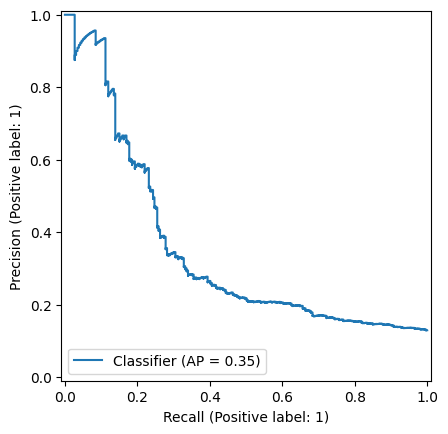

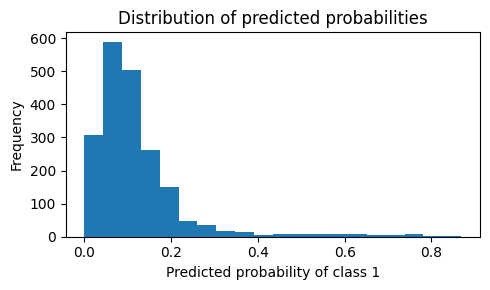

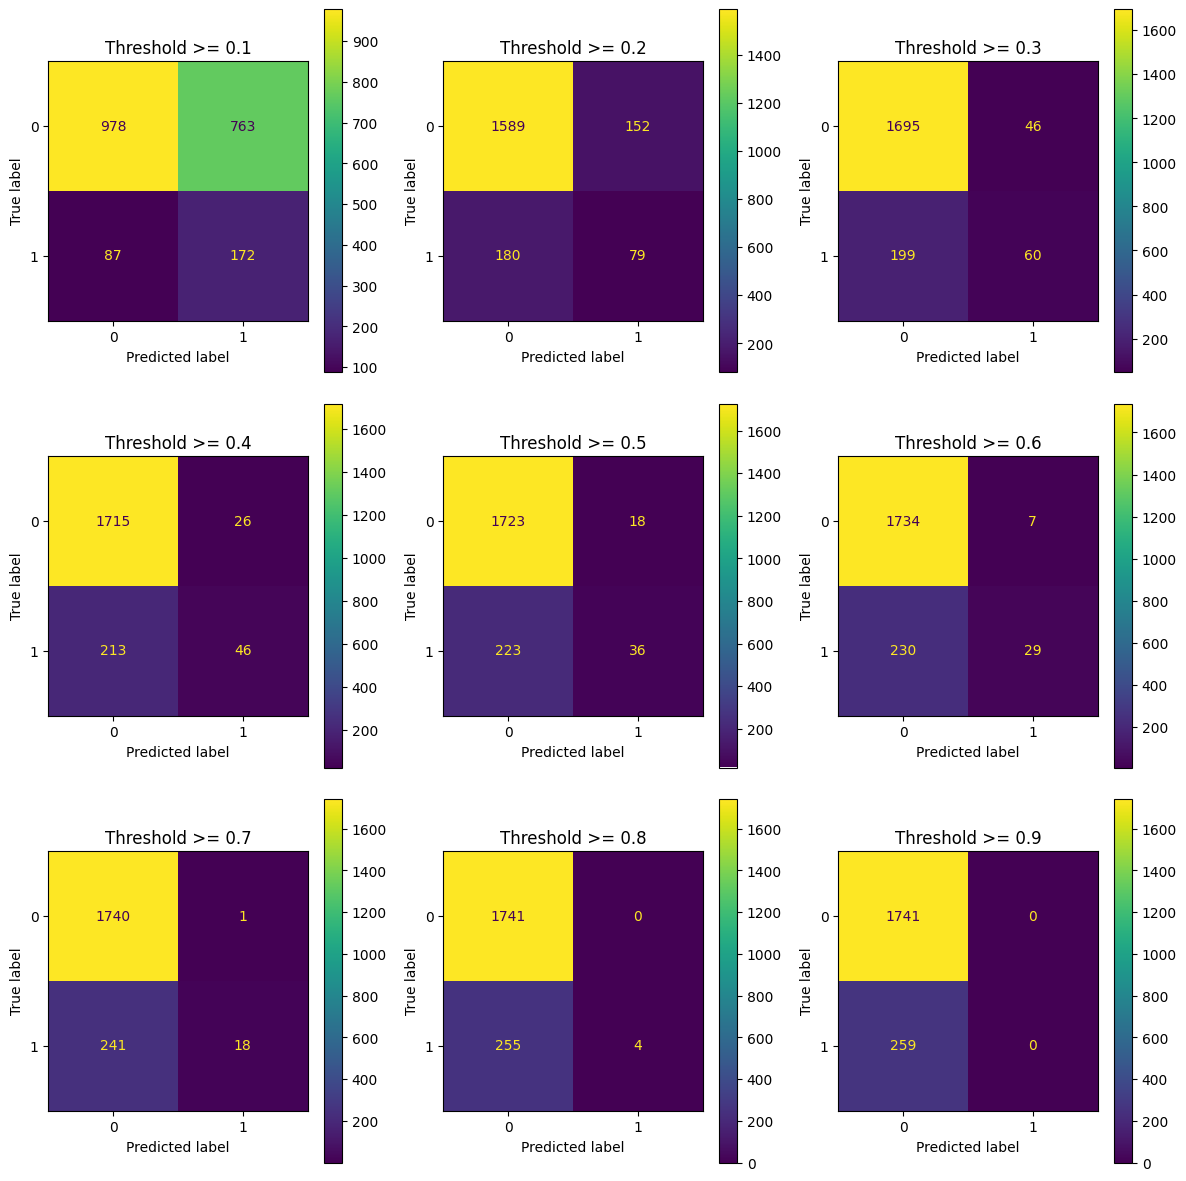

In [383]:
# train/evaluate with a custom hard-label threshold, show ROC/PR,
# plot a prob histogram, and produce a 3x3 confusion-matrix grid
model, acc, prec, rec, f1, auc = run_model_4(
    X_scaled, y_scaled, test_size_p=0.2, model_p=logreg,
    balancing=0, conf_m=5,
    threshold=0.6,
    cm_thresholds=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    plot_prob_hist=True
)

# get the probabilities directly (no need to recompute)
y_prob = model._y_prob.values
y_true = model._y_test.values

----------------------------------------------------------------------
RandomForestClassifier()
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1741
           1       0.77      0.17      0.28       259

    accuracy                           0.89      2000
   macro avg       0.83      0.58      0.61      2000
weighted avg       0.87      0.89      0.85      2000

[[1728   13]
 [ 215   44]]
Accuracy: 0.886
Precision: 0.7719298245614035
Recall: 0.16988416988416988
F1: 0.27848101265822783
ROC AUC: 0.6735899352211816

--- Model hyperparameters ---
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0

,0
small_business,0.078359
inq_last_6mths_imp,0.062536
zip3_OTHER,0.054316
verification_status_ind,0.046436
purpose_debt_consolidation,0.042102
annual_inc,0.040220
revol_util_frac,0.039964
revol_util_imp,0.039403
total_acc_imp,0.036602
credit_age_years,0.035690


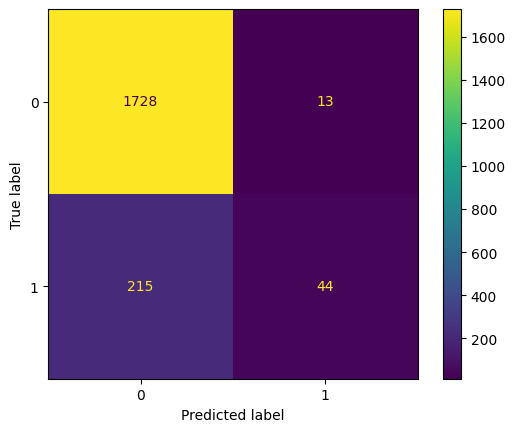

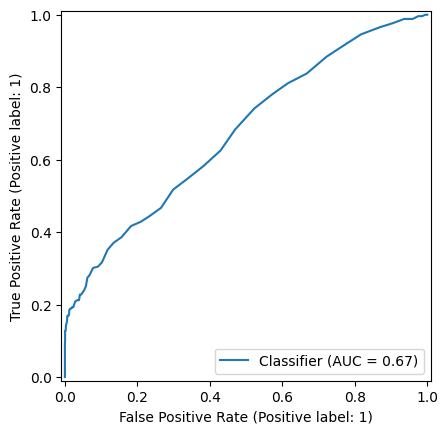

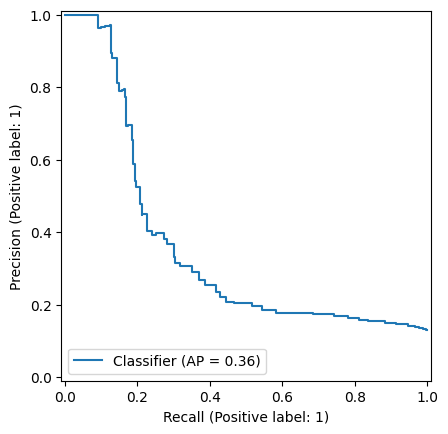

Predicted,0,1,All
True,,,
0,1728,13,1741
1,215,44,259
All,1943,57,2000


In [390]:
random_forest_model_3 = run_model_3(X_scaled, y_scaled, 0.2, RandomForestClassifier(),1,1)

----------------------------------------------------------------------
RandomForestClassifier()
(threshold = 0.6; scores from predict_proba)
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1741
           1       0.97      0.12      0.21       259

    accuracy                           0.89      2000
   macro avg       0.93      0.56      0.57      2000
weighted avg       0.89      0.89      0.84      2000

[[1740    1]
 [ 229   30]]
Accuracy: 0.885
Precision: 0.967741935483871
Recall: 0.11583011583011583
F1: 0.20689655172413793
ROC AUC: 0.6816013519057746

--- Model hyperparameters ---
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score

,0
small_business,0.073852
inq_last_6mths_imp,0.060909
zip3_OTHER,0.055485
verification_status_ind,0.047254
revol_util_frac,0.040428
revol_util_imp,0.039600
annual_inc,0.039309
emp_length_num,0.037163
purpose_debt_consolidation,0.036654
total_acc_imp,0.036354


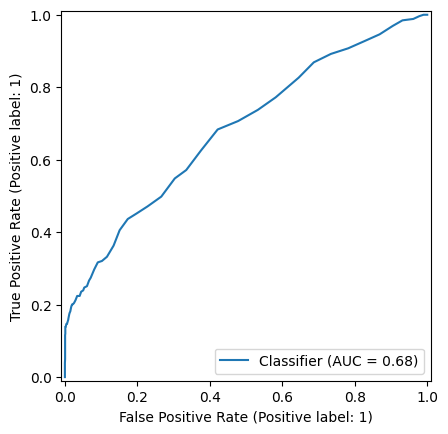

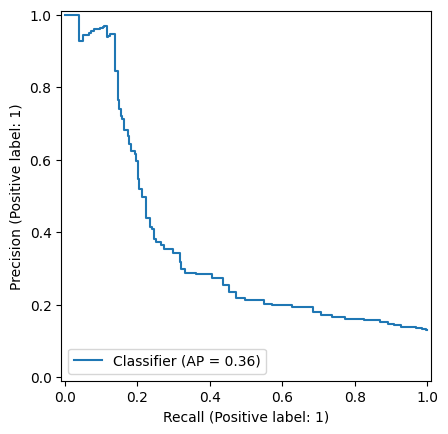

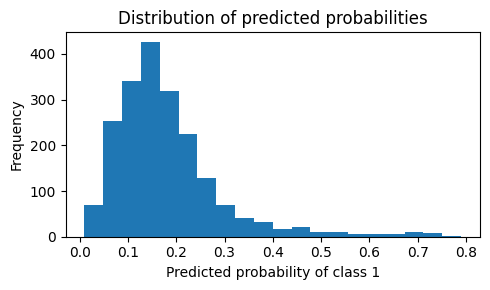

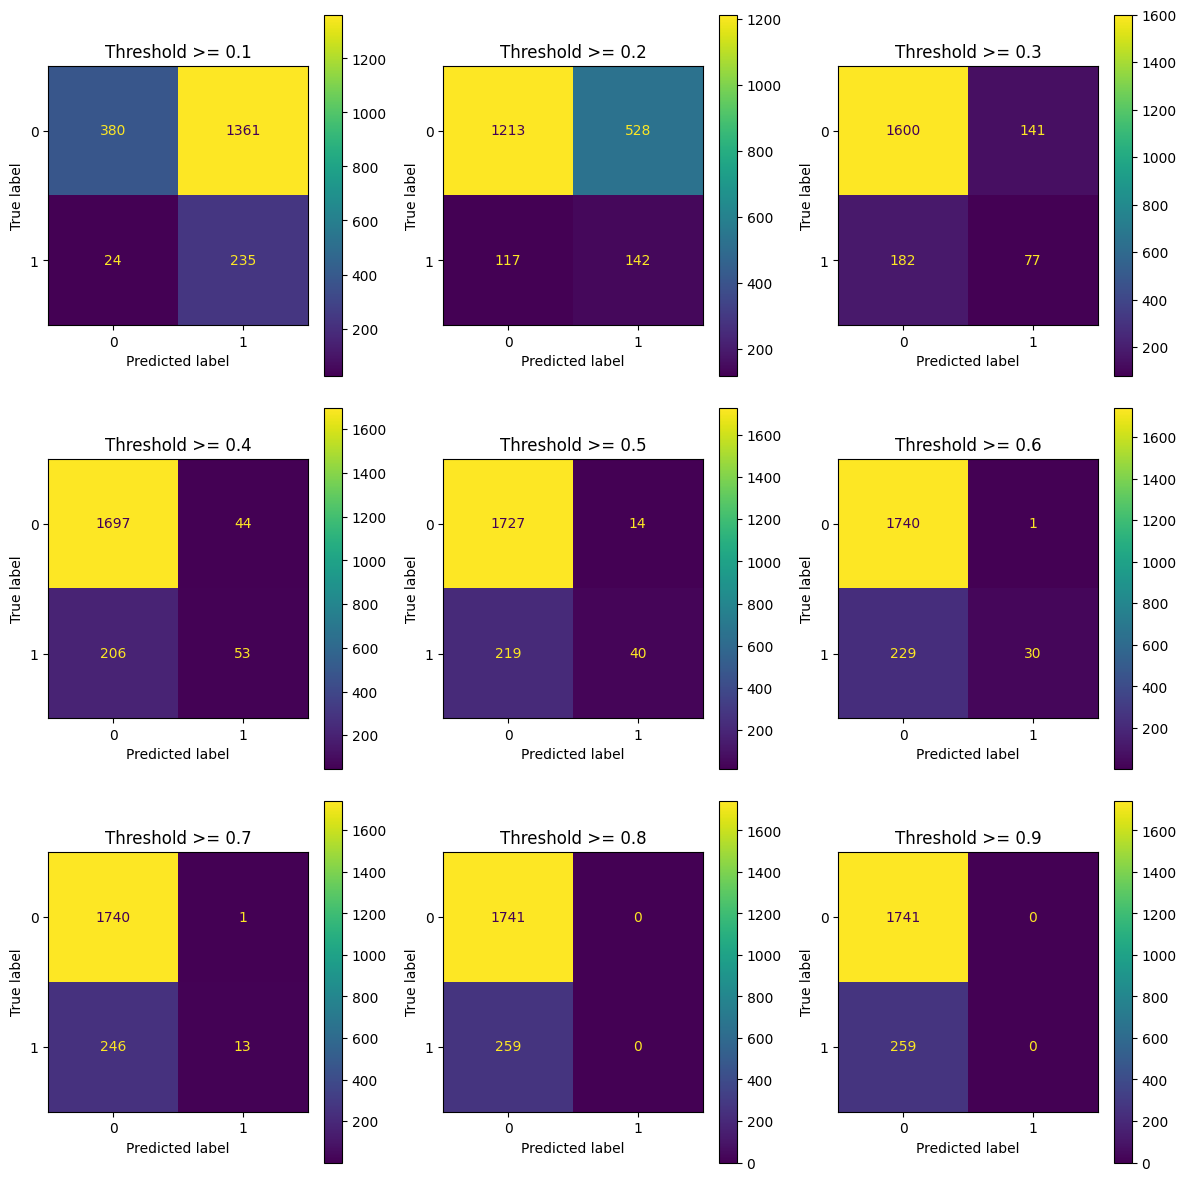

In [391]:
# train/evaluate with a custom hard-label threshold, show ROC/PR,
# plot a prob histogram, and produce a 3x3 confusion-matrix grid
model, acc, prec, rec, f1, auc = run_model_4(
    X_scaled, y_scaled, test_size_p=0.2, model_p=RandomForestClassifier(),
    balancing=1, conf_m=5,
    threshold=0.6,
    cm_thresholds=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    plot_prob_hist=True
)

# get the probabilities directly (no need to recompute)
y_prob = model._y_prob.values
y_true = model._y_test.values

In [ ]:
X_scaled, y_scaled

----------------------------------------------------------------------
DecisionTreeClassifier()
(threshold = 0.6; scores from predict_proba)
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1741
           1       0.26      0.30      0.28       259

    accuracy                           0.80      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.81      0.80      0.81      2000

[[1523  218]
 [ 182   77]]
Accuracy: 0.8
Precision: 0.26101694915254237
Recall: 0.2972972972972973
F1: 0.2779783393501805
ROC AUC: 0.5860409519226292

--- Model hyperparameters ---
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Depth: 43
Leaves: 1133

Top features (Gini import

,0
purpose_debt_consolidation,0.144612
small_business,0.135157
zip3_OTHER,0.082796
inq_last_6mths_imp,0.080851
verification_status_ind,0.070296
annual_inc,0.033486
credit_age_years,0.031435
policy_PC5,0.030571
revol_bal,0.030495
debt_to_income,0.030156


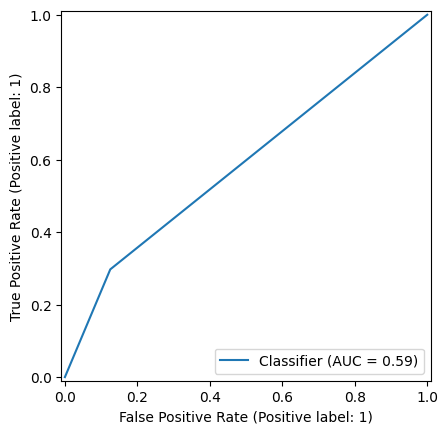

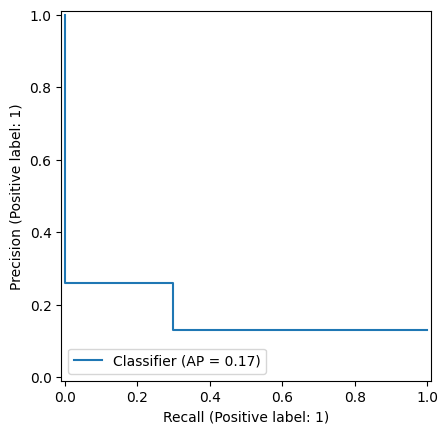

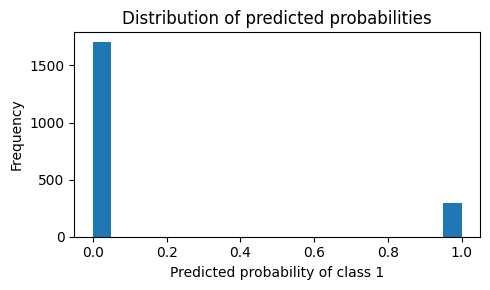

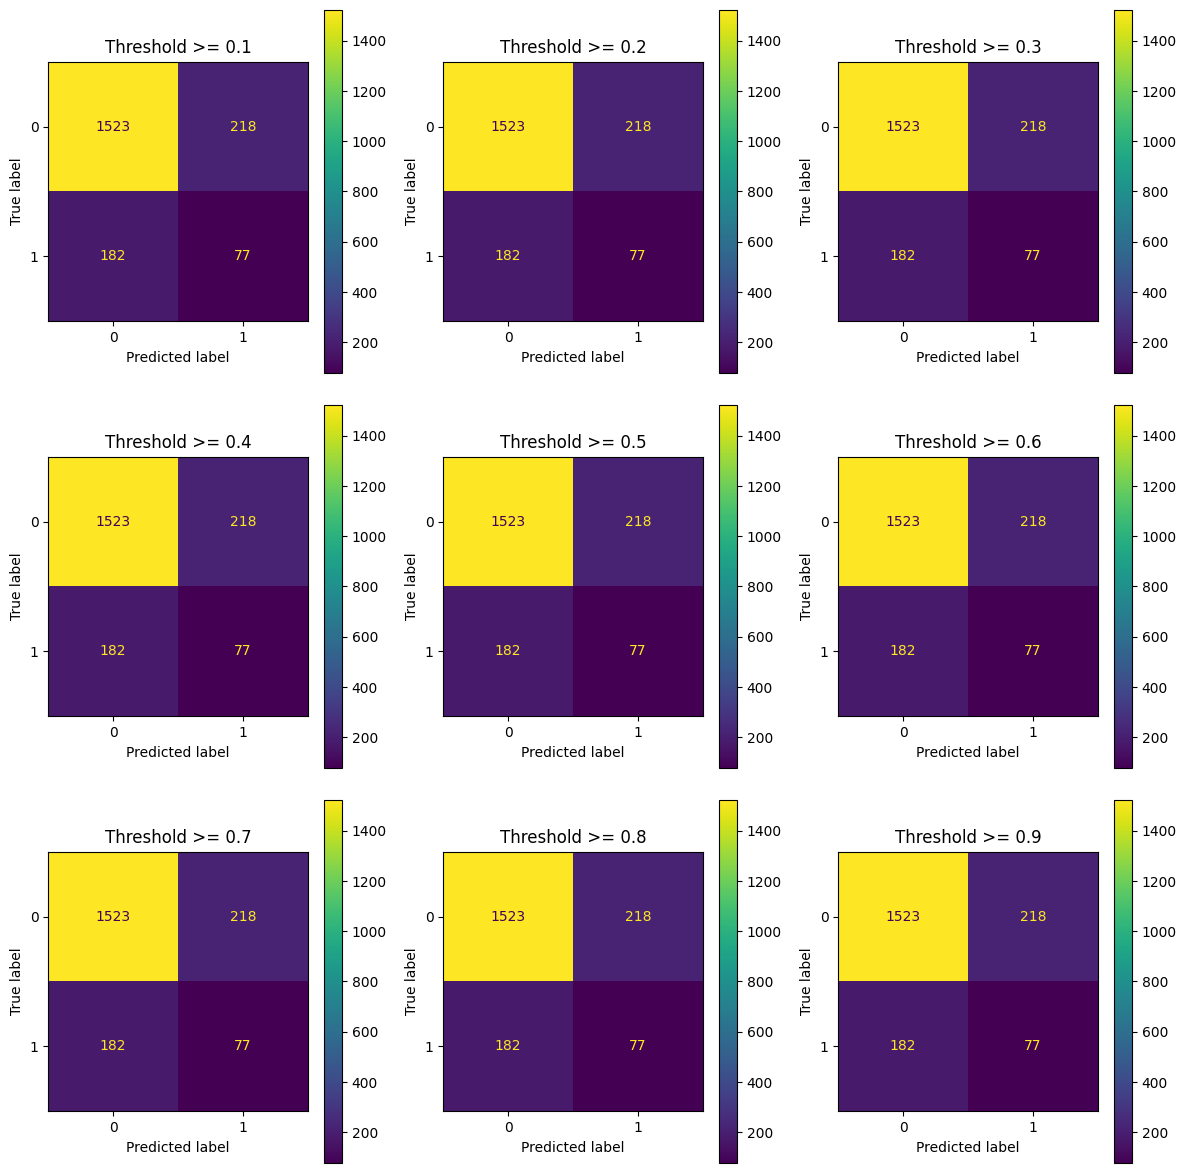

In [384]:
# train/evaluate with a custom hard-label threshold, show ROC/PR,
# plot a prob histogram, and produce a 3x3 confusion-matrix grid
model, acc, prec, rec, f1, auc = run_model_4(
    X_scaled, y_scaled, test_size_p=0.2, model_p=DecisionTreeClassifier(),
    balancing=1, conf_m=5,
    threshold=0.6,
    cm_thresholds=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    plot_prob_hist=True
)

# get the probabilities directly (no need to recompute)
y_prob = model._y_prob.values
y_true = model._y_test.values


----------------------------------------------------------------------
DecisionTreeClassifier()
(threshold = 0.6; scores from predict_proba)
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1741
           1       0.27      0.30      0.28       259

    accuracy                           0.80      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.81      0.80      0.81      2000

[[1532  209]
 [ 182   77]]
Accuracy: 0.8045
Precision: 0.2692307692307692
Recall: 0.2972972972972973
F1: 0.28256880733944956
ROC AUC: 0.5886256733470978

--- Model hyperparameters ---
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Depth: 45
Leaves: 985

Top features (Gini impo

,0
credit_age_years,0.078220
debt_to_income,0.077331
annual_inc,0.077128
small_business,0.066933
total_acc_imp,0.062499
revol_bal,0.059705
purpose_other,0.054782
open_acc_imp,0.053967
revol_util_imp,0.041429
revol_util_frac,0.039580


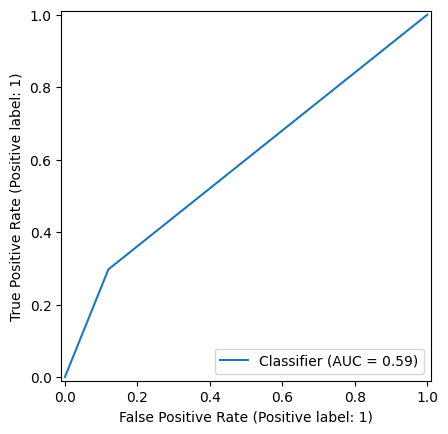

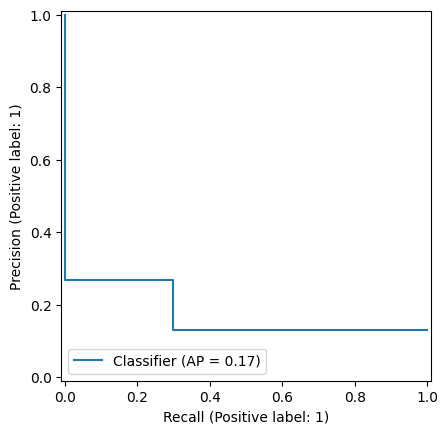

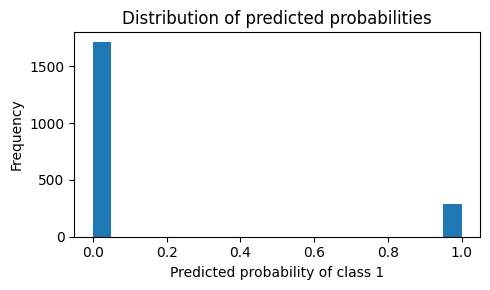

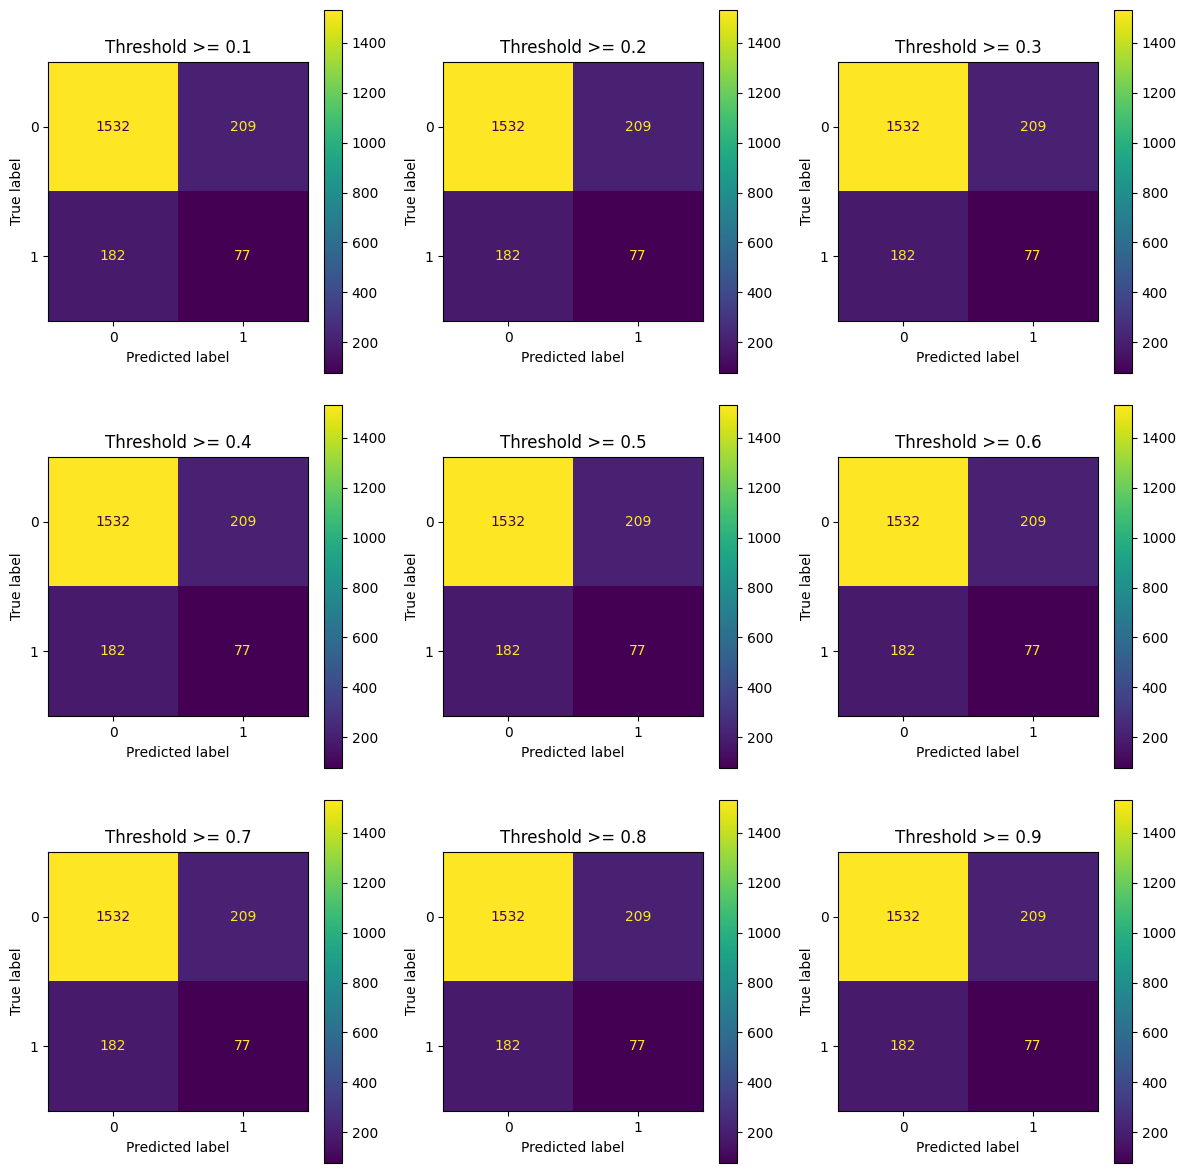

In [385]:
# train/evaluate with a custom hard-label threshold, show ROC/PR,
# plot a prob histogram, and produce a 3x3 confusion-matrix grid
model, acc, prec, rec, f1, auc = run_model_4(
    X_scaled, y_scaled, test_size_p=0.2, model_p=DecisionTreeClassifier(),
    balancing=0, conf_m=5,
    threshold=0.6,
    cm_thresholds=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    plot_prob_hist=True
)

# get the probabilities directly (no need to recompute)
y_prob = model._y_prob.values
y_true = model._y_test.values

In [387]:
_ = run_model_5(
    X, y, 0.2, model_p=DecisionTreeClassifier(),
    balancing=1,
    threshold=0.5,
    conf_m=0,           # any value is fine; pretty_cm runs separately
    pretty_cm=True,     # show pretty counts table like your screenshot
    pretty_cm_pct=True  # optional: also show row-normalized percentages
)


----------------------------------------------------------------------
DecisionTreeClassifier()
(threshold = 0.5; scores from predict_proba)
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1741
           1       0.27      0.26      0.27       259

    accuracy                           0.81      2000
   macro avg       0.58      0.58      0.58      2000
weighted avg       0.81      0.81      0.81      2000

[[1559  182]
 [ 191   68]]
Accuracy: 0.8135
Precision: 0.272
Recall: 0.2625482625482625
F1: 0.26719056974459726
ROC AUC: 0.5790053202459865

--- Model hyperparameters ---
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Depth: 39
Leaves: 1083

Top features (Gini importance):


,0
inq_last_6mths_imp,0.278108
small_business,0.182385
purpose_debt_consolidation,0.082257
verification_status_ind,0.050056
purpose_other,0.032926
home_ownership_MORTGAGE,0.031273
debt_to_income,0.027503
annual_inc,0.027459
credit_age_years,0.023866
total_acc_imp,0.021475


Predicted,0,1,All
True,,,
0,"1,559",182,"1,741"
1,191,68,259
All,"1,750",250,"2,000"


Predicted,0,1
True,,
0,89.5%,10.5%
1,73.7%,26.3%
All,87.5%,12.5%


In [356]:
# Keep feature names BEFORE converting to NumPy
feature_names = X_scaled.columns.to_list()

# Convert to NumPy
X_scaled_np = X_scaled.to_numpy(dtype=np.float64)

# Make sure y is 1-D ints (and NOT scaled; should be original 0/1 labels)
y_np = np.asarray(y_scaled).astype(int).ravel()

# Train/test split (note: you used X_encoded_np by mistake; use X_scaled_np)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_np, y_np, test_size=0.3, stratify=y_np, random_state=42
)

# SMOTE ONLY on the training set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# (Optional) sanity checks
print("Train shape after SMOTE:", X_res.shape, np.bincount(y_res))
print("Test shape:", X_test.shape, np.bincount(y_test))

Train shape after SMOTE: (12186, 151) [6093 6093]
Test shape: (3000, 151) [2611  389]


Decision Tree (depth ≤ 3)
- Test size: 3000 | Base bad rate: 13.0%
- AUROC: 0.627 | AUPRC: 0.285
- @0.5 → Acc=0.865, Prec=0.457, Rec=0.231
- Confusion (TP/FP/FN/TN): 90/107/299/2504

Readable tree rules:

|--- small_business <= 0.00
|   |--- inq_last_6mths_imp <= -0.72
|   |   |--- annual_inc <= -0.17
|   |   |   |--- class: 0
|   |   |--- annual_inc >  -0.17
|   |   |   |--- class: 0
|   |--- inq_last_6mths_imp >  -0.72
|   |   |--- inq_last_6mths_imp <= -0.05
|   |   |   |--- class: 1
|   |   |--- inq_last_6mths_imp >  -0.05
|   |   |   |--- class: 0
|--- small_business >  0.00
|   |--- purpose_other <= 1.00
|   |   |--- class: 1
|   |--- purpose_other >  1.00
|   |   |--- small_business <= 1.00
|   |   |   |--- class: 1
|   |   |--- small_business >  1.00
|   |   |   |--- class: 1


Top features (Gini importance):
small_business                           0.4823
inq_last_6mths_imp                       0.4401
purpose_other                            0.0538
annual_inc                 

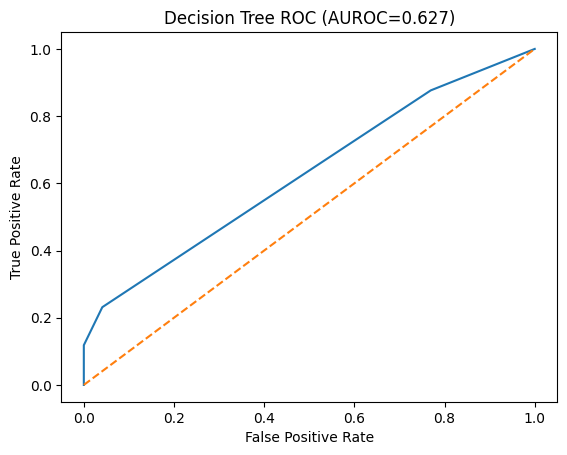

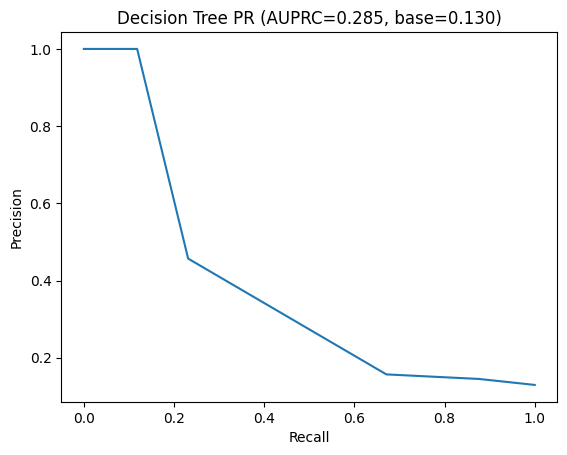

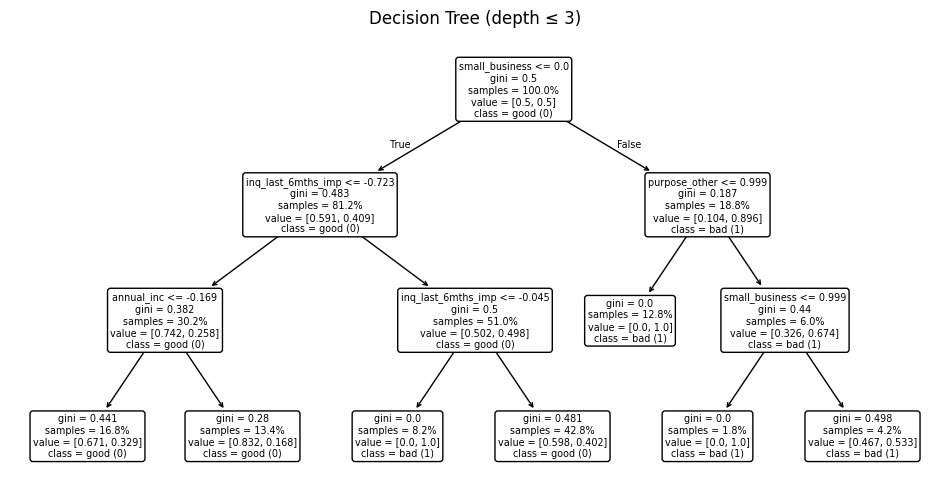

In [357]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

# Interpretable settings
tree = DecisionTreeClassifier(
    max_depth=3,          # shallow for storytelling
    min_samples_leaf=50,  # smoother leaves
    random_state=42
    # class_weight=None because you've already balanced with SMOTE
)
tree.fit(X_res, y_res)

# Evaluate on ORIGINAL (imbalanced) test set
proba_test = tree.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
auroc = roc_auc_score(y_test, proba_test)
auprc = average_precision_score(y_test, proba_test)
base  = y_test.mean()

print(
    "Decision Tree (depth ≤ 3)\n"
    f"- Test size: {len(y_test)} | Base bad rate: {base:.1%}\n"
    f"- AUROC: {auroc:.3f} | AUPRC: {auprc:.3f}\n"
    f"- @0.5 → Acc={(tp+tn)/len(y_test):.3f}, "
    f"Prec={tp/(tp+fp) if (tp+fp)>0 else float('nan'):.3f}, "
    f"Rec={tp/(tp+fn) if (tp+fn)>0 else float('nan'):.3f}\n"
    f"- Confusion (TP/FP/FN/TN): {tp}/{fp}/{fn}/{tn}"
)

# Human-readable rules (uses your original column names)
rules_text = export_text(tree, feature_names=feature_names)
print("\nReadable tree rules:\n")
print(rules_text)

# Feature importances (Gini) — deck-friendly “top drivers”
importances = (
    np.array(feature_names),
    tree.feature_importances_
)
# Make a small table
top_idx = np.argsort(tree.feature_importances_)[::-1][:12]
print("\nTop features (Gini importance):")
for i in top_idx:
    print(f"{feature_names[i]:40s} {tree.feature_importances_[i]:.4f}")

# === Plots (matplotlib only, each on its own figure) ===
# ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"Decision Tree ROC (AUROC={auroc:.3f})")
plt.show()

# Precision–Recall
prec, rec, _ = precision_recall_curve(y_test, proba_test)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Decision Tree PR (AUPRC={auprc:.3f}, base={base:.3f})")
plt.show()

# Tree diagram (readable)
plt.figure(figsize=(12,6))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["good (0)", "bad (1)"],
    filled=False, rounded=True, proportion=True
)
plt.title("Decision Tree (depth ≤ 3)")
plt.show()

Decision Tree (depth ≤ 3)
- Test size: 3000 | Base bad rate: 13.0%
- AUROC: 0.627 | AUPRC: 0.285
- @0.5 → Acc=0.865, Prec=0.457, Rec=0.231
- Confusion (TP/FP/FN/TN): 90/107/299/2504

Readable tree rules:

|--- small_business <= 0.00
|   |--- inq_last_6mths_imp <= -0.72
|   |   |--- annual_inc <= -0.17
|   |   |   |--- class: 0
|   |   |--- annual_inc >  -0.17
|   |   |   |--- class: 0
|   |--- inq_last_6mths_imp >  -0.72
|   |   |--- inq_last_6mths_imp <= -0.05
|   |   |   |--- class: 1
|   |   |--- inq_last_6mths_imp >  -0.05
|   |   |   |--- class: 0
|--- small_business >  0.00
|   |--- purpose_other <= 1.00
|   |   |--- class: 1
|   |--- purpose_other >  1.00
|   |   |--- small_business <= 1.00
|   |   |   |--- class: 1
|   |   |--- small_business >  1.00
|   |   |   |--- class: 1


Top features (Gini importance):
small_business                           0.4823
inq_last_6mths_imp                       0.4401
purpose_other                            0.0538
annual_inc                 

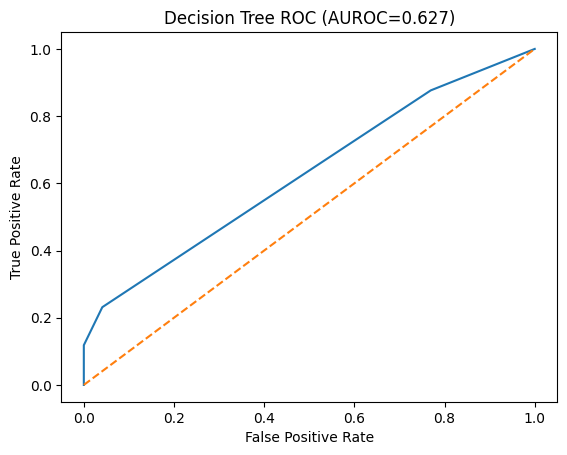

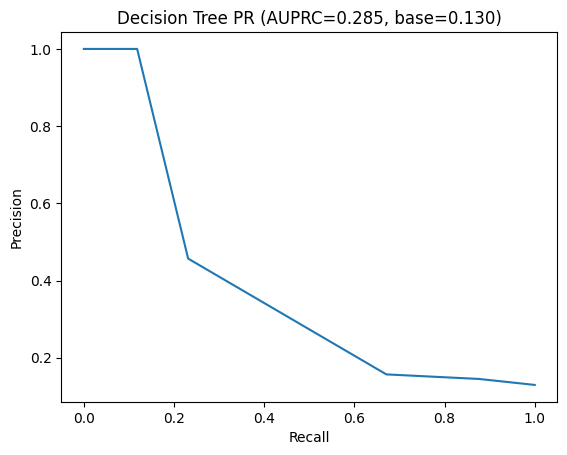

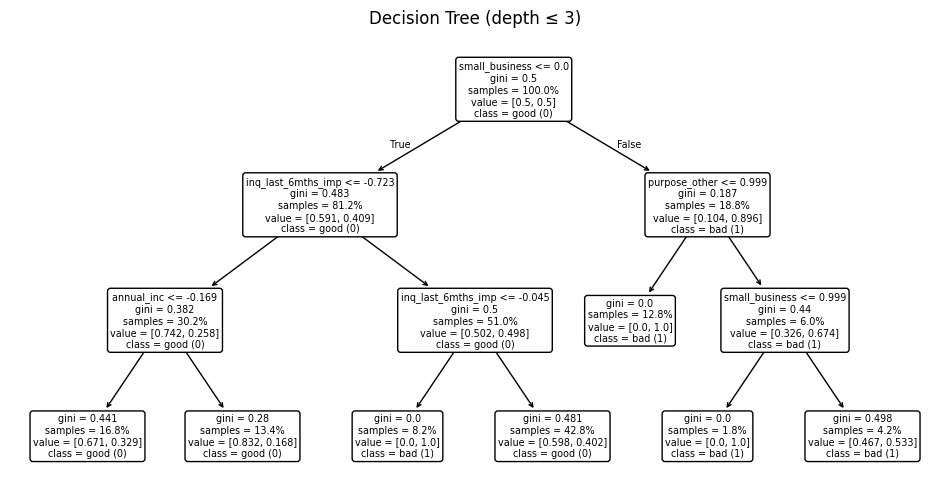

In [358]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

# Interpretable settings
tree = DecisionTreeClassifier(
    max_depth=3,          # shallow for storytelling
    min_samples_leaf=50,  # smoother leaves
    random_state=42
    # class_weight=None because you've already balanced with SMOTE
)
tree.fit(X_res, y_res)

# Evaluate on ORIGINAL (imbalanced) test set
proba_test = tree.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
auroc = roc_auc_score(y_test, proba_test)
auprc = average_precision_score(y_test, proba_test)
base  = y_test.mean()

print(
    "Decision Tree (depth ≤ 3)\n"
    f"- Test size: {len(y_test)} | Base bad rate: {base:.1%}\n"
    f"- AUROC: {auroc:.3f} | AUPRC: {auprc:.3f}\n"
    f"- @0.5 → Acc={(tp+tn)/len(y_test):.3f}, "
    f"Prec={tp/(tp+fp) if (tp+fp)>0 else float('nan'):.3f}, "
    f"Rec={tp/(tp+fn) if (tp+fn)>0 else float('nan'):.3f}\n"
    f"- Confusion (TP/FP/FN/TN): {tp}/{fp}/{fn}/{tn}"
)

# Human-readable rules (uses your original column names)
rules_text = export_text(tree, feature_names=feature_names)
print("\nReadable tree rules:\n")
print(rules_text)

# Feature importances (Gini) — deck-friendly “top drivers”
importances = (
    np.array(feature_names),
    tree.feature_importances_
)
# Make a small table
top_idx = np.argsort(tree.feature_importances_)[::-1][:12]
print("\nTop features (Gini importance):")
for i in top_idx:
    print(f"{feature_names[i]:40s} {tree.feature_importances_[i]:.4f}")

# === Plots (matplotlib only, each on its own figure) ===
# ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"Decision Tree ROC (AUROC={auroc:.3f})")
plt.show()

# Precision–Recall
prec, rec, _ = precision_recall_curve(y_test, proba_test)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Decision Tree PR (AUPRC={auprc:.3f}, base={base:.3f})")
plt.show()

# Tree diagram (readable)
plt.figure(figsize=(12,6))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["good (0)", "bad (1)"],
    filled=False, rounded=True, proportion=True
)
plt.title("Decision Tree (depth ≤ 3)")
plt.show()